# COMP4124 Group Project — Techniques for Class Imbalance in Big Data
**Dataset:** Credit Card Fraud Detection (Kaggle)

**Source:** https://www.kaggle.com/datasets/mlgulb/creditcardfraud

---
## Notebook Structure
1. Imports
2. Data Loading & Preprocessing *(run once — output saved to Parquet)*
3. Variant 1 — Local SMOTE Bagging
4. Variant 2A — Stratified Repartition via `sortBy` + Local SMOTEBagging
5. Variant 2B — Stratified Repartition via `mapPartitions` + Local SMOTEBagging 
6. Variant 3 — Global Minority Broadcast SMOTEBagging 
7. Scalability Experiments 
8. Cross-Variant Results Summary



## Section 1 — Imports



In [0]:
# Shared imports for all variants
from pyspark.sql.functions import col, rand, ntile, spark_partition_id, sum as spark_sum
from pyspark.sql.functions import monotonically_increasing_id
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, precision_score, recall_score
)



## Section 2 — Data Loading & Preprocessing
Preprocessed data is saved to Parquet so each variant can load a clean copy without re-running this section.

> This avoids partition state bleeding between variants.


### 2.1 Load Raw Data


In [0]:
# Load Data
df = spark.read.csv("/mnt/2026-group7/creditcard.csv", header = True, inferSchema = True)
df.display()

Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0.0,-1.3598071336738,-0.0727811733098497,2.53634673796914,1.37815522427443,-0.338320769942518,0.462387777762292,0.239598554061257,0.0986979012610507,0.363786969611213,0.0907941719789316,-0.551599533260813,-0.617800855762348,-0.991389847235408,-0.311169353699879,1.46817697209427,-0.470400525259478,0.207971241929242,0.0257905801985591,0.403992960255733,0.251412098239705,-0.018306777944153,0.277837575558899,-0.110473910188767,0.0669280749146731,0.128539358273528,-0.189114843888824,0.133558376740387,-0.0210530534538215,149.62,0
0.0,1.19185711131486,0.26615071205963,0.16648011335321,0.448154078460911,0.0600176492822243,-0.0823608088155687,-0.0788029833323113,0.0851016549148104,-0.255425128109186,-0.166974414004614,1.61272666105479,1.06523531137287,0.48909501589608,-0.143772296441519,0.635558093258208,0.463917041022171,-0.114804663102346,-0.183361270123994,-0.145783041325259,-0.0690831352230203,-0.225775248033138,-0.638671952771851,0.101288021253234,-0.339846475529127,0.167170404418143,0.125894532368176,-0.00898309914322813,0.0147241691924927,2.69,0
1.0,-1.35835406159823,-1.34016307473609,1.77320934263119,0.379779593034328,-0.503198133318193,1.80049938079263,0.791460956450422,0.247675786588991,-1.51465432260583,0.207642865216696,0.624501459424895,0.066083685268831,0.717292731410831,-0.165945922763554,2.34586494901581,-2.89008319444231,1.10996937869599,-0.121359313195888,-2.26185709530414,0.524979725224404,0.247998153469754,0.771679401917229,0.909412262347719,-0.689280956490685,-0.327641833735251,-0.139096571514147,-0.0553527940384261,-0.0597518405929204,378.66,0
1.0,-0.966271711572087,-0.185226008082898,1.79299333957872,-0.863291275036453,-0.0103088796030823,1.24720316752486,0.23760893977178,0.377435874652262,-1.38702406270197,-0.0549519224713749,-0.226487263835401,0.178228225877303,0.507756869957169,-0.28792374549456,-0.631418117709045,-1.0596472454325,-0.684092786345479,1.96577500349538,-1.2326219700892,-0.208037781160366,-0.108300452035545,0.00527359678253453,-0.190320518742841,-1.17557533186321,0.647376034602038,-0.221928844458407,0.0627228487293033,0.0614576285006353,123.5,0
2.0,-1.15823309349523,0.877736754848451,1.548717846511,0.403033933955121,-0.407193377311653,0.0959214624684256,0.592940745385545,-0.270532677192282,0.817739308235294,0.753074431976354,-0.822842877946363,0.53819555014995,1.3458515932154,-1.11966983471731,0.175121130008994,-0.451449182813529,-0.237033239362776,-0.0381947870352842,0.803486924960175,0.408542360392758,-0.00943069713232919,0.79827849458971,-0.137458079619063,0.141266983824769,-0.206009587619756,0.502292224181569,0.219422229513348,0.215153147499206,69.99,0
2.0,-0.425965884412454,0.960523044882985,1.14110934232219,-0.168252079760302,0.42098688077219,-0.0297275516639742,0.476200948720027,0.260314333074874,-0.56867137571251,-0.371407196834471,1.34126198001957,0.359893837038039,-0.358090652573631,-0.137133700217612,0.517616806555742,0.401725895589603,-0.0581328233640131,0.0686531494425432,-0.0331937877876282,0.0849676720682049,-0.208253514656728,-0.559824796253248,-0.0263976679795373,-0.371426583174346,-0.232793816737034,0.105914779097957,0.253844224739337,0.0810802569229443,3.67,0
4.0,1.22965763450793,0.141003507049326,0.0453707735899449,1.20261273673594,0.191880988597645,0.272708122899098,-0.00515900288250983,0.0812129398830894,0.464959994783886,-0.0992543211289237,-1.41690724314928,-0.153825826253651,-0.75106271556262,0.16737196252175,0.0501435942254188,-0.443586797916727,0.00282051247234708,-0.61198733994012,-0.0455750446637976,-0.21963255278686,-0.167716265815783,-0.270709726172363,-0.154103786809305,-0.780055415004671,0.75013693580659,-0.257236845917139,0.0345074297438413,0.00516776890624916,4.99,0
7.0,-0.644269442348146,1.41796354547385,1.0743803763556,-0.492199018495015,0.948934094764157,0.428118462833089,1.12063135838353,-3.80786423873589,0.615374730667027,1.24937617815176,

### 2.2 Basic Inspection


In [0]:

# Basic inspection

print(f"Total rows: {df.count()}")
print(f"Total columns: {len(df.columns)}")

# Check class distribution (important — log this for the paper)
print("\nClass distribution:")
df.groupBy("Class").count().orderBy("Class").show()

# Check for nulls
print("Null counts per column:")
df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns
]).show()

Total rows: 284807
Total columns: 31

Class distribution:
+-----+------+
|Class| count|
+-----+------+
|    0|284315|
|    1|   492|
+-----+------+

Null counts per column:
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|Time| V1| V2| V3| V4| V5| V6| V7| V8| V9|V10|V11|V12|V13|V14|V15|V16|V17|V18|V19|V20|V21|V22|V23|V24|V25|V26|V27|V28|Amount|Class|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|   0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|     0|    0|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+



In [0]:
from pyspark.sql import functions as F

total = df.count()
fraud_count = df.filter(F.col("Class") == 1).count()
legit_count = total - fraud_count

print(f"Legitimate (Class 0): {legit_count} ({legit_count/total*100:.3f}%)")
print(f"Fraud (Class 1): {fraud_count} ({fraud_count/total*100:.3f}%)")
print(f"Imbalance Ratio: 1: {legit_count // fraud_count}")

Legitimate (Class 0): 284315 (99.827%)
Fraud (Class 1): 492 (0.173%)
Imbalance Ratio: 1: 577


In [0]:
#Check for duplicate rows
total_rows = df.count()
distinct_rows = df.dropDuplicates().count()
duplicates = total_rows - distinct_rows

print(f"Total rows: {total_rows}")
print(f"Distinct rows: {distinct_rows}")
print(f"Duplicates: {duplicates}")

Total rows: 284807
Distinct rows: 283726
Duplicates: 1081


Some duplicates may exist. In credit card data, identical PCA features across different transactions can be legitimate (e.g. same merchant, same amount).

We keep them to avoid accidentally removing valid fraud cases.

### 2.3 Feature Assembly, Scaling & Train/Test Split
Train/test split is performed **before** scaling to prevent data leakage.


In [0]:
# Add stable row id
# This will be useful later when joining predictions
df = df.withColumn("row_id", F.monotonically_increasing_id())
df = df.cache()

In [0]:

# Drop Time column
df = df.drop("Time")

print(f"\nColumns after dropping Time: {df.columns}")
print(f"Remaining columns: {len(df.columns)}")
print(f"Feature columns: {len(df.columns) - 1}")  # minus Class

# Train/test split FIRST to avoid Data Leakage
# Stratified split — preserve class ratio in both splits

fraud_df    = df.filter(col("Class") == 1)
majority_df = df.filter(col("Class") == 0)

train_fraud,    test_fraud    = fraud_df.randomSplit([0.8, 0.2], seed=42)
train_majority, test_majority = majority_df.randomSplit([0.8, 0.2], seed=42)

train_raw = train_majority.unionByName(train_fraud)
test_raw  = test_majority.unionByName(test_fraud)

print(f"Train size: {train_raw.count()}")
print(f"Test size:  {test_raw.count()}")

# Scale Amount only (V1-V28 already PCA-scaled)
amount_assembler = VectorAssembler(inputCols=["Amount"], outputCol="amount_vec")

train_amt = amount_assembler.transform(train_raw)
test_amt  = amount_assembler.transform(test_raw)

# Fit scaler on TRAIN only - no leakage
amount_scaler = StandardScaler(inputCol="amount_vec", outputCol="amount_scaled", withMean=True, withStd=True)

amount_scaler_model = amount_scaler.fit(train_amt)

train_amt_scaled = amount_scaler_model.transform(train_amt)
test_amt_scaled  = amount_scaler_model.transform(test_amt)

# Assemble final feature vector
feature_cols = [f"V{i}" for i in range(1, 29)] + ["amount_scaled"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

train_final = assembler.transform(train_amt_scaled).select(
    "features", col("Class").alias("label")
)
test_final = assembler.transform(test_amt_scaled).select(
    "features", col("Class").alias("label")
)


# cache and materialise
train_final.cache()
train_final.count()
test_final.cache()
test_final.count()

print("Preprocessing complete.")
train_final.printSchema()
train_final.show(3, truncate=True)


Columns after dropping Time: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'row_id']
Remaining columns: 31
Feature columns: 30
Train size: 227848
Test size:  56959
Preprocessing complete.
root
 |-- features: vector (nullable = true)
 |-- label: integer (nullable = true)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[-27.670568881696...|    0|
|[-23.066841657925...|    0|
|[-11.704304025059...|    0|
+--------------------+-----+
only showing top 3 rows



### 2.4 Verify Class Distribution


In [0]:
print("Class distribution:")
print("Train:")
train_final.groupBy("label").count().show()
print("Test:")
test_final.groupBy("label").count().show()

print(f"Train fraud ratio: {train_fraud.count()/train_raw.count()*100:.3f}%")
print(f"Test fraud ratio: {test_fraud.count()/test_raw.count()*100:.3f}%")
print(f"Original ratio: {fraud_df.count()/df.count()*100:.3f}%")

Class distribution:
Train:
+-----+------+
|label| count|
+-----+------+
|    0|227464|
|    1|   384|
+-----+------+

Test:
+-----+-----+
|label|count|
+-----+-----+
|    0|56851|
|    1|  108|
+-----+-----+

Train fraud ratio: 0.169%
Test fraud ratio: 0.190%
Original ratio: 0.173%


### 2.5 Save Preprocessed Data to Parquet
Each variant will load from here — guaranteeing a clean, identical starting point.


In [0]:
# Save preprocessed train and test sets to Parquet
# This allows each variant to load a clean copy independently

PREPROCESSED_PATH = "/mnt/2026-group7/preprocessed/"

train_final.write.mode("overwrite").parquet(PREPROCESSED_PATH + "train")
test_final.write.mode("overwrite").parquet(PREPROCESSED_PATH + "test")

print(f"Train saved: {train_final.count()} rows")
print(f"Test saved: {test_final.count()} rows")
print(f"Path: {PREPROCESSED_PATH}")


Train saved: 227848 rows
Test saved: 56959 rows
Path: /mnt/2026-group7/preprocessed/


### 2.6 Helper - `load_preprocessed()`
Call this at the top of each variant section to get a clean, unmodified copy of the data.


In [0]:
# Helper function — call at start of each variant to get a fresh copy
def load_preprocessed():
    PREPROCESSED_PATH = "/mnt/2026-group7/preprocessed/"
    train = spark.read.parquet(PREPROCESSED_PATH + "train")
    test_final = spark.read.parquet(PREPROCESSED_PATH + "test")
    # Reset shuffle partitions to default
    spark.conf.set("spark.sql.shuffle.partitions", "8")
    print(f"Loaded train: {train.count()} rows | test: {test_final.count()} rows")
    return train, test_final



## Section 3 - Variant 1: Local SMOTE Bagging

**Approach:** Each partition independently applies SMOTE oversampling and trains a local ensemble of Decision Trees. Predictions are aggregated via majority vote. No data movement between partitions during training.

In [0]:
# Variant 1
# Load fresh preprocessed data
train_final, test_final = load_preprocessed()

Loaded train: 227848 rows | test: 56959 rows


In [0]:
# 1. check number of partition in spark
print(f"Number of partitions: {train_final.rdd.getNumPartitions()}")


Number of partitions: 20


In [0]:
# Fix shuffle partitions for rest of pipeline
train_final = train_final.repartition(8)
test_final  = test_final.repartition(8)

spark.conf.set("spark.sql.shuffle.partitions", 8)

train_final = train_final.coalesce(8)
test_final  = test_final.coalesce(8)


# Re-cache after coalesce
train_final.cache()
train_final.count()
test_final.cache()
test_final.count()

print(f"Train partitions: {train_final.rdd.getNumPartitions()}")
print(f"Test partitions: {test_final.rdd.getNumPartitions()}")

Train partitions: 8
Test partitions: 8


In [0]:
#Check Minority Distribution
current_dist = train_final.withColumn("part_id", spark_partition_id())

print("Minority rows per partition")
current_dist.filter(col("label") == 1).groupBy("part_id").count().orderBy("part_id").show()

Minority rows per partition
+-------+-----+
|part_id|count|
+-------+-----+
|      0|   48|
|      1|   48|
|      2|   48|
|      3|   47|
|      4|   46|
|      5|   48|
|      6|   50|
|      7|   49|
+-------+-----+



In [0]:
def smote_from_scratch(X_minority, k_neighbours=5, n_synthetic=None, random_state=42):
   
    rng = np.random.RandomState(random_state)
    n_samples, n_features = X_minority.shape

    if n_synthetic is None:
        n_synthetic = n_samples  # default - double the minority class

    synthetic_samples = np.empty((n_synthetic, n_features), dtype=np.float64)

    # Step 1: Precompute all pairwise Euclidean distances
    sq_norms = np.sum(X_minority ** 2, axis=1)                          # (n,)
    dot_prod = X_minority @ X_minority.T                                 # (n, n)
    dist_matrix = np.sqrt(
        np.maximum(sq_norms[:, None] + sq_norms[None, :] - 2 * dot_prod, 0.0)
    )                                                                    # (n, n)

    # Step 2: Find k nearest neighbours for every sample
    np.fill_diagonal(dist_matrix, np.inf)
    # argsort each row and take first k indices
    knn_indices = np.argsort(dist_matrix, axis=1)[:, :k_neighbours]     # (n, k)

    # Step 3: Generate synthetic samples
    for i in range(n_synthetic):
        # Pick a random minority sample as the base point
        base_idx = rng.randint(0, n_samples)
        base_sample = X_minority[base_idx]                               # (n_features,)

        # Pick one of its k neighbours at random
        neighbour_idx = knn_indices[base_idx, rng.randint(0, k_neighbours)]
        neighbour = X_minority[neighbour_idx]                            # (n_features,)

        # Interpolate: synthetic = base + gap * (neighbour - base)
        gap = rng.random()
        synthetic_samples[i] = base_sample + gap * (neighbour - base_sample)

    return synthetic_samples


def apply_local_smote_failsafe(partition_iterator):
    
    import numpy as np
    from pyspark.sql import Row
    from pyspark.ml.linalg import Vectors

    K_NEIGHBOURS  = 5      # standard SMOTE default (Chawla et al. 2002)
    RANDOM_STATE  = 42

    # Materialise partition into local worker memory
    data = list(partition_iterator)
    if not data:
        return []

    # Convert Spark Row objects to NumPy arrays
    try:
        X = np.array([row.features.toArray() for row in data], dtype='float64')
        y = np.array([row.label              for row in data], dtype='int')
    except Exception:
        return []  # Skip corrupt partitions silently

    X_majority = X[y == 0]
    X_minority = X[y == 1]
    num_majority = len(X_majority)
    num_minority = len(X_minority)

    # How many synthetic samples do we need to reach 1:1 balance?
    n_synthetic_needed = num_majority - num_minority

    # Case 1: Only one class present - return as-is
    if num_minority == 0 or num_majority == 0:
        X_res, y_res = X, y

    # Case 2: Too few minority for SMOTE (need at least k+1)
    #     Fall back to random duplication with replacement
    elif num_minority <= K_NEIGHBOURS:
        rng = np.random.RandomState(RANDOM_STATE)
        # Sample with replacement from existing minority rows
        idx = rng.choice(num_minority, size=n_synthetic_needed, replace=True)
        X_synthetic = X_minority[idx]
        X_res = np.vstack([X_majority, X_minority, X_synthetic])
        y_res = np.hstack([
            np.zeros(num_majority, dtype=int),
            np.ones(num_minority + n_synthetic_needed, dtype=int)
        ])

    # Case 3: Sufficient minority - run custom SMOTE
    else:
        X_synthetic = smote_from_scratch(
            X_minority,
            k_neighbours=K_NEIGHBOURS,
            n_synthetic=n_synthetic_needed,
            random_state=RANDOM_STATE
        )
        X_res = np.vstack([X_majority, X_minority, X_synthetic])
        y_res = np.hstack([
            np.zeros(num_majority,  dtype=int),
            np.ones(num_minority,   dtype=int),
            np.ones(len(X_synthetic), dtype=int)
        ])

    # Return balanced rows as Spark-compatible Row objects
    return [
        Row(features=Vectors.dense(X_res[i].tolist()), label=int(y_res[i]))
        for i in range(len(y_res))
    ]


# EXECUTION
# Use .rdd directly - train_final already coalesced to 8 partitions above
train_rdd = train_final.rdd

# Apply custom SMOTE independently to each partition - zero cross-partition movement
balanced_rdd = train_rdd.mapPartitions(apply_local_smote_failsafe)

# Converting back to DataFrame
from pyspark.sql.types import StructType, StructField, IntegerType
from pyspark.ml.linalg import VectorUDT

schema = StructType([
    StructField("features", VectorUDT(), True),
    StructField("label",    IntegerType(), True)
])

train_balanced_df = spark.createDataFrame(balanced_rdd, schema=schema)
train_balanced_df.cache()

# Verifying
print(f"Total training rows after custom SMOTE: {train_balanced_df.count()}")
print("Class distribution after oversampling:")
train_balanced_df.groupBy("label").count().show()

# Partition-level verification
print("Sample distribution across partitions (post-SMOTE):")
train_balanced_df.withColumn("partition_id", spark_partition_id()) \
    .groupBy("partition_id", "label").count() \
    .orderBy("partition_id", "label").show(20)


Total training rows after custom SMOTE: 454928
Class distribution after oversampling:
+-----+------+
|label| count|
+-----+------+
|    1|227464|
|    0|227464|
+-----+------+

Sample distribution across partitions (post-SMOTE):
+------------+-----+-----+
|partition_id|label|count|
+------------+-----+-----+
|           0|    0|28434|
|           0|    1|28434|
|           1|    0|28434|
|           1|    1|28434|
|           2|    0|28436|
|           2|    1|28436|
|           3|    0|28433|
|           3|    1|28433|
|           4|    0|28430|
|           4|    1|28430|
|           5|    0|28432|
|           5|    1|28432|
|           6|    0|28433|
|           6|    1|28433|
|           7|    0|28432|
|           7|    1|28432|
+------------+-----+-----+



In [0]:

def local_bootstrapping_mapper(partition_iterator):
    
    import numpy as np
    from sklearn.utils import resample
    from pyspark.sql import Row
    from pyspark.ml.linalg import Vectors

    # Materialise the partition into local memory on this worker
    data = list(partition_iterator)
    if not data:
        return []
    
    # Number of bootstrap samples (bags) to create per partition.
    # With 8 partitions this yields 8 * 10 = 80 trees in the final ensemble.
    NUM_BOOTSTRAP_SAMPLES = 10
    all_bootstrap_data = []

    for i in range(NUM_BOOTSTRAP_SAMPLES):
        # resample(replace=True) implements bootstrap sampling:
        # each bag is the same size as the partition but drawn with replacement,
        # so ~63.2% of unique rows appear in each bag on average.
        boot_sample = resample(data, replace=True, random_state=i)
        
        # Tag each row with its replica_id so the training step can group rows by bag without an additional shuffle or join
        for row in boot_sample:
            all_bootstrap_data.append(
                Row(features=row.features, label=row.label, replica_id=i)
            )
            
    return all_bootstrap_data


# EXECUTION
# Apply bootstrapping locally - no data moves between partitions
bootstrapped_rdd = train_balanced_df.rdd.mapPartitions(local_bootstrapping_mapper)

# Convert back to DataFrame; replica_id tracks which bootstrap bag each row belongs to
from pyspark.sql.types import StructType, StructField, IntegerType
from pyspark.ml.linalg import VectorUDT

boot_schema = StructType([
    StructField("features", VectorUDT(), True),
    StructField("label", IntegerType(), True),
    StructField("replica_id", IntegerType(), True)
])

train_bootstrapped_df = spark.createDataFrame(bootstrapped_rdd, schema=boot_schema)
train_bootstrapped_df.cache()

print(f"Total rows after bootstrapping: {train_bootstrapped_df.count()}")
print(f"Expected: {train_balanced_df.count()} rows * 10 bootstrap samples = {train_balanced_df.count() * 10}")


Total rows after bootstrapping: 4549280
Expected: 454928 rows * 10 bootstrap samples = 4549280


In [0]:


def train_local_models(partition_iterator):
   
    import numpy as np
    from sklearn.tree import DecisionTreeClassifier
    
    # Materialise partition rows and group them by their bootstrap bag (replica_id)
    data = list(partition_iterator)
    if not data:
        return []
    
    bags = {}
    for row in data:
        r_id = row.replica_id
        if r_id not in bags:
            bags[r_id] = {'X': [], 'y': []}
        bags[r_id]['X'].append(row.features.toArray())
        bags[r_id]['y'].append(row.label)
    
    # Train one Decision Tree per bag
    # max_depth=12 chosen to allow sufficient complexity for fraud patterns
    # while limiting overfitting to individual bootstrap samples
    trained_trees = []
    for r_id in sorted(bags.keys()):  # sort for reproducibility
        X_train = np.array(bags[r_id]['X'])
        y_train = np.array(bags[r_id]['y'])
        clf = DecisionTreeClassifier(max_depth=12, random_state=r_id)
        clf.fit(X_train, y_train)
        trained_trees.append(clf)
    
    # Return the trained model objects - these are serialised and sent to the driver
    return [trained_trees]


# EXECUTION with training timer
# We time the full training pipeline (bootstrapping already done; this measure the distributed training step only) for the scalability #experiment
import time
training_start = time.time()

# mapPartitions distributes training across all 8 partitions in parallel
model_results = train_bootstrapped_df.rdd.mapPartitions(train_local_models).collect()

training_end = time.time()
training_duration = training_end - training_start

# Flatten- each partition returns a list of trees, we merge into one global ensemble
final_ensemble = [tree for sublist in model_results for tree in sublist]

print(f"Training complete in {training_duration:.2f} seconds")
print(f"Total trees in ensemble: {len(final_ensemble)}")
print(f"   (8 partitions x 10 bootstrap bags = 80 trees expected)")


Training complete in 155.03 seconds
Total trees in ensemble: 80
   (8 partitions x 10 bootstrap bags = 80 trees expected)


In [0]:

import numpy as np

def get_ensemble_stats(features, ensemble):
   
    feat_array = features.toArray().reshape(1, -1)
    votes = [float(tree.predict(feat_array)[0]) for tree in ensemble]
    avg_vote = float(np.mean(votes))          # soft score: fraction of trees voting fraud
    prediction = 1.0 if avg_vote >= 0.5 else 0.0  # default threshold = 0.5
    return (prediction, avg_vote)


# Apply ensemble inference to every test row.
# Rows are processed in parallel across executors; the closure containing final_ensemble is serialised and sent to each executor once per task.
results = test_final.rdd.map(lambda row: (float(row.label), get_ensemble_stats(row.features, final_ensemble))).collect()

# Unpack results for metric calculation
y_true   = [x[0]    for x in results]
y_pred   = [x[1][0] for x in results]   # hard prediction at threshold 0.5
y_scores = [x[1][1] for x in results]   # soft score (avg vote) for AUC/AUPRC

print(f"Inference complete on {len(y_true)} test samples.")

Inference complete on 56959 test samples.


In [0]:
# Model Evaluation at default threshold (0.5).
# G-Mean is included as it is appropriate for imbalanced classification: it balances sensitivity (fraud recall) and specificity (legitimate #precision)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Standard classification report
print("Classification Report (threshold = 0.5)")
print(classification_report(y_true, y_pred, target_names=["Legitimate", "Fraud"]))

# Individual metrics
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

# AUC-ROC and AUPRC use y_scores (soft votes), not hard predictions
# AUPRC is particularly important for heavily imbalanced datasets
auc = roc_auc_score(y_true, y_scores)
auprc = average_precision_score(y_true, y_scores)

# Confusion matrix for G-Mean calculation
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp)
g_mean = float(np.sqrt(recall * specificity))

print("Performance Metrics at Default Threshold (0.5)")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(f"AUPRC: {auprc:.4f}   (key metric for imbalanced data)")
print(f"G-Mean: {g_mean:.4f}")
print()
print("Confusion Matrix")
print(f"True Positives  (Fraud caught): {tp}")
print(f"False Negatives (Fraud missed): {fn}")
print(f"False Positives (Legitimate flagged): {fp}")
print(f"True Negatives  (Legitimate correct): {tn}")


Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56851
       Fraud       0.87      0.71      0.78       108

    accuracy                           1.00     56959
   macro avg       0.93      0.86      0.89     56959
weighted avg       1.00      1.00      1.00     56959

Performance Metrics at Default Threshold (0.5)
Precision: 0.8652
Recall: 0.7130
F1-Score: 0.7817
AUC-ROC: 0.9799
AUPRC: 0.7741   (key metric for imbalanced data)
G-Mean: 0.8443

Confusion Matrix
True Positives  (Fraud caught): 77
False Negatives (Fraud missed): 31
False Positives (Legitimate flagged): 12
True Negatives  (Legitimate correct): 56839


In [0]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Define the range of thresholds to test
thresholds = np.arange(0.05, 1.0, 0.05)
threshold_results = []

for t in thresholds:
    # If the average vote >= t, classify as Fraud (1.0)
    y_pred_t = [1.0 if score >= t else 0.0 for score in y_scores]
    
    prec = precision_score(y_true, y_pred_t, zero_division=0)
    rec = recall_score(y_true, y_pred_t, zero_division=0)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)
    
    # Calculate Specificity for G-Mean
    # tn: True Negatives, fp: False Positives
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # G-Mean calculation: sqrt(Recall * Specificity)
    gmean = np.sqrt(rec * spec)
    
    threshold_results.append([t, prec, rec, f1, gmean])

# Create and Display the Initial Results Table
thresh_df = pd.DataFrame(threshold_results, columns=['Threshold', 'Precision', 'Recall', 'F1', 'G-Mean'])
print("Threshold Sensitivity Data Table")
print(thresh_df)



Threshold Sensitivity Data Table
    Threshold  Precision    Recall        F1    G-Mean
0        0.05   0.061414  0.916667  0.115116  0.944601
1        0.10   0.156200  0.898148  0.266118  0.943329
2        0.15   0.429204  0.898148  0.580838  0.946631
3        0.20   0.590062  0.879630  0.706320  0.937341
4        0.25   0.781513  0.861111  0.819383  0.927749
5        0.30   0.838095  0.814815  0.826291  0.902536
6        0.35   0.867347  0.787037  0.825243  0.887050
7        0.40   0.863158  0.759259  0.807882  0.871255
8        0.45   0.869565  0.740741  0.800000  0.860572
9        0.50   0.865169  0.712963  0.781726  0.844282
10       0.55   0.863636  0.703704  0.775510  0.838782
11       0.60   0.878049  0.666667  0.757895  0.816425
12       0.65   0.887500  0.657407  0.755319  0.810742
13       0.70   0.881579  0.620370  0.728261  0.787574
14       0.75   0.887324  0.583333  0.703911  0.763709
15       0.80   0.882353  0.555556  0.681818  0.745304
16       0.85   0.868852  0.4907

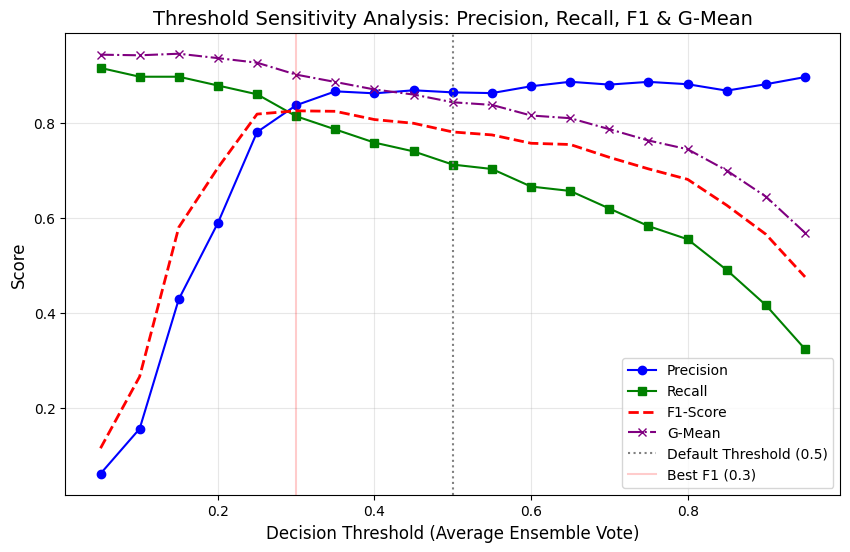

BEST EXPERIMENT RESULTS

Peak F1-Score: 0.8263 (at Threshold 0.30)
Peak G-Mean: 0.9466 (at Threshold 0.15)


Metrics at Optimal F1 Threshold (0.30):
 Precision: 0.8381
 Recall: 0.8148
 G-Mean: 0.9025


In [0]:
# Identify best results for the printout
best_f1_row = thresh_df.loc[thresh_df['F1'].idxmax()]
best_gmean_row = thresh_df.loc[thresh_df['G-Mean'].idxmax()]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', color='blue', marker='o')
plt.plot(thresh_df['Threshold'], thresh_df['Recall'], label='Recall', color='green', marker='s')
plt.plot(thresh_df['Threshold'], thresh_df['F1'], label='F1-Score', color='red', linestyle='--', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['G-Mean'], label='G-Mean', color='purple', linestyle='-.', marker='x')

plt.axvline(x=0.5, color='gray', linestyle=':', label='Default Threshold (0.5)')
plt.axvline(x=best_f1_row['Threshold'], color='red', linestyle='-', alpha=0.2, label=f"Best F1 ({best_f1_row['Threshold']})")

plt.title('Threshold Sensitivity Analysis: Precision, Recall, F1 & G-Mean', fontsize=14)
plt.xlabel('Decision Threshold (Average Ensemble Vote)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Results Printout
print("BEST EXPERIMENT RESULTS")
print()
print(f"Peak F1-Score: {best_f1_row['F1']:.4f} (at Threshold {best_f1_row['Threshold']:.2f})")
print(f"Peak G-Mean: {best_gmean_row['G-Mean']:.4f} (at Threshold {best_gmean_row['Threshold']:.2f})")
print()
print()
print(f"Metrics at Optimal F1 Threshold ({best_f1_row['Threshold']:.2f}):")
print(f" Precision: {best_f1_row['Precision']:.4f}")
print(f" Recall: {best_f1_row['Recall']:.4f}")
print(f" G-Mean: {best_f1_row['G-Mean']:.4f}")


In [0]:

train_final, test_final = load_preprocessed()

# Compile best-threshold results into a summary DataFrame for cross-variant comparison. Ttraining_duration is set in the model

import pandas as pd

# Select the threshold row that maximises F1-Score
final_row = thresh_df.loc[thresh_df['F1'].idxmax()]

# Recalculate confusion matrix values at the best F1 threshold
best_threshold = float(final_row['Threshold'])
y_pred_best = [1.0 if score >= best_threshold else 0.0 for score in y_scores]
tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_true, y_pred_best).ravel()

variant1_summary = [{
    "variant":  "Variant 1 - Local SMOTE Bagging (Baseline)",
    "threshold": best_threshold,
    "auc_roc": float(auc),
    "auprc": float(auprc),
    "precision": float(final_row['Precision']),
    "recall": float(final_row['Recall']),
    "f1": float(final_row['F1']),
    "gmean": float(final_row['G-Mean']),
    "tp": int(tp_b),
    "fp": int(fp_b),
    "fn": int(fn_b),
    "tn": int(tn_b),
    "training_time_sec": float(training_duration),   # set in training cell
    "num_trees": int(len(final_ensemble)),
    "num_partitions": int(train_final.rdd.getNumPartitions())
}]

variant1_summary_df = spark.createDataFrame(pd.DataFrame(variant1_summary))
display(variant1_summary_df)


Loaded train: 227848 rows | test: 56959 rows


variant,threshold,auc_roc,auprc,precision,recall,f1,gmean,tp,fp,fn,tn,training_time_sec,num_trees,num_partitions
Variant 1 - Local SMOTE Bagging (Baseline),0.3,0.9798938355428127,0.7741252319357195,0.8380952380952381,0.8148148148148148,0.8262910798122066,0.9025359621397566,88,17,20,56834,155.02865600585938,80,20


**Save Parquet**

In [0]:
# 1. Define the path to store the results
output_path = "/mnt/2026-group7/results/variant1_summary.parquet"

# 2. Save the DataFrame - 'overwrite' can re-run the cell if we update our model
variant1_summary_df.write.mode("overwrite").parquet(output_path)

print(f"Variant 1 results successfully saved to: {output_path}")

# 3. Verification - Read it back to ensure it saved correctly
check_df = spark.read.parquet(output_path)
display(check_df)

Variant 1 results successfully saved to: /mnt/2026-group7/results/variant1_summary.parquet


variant,threshold,auc_roc,auprc,precision,recall,f1,gmean,tp,fp,fn,tn,training_time_sec,num_trees,num_partitions
Variant 1 - Local SMOTE Bagging (Baseline),0.3,0.9798938355428127,0.7741252319357195,0.8380952380952381,0.8148148148148148,0.8262910798122066,0.9025359621397566,88,17,20,56834,155.02865600585938,80,20



## Section 4 — Variant 2A: Stratified Repartition via `sortBy` + Local SMOTEBagging


**Approach:** Stratified repartitioning using a custom RDD `sortBy` + `partitionBy` to guarantee balanced minority distribution across partitions (at the cost of 2 global shuffles). SMOTEbagging then runs locally per partition.



###4.1 Set up and Load

In [0]:
# Load fresh preprocessed data — clean slate
train_final_v2a, test_final_v2a = load_preprocessed()


Loaded train: 227848 rows | test: 56959 rows


####Check Number of Partitions

In [0]:
# 1. check number of partition in spark
print(f"Number of partitions: {train_final_v2a.rdd.getNumPartitions()}")

Number of partitions: 20


####Fix Shuffle Partitions

In [0]:
# Fix shuffle partitions for rest of pipeline
spark.conf.set("spark.sql.shuffle.partitions", 8)

# Coalesce to 8 — merges partitions down locally
train_final_v2a = train_final_v2a.coalesce(8)
test_final_v2a  = test_final_v2a.coalesce(8)

# Re-cache after coalesce
train_final_v2a.cache()
train_final_v2a.count()
test_final_v2a.cache()
test_final_v2a.count()

print(f"Train partitions: {train_final_v2a.rdd.getNumPartitions()}")
print(f"Test partitions:  {test_final_v2a.rdd.getNumPartitions()}")

Train partitions: 8
Test partitions:  8


####Check Minority Distribution before Repartitioning

In [0]:
#Check Minority Distribution before Repartitioning
current_dist_v2a = train_final_v2a.withColumn("part_id", spark_partition_id())

print("Minority rows per partition BEFORE stratified repartitioning:")
current_dist_v2a.filter(col("label") == 1).groupBy("part_id").count().orderBy("part_id").show()

Minority rows per partition BEFORE stratified repartitioning:
+-------+-----+
|part_id|count|
+-------+-----+
|      5|  251|
|      6|   72|
|      7|   61|
+-------+-----+



####Imports

In [0]:
# Imports
from pyspark.sql.functions import col, rand, ntile, spark_partition_id, sum as spark_sum, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql import Row, SparkSession
from pyspark.ml.linalg import Vectors, DenseVector
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.sql.types import StructType, StructField, DoubleType
import numpy as np
import time
import random
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score
)
import pandas as pd

### 4.2 Repartition the Data — `sortBy` approach

- custom RDD sortBy + partitionBy

*Note: introduces 2 global shuffles — guarantees perfect balance.*


In [0]:
# 2 shuffles — global sort guarantees perfectly uniform minority distribution across partitions

seed= 42
NUM_PARTITIONS_v2a= 8

# separate training data by class label
minority_df_v2a = train_final_v2a.filter(col("label") == 1)
majority_df_v2a = train_final_v2a.filter(col("label") == 0)
minority_df_v2a.cache()
majority_df_v2a.cache()

# assign random partition keys using seeded hash

'''
SHUFFLE 1 — global sortBy (worker to worker)
Rows physically move between executors to establish
a globally randomised ordering based on their random keys
This ensures minority and majority rows are truly interleaved
'''

def assign_and_partition(rdd, num_partitions, seed):
    def add_key(row):
        rng = random.Random(seed + hash(row)) 
        return (rng.random(), row)

    keyed = rdd.map(add_key)
    sorted_rdd = keyed.sortBy(lambda x: x[0])
    indexed = sorted_rdd.zipWithIndex()

    return indexed.map(
        lambda x: (int(x[1] % num_partitions), x[0][1])
    )

minority_assigned_v2a = assign_and_partition(minority_df_v2a.rdd, NUM_PARTITIONS_v2a,seed)
majority_assigned_v2a = assign_and_partition(majority_df_v2a.rdd, NUM_PARTITIONS_v2a,seed+1)

# union is a logical operation — no shuffle
combined_a = minority_assigned_v2a.union(majority_assigned_v2a)

'''
SHUFFLE 2 — partitionBy(P) (worker to worker)
Rows physically routed to their designated target partition
Result: perfectly uniform minority + majority distribution
'''

start = time.time()
train_repartitioned_a = combined_a.partitionBy(NUM_PARTITIONS_v2a) \
                                   .map(lambda x: x[1])
train_repartitioned_a = spark.createDataFrame(
    train_repartitioned_a,
    schema=train_final.schema
)
train_repartitioned_a.cache()
train_repartitioned_a.count()
end = time.time()

print(f"Option A time: {round(end-start, 2)} seconds")

# Verify — check minority and majority counts per partition
# Both classes should appear in every partition
verify_a = train_repartitioned_a.withColumn("part_id", spark_partition_id())
verify_a.groupBy("part_id").agg(
    spark_sum(when(col("label") == 0, 1).otherwise(0)).alias("majority_count"),
    spark_sum(when(col("label") == 1, 1).otherwise(0)).alias("minority_count")
).orderBy("part_id").show()

Option A time: 11.03 seconds
+-------+--------------+--------------+
|part_id|majority_count|minority_count|
+-------+--------------+--------------+
|      0|         28433|            48|
|      1|         28433|            48|
|      2|         28433|            48|
|      3|         28433|            48|
|      4|         28433|            48|
|      5|         28433|            48|
|      6|         28433|            48|
|      7|         28433|            48|
+-------+--------------+--------------+



In [0]:
# VERIFY TOTAL ROW COUNT
# Should match original train_final counts

total_v2a = train_repartitioned_a.count()
minority_total_v2a = train_repartitioned_a.filter(col("label") == 1).count()
majority_total_v2a = train_repartitioned_a.filter(col("label") == 0).count()

print(f"Total rows:{total_v2a}")
print(f"Minority rows: {minority_total_v2a}")
print(f"Majority rows: {majority_total_v2a}")
print(f"Sum check:{minority_total_v2a + majority_total_v2a} (should equal {total_v2a})")

print(f"\nOriginal train_final:")
print(f"Total: {train_final_v2a.count()}")
train_final_v2a.groupBy("label").count().show()

Total rows:227848
Minority rows: 384
Majority rows: 227464
Sum check:227848 (should equal 227848)

Original train_final:
Total: 227848
+-----+------+
|label| count|
+-----+------+
|    0|227464|
|    1|   384|
+-----+------+



####SMOTE Algorithm

Runs locally on minority samples inside each partition via mapPartitions()


In [0]:
# Smote Algorthm: Runs locally inside each partition via mapPartitions()

"""
    Run SMOTE on a list of minority samples within one partition.
    
    Parameters:
    1- minority_samples: list of feature vectors (numpy arrays)
    2- k:number of nearest neighbours
    3- oversample_rate: float e.g. 0.5 = generate 50% more samples
    
    Returns: list of synthetic feature vectors
    """

def smote_partition(minority_samples, k, oversample_rate):
    
    # Need at least k+1 samples to find k neighbours
    if len(minority_samples) <= k:
        return []
    
    n_synthetic = int(len(minority_samples) * oversample_rate)
    synthetic_samples = []
    
    # Convert to numpy array for distance calculations
    samples_array = np.array(minority_samples)
    
    for _ in range(n_synthetic):
        # Step 1 — pick a random minority sample
        idx = np.random.randint(0, len(minority_samples))
        sample = samples_array[idx]
        
        # Step 2 — find k nearest neighbours using Euclidean distance
        distances = np.sqrt(np.sum((samples_array - sample) ** 2, axis=1))
        distances[idx] = np.inf  # exclude self and take distance from all other rows
        neighbour_indices = np.argsort(distances)[:k]  # sort and take top 5 closest distances
        
        # Step 3 — pick one neighbour randomly out of the 5 closest
        neighbour_idx = np.random.choice(neighbour_indices)
        neighbour = samples_array[neighbour_idx]
        
        # Step 4 — interpolate between sample and neighbour (instead of duplicating to create a new sample)
        gap = np.random.random()  # random number between 0 and 1
        synthetic = sample + gap * (neighbour - sample)
        synthetic_samples.append(synthetic)
    
    return synthetic_samples

####SMOTE Validation - Test on a Tiny Sample

In [0]:
# Test before running on full data

# Extract minority samples from partition 0 only for testing
minority_sample_test_v2a = train_repartitioned_a.filter(col("label") == 1) \
                                                 .limit(20) \
                                                 .collect()

# Convert to numpy arrays
minority_vectors_v2a = [np.array(row["features"].toArray()) for row in minority_sample_test_v2a]

print(f"Test minority samples: {len(minority_vectors_v2a)}")
print(f"Feature vector length: {len(minority_vectors_v2a[0])}")

# Test SMOTE with 50% oversample rate (bag 5 equivalent)
synthetic_v2a = smote_partition(minority_vectors_v2a, k=5, oversample_rate=0.5)

print(f"\nSynthetic samples generated: {len(synthetic_v2a)}")
print(f"Expected: {int(len(minority_vectors_v2a) * 0.5)} (50% of {len(minority_vectors_v2a)})")
print(f"\nFirst synthetic sample (first 5 features):")
print(synthetic_v2a[0][:5])
print(f"\nOriginal sample (first 5 features):")
print(minority_vectors_v2a[0][:5])

Test minority samples: 20
Feature vector length: 29

Synthetic samples generated: 10
Expected: 10 (50% of 20)

First synthetic sample (first 5 features):
[-0.38981049  1.667822   -1.571096    2.78397097 -0.79436297]

Original sample (first 5 features):
[-1.5487881   1.80869795 -0.95350903  2.21308539 -2.01572779]


####SMOTE Validation - Test all 10 Oversampling Rates (bag 1-10)

In [0]:
# Rate = bag_number × 10%

print("Oversampling rate tests:")
print(f"{'Bag':<6} {'Rate':<8} {'Input':<8} {'Expected':<10} {'Generated':<10} {'Match'}")
print("-" * 52)

for bag in range(1, 11):
    rate = bag * 0.1
    synthetic_v2a = smote_partition(minority_vectors_v2a, k=5, oversample_rate=rate)
    expected = int(len(minority_vectors_v2a) * rate)
    match = "Yes" if len(synthetic_v2a) == expected else "x"
    print(f"{bag:<6} {rate:<8.1f} {len(minority_vectors_v2a):<8} {expected:<10} {len(synthetic_v2a):<10} {match}")

Oversampling rate tests:
Bag    Rate     Input    Expected   Generated  Match
----------------------------------------------------
1      0.1      20       2          2          Yes
2      0.2      20       4          4          Yes
3      0.3      20       6          6          Yes
4      0.4      20       8          8          Yes
5      0.5      20       10         10         Yes
6      0.6      20       12         12         Yes
7      0.7      20       14         14         Yes
8      0.8      20       16         16         Yes
9      0.9      20       18         18         Yes
10     1.0      20       20         20         Yes


### 4.3 SmoteBagging Loop


SMOTE validated. Now integrating into the full bagging pipeline.

- Each partition runs T=10 bags independently
- 8 partitions × 10 bags = 80 trees total
- Only predictions travel to driver — zero data movement

Note: smote_partition redefined inside process_partition because workers cannot access driver-side functions

In [0]:
# define T (number of bags) and K (number of nearest neighbours)
T_v2a = 10
K_v2a = 5

'''
DRIVER — collect test set once and broadcast to all workers
Without broadcast: test data fetched 80 separate times
With broadcast: sent once per worker, reused for all 10 bags
'''
test_collected_v2a   = test_final_v2a.collect()
test_features_v2a    = [
    row["features"].toArray().tolist() if hasattr(row["features"], 'toArray')
    else list(row["features"])
    for row in test_collected_v2a
]
test_labels_v2a      = [row["label"] for row in test_collected_v2a]
test_features_bc_v2a = sc.broadcast(test_features_v2a)
test_labels_bc_v2a   = sc.broadcast(test_labels_v2a)
T_bc_v2a = sc.broadcast(T_v2a)
K_bc_v2a = sc.broadcast(K_v2a)

print(f"Test samples collected: {len(test_collected_v2a)}")
print(f"T={T_v2a} bags per partition, k={K_v2a}")
print(f"Total trees = {T_v2a} x 8 partitions = {T_v2a * 8}")

'''
WORKER — process_partition()
Runs entirely on each worker independently via mapPartitions
No data leaves the worker during this function
Returns T sets of predictions (one per bag)
'''
def process_partition_v2a(partition_id, rows):
    import numpy as np
    from sklearn.tree import DecisionTreeClassifier

    # Worker: load partition rows into memory
    rows_list = list(rows)
    if len(rows_list) == 0:
        return iter([])

    # Worker: separate minority and majority locally
    minority = [r for r in rows_list if r["label"] == 1]
    majority = [r for r in rows_list if r["label"] == 0]

    if len(minority) == 0 or len(majority) == 0:
        return iter([])

    # Worker: retrieve broadcast values
    # test data, T, K all sent from driver before mapPartitions
    t_features = test_features_bc_v2a.value
    T_local = T_bc_v2a.value
    K_local = K_bc_v2a.value

    # Convert test features to numpy once — reused for all 10 bags
    # test_features_v2a contains plain lists — no .toArray() needed
    test_X = np.array(t_features, dtype=np.float64)

    # Helper — handles both DenseVector and plain list    
    def to_numpy(feat):
        if hasattr(feat, 'toArray'):
            return feat.toArray()
        return np.array(feat, dtype=np.float64)

    '''
    Worker: redefine SMOTE locally
    Workers cannot access driver-side functions
    rng passed in so randomness is controlled by bag_seed
    '''
    def smote_partition(minority_samples, k, oversample_rate, rng):
        if len(minority_samples) <= k:
            return []

        n_synthetic = int(len(minority_samples) * oversample_rate)
        synthetic_samples = []
        samples_array = np.array(minority_samples)

        for _ in range(n_synthetic):
            # Step 1 — pick a random minority sample
            idx = rng.randint(0, len(minority_samples))
            sample = samples_array[idx]

            # Step 2 — find k nearest neighbours using Euclidean distance
            distances = np.sqrt(np.sum((samples_array - sample) ** 2, axis=1))
            distances[idx] = np.inf  # exclude self
            neighbour_indices = np.argsort(distances)[:k]

            # Step 3 — pick one neighbour randomly from the k closest
            neighbour_idx = neighbour_indices[rng.randint(0, len(neighbour_indices))]
            neighbour = samples_array[neighbour_idx]

            # Step 4 — interpolate between sample and neighbour
            gap = rng.random()
            synthetic = sample + gap * (neighbour - sample)
            synthetic_samples.append(synthetic)

        return synthetic_samples

    results = []

    '''
    Worker: run T=10 bags locally
    Each bag gets its own reproducible seed: partition_id * 1000 + bag
    This ensures identical results on every run
    '''

    for bag in range(1, T_local + 1):

        # Reproducible seed per partition+bag combination
        bag_seed = partition_id * 1000 + bag
        rng = np.random.RandomState(bag_seed)

        oversample_rate = bag * 0.1  # 10%, 20%, ... 100%

        # Worker Step 1 — bootstrap majority with replacement
        # rng ensures same bootstrap sample every run for this bag
        bootstrap_majority = [
            majority[rng.randint(0, len(majority))]
            for _ in range(len(majority))
        ]

        # Worker Step 2 — local SMOTE on minority
        # k-NN uses only local partition minority — Variant 2 design
        minority_vectors = [to_numpy(r["features"]) for r in minority]
        synthetic_vectors = smote_partition(
            minority_vectors,
            k=K_local,
            oversample_rate=oversample_rate,
            rng=rng
        )

        # Worker: combine into balanced training set
        # bootstrap majority (0) + original minority (1) + synthetic (1)
        X_train = []
        y_train = []

        for r in bootstrap_majority:
            X_train.append(to_numpy(r["features"]))
            y_train.append(0)
        for r in minority:
            X_train.append(to_numpy(r["features"]))
            y_train.append(1)
        for s in synthetic_vectors:
            X_train.append(s)
            y_train.append(1)

        X_train = np.array(X_train)
        y_train = np.array(y_train)

        # Worker Step 3 — train Decision Tree on balanced bag
        # random_state=bag_seed ensures tree is reproducible
        dt = DecisionTreeClassifier(max_depth=10, random_state=bag_seed)
        dt.fit(X_train, y_train)

        # Worker Step 4 — predict on full test set
        # model stays on worker — only predictions returned to driver
        bag_preds = dt.predict(test_X).tolist()
        results.append([int(p) for p in bag_preds])

    # Worker: return 10 prediction lists — only thing leaving worker
    return iter(results)

'''
DRIVER — trigger mapPartitionsWithIndex across all 8 partitions
mapPartitionsWithIndex passes (partition_id, rows) to each worker
partition_id is used to seed randomness: partition_id * 1000 + bag
All 8 partitions run simultaneously on their workers
.collect() pulls only predictions back to driver — no data movement
'''

start = time.time()

all_predictions_v2a = train_repartitioned_a.rdd \
                        .mapPartitionsWithIndex(process_partition_v2a) \
                        .collect()

end = time.time()

training_time_v2a = round(end - start, 2)

# DRIVER — results summary
print(f"\nTotal training time: {training_time_v2a} seconds")
print(f"Total trees collected: {len(all_predictions_v2a)}")
print(f"Expected: {T_v2a * 8} trees")
print(f"Predictions matrix: {len(all_predictions_v2a)} trees x {len(all_predictions_v2a[0])} test samples")

Test samples collected: 56959
T=10 bags per partition, k=5
Total trees = 10 x 8 partitions = 80

Total training time: 19.03 seconds
Total trees collected: 80
Expected: 80 trees
Predictions matrix: 80 trees x 56959 test samples


####Majority Vote

In [0]:
# For each test sample — count votes across 80 trees
# If more than 40 trees say fraud (1) → predict fraud
# If 40 or fewer say fraud → predict not fraud

# all_predictions_v2a shape: 80 trees × 57,003 test samples
# Convert to numpy array for easy column-wise operations
predictions_matrix_v2a = np.array(all_predictions_v2a)
print(f"Predictions matrix shape: {predictions_matrix_v2a.shape}")

vote_sums_v2a = predictions_matrix_v2a.sum(axis=0)
vote_scores_v2a = vote_sums_v2a / len(all_predictions_v2a)   # fraction 0-1, used for AUC/AUPRC
final_preds_v2a = (vote_scores_v2a > 0.5).astype(int)        # threshold = 0.5
final_labels_v2a = np.array(test_labels_v2a)

print(f"Final predictions shape: {final_preds_v2a.shape}")
print(f"Predicted fraud cases:{final_preds_v2a.sum()}")
print(f"Actual fraud cases:{final_labels_v2a.sum()}")

Predictions matrix shape: (80, 56959)
Final predictions shape: (56959,)
Predicted fraud cases:94
Actual fraud cases:108


#### Model Evaluation

AUC, AUPRC, F1, G-mean, Precision, Recall

In [0]:
# Convert to numpy arrays
y_true_v2a  = np.array(test_labels_v2a)
y_pred_v2a  = final_preds_v2a
y_score_v2a = vote_scores_v2a   # fraction of trees voting fraud — used for AUC/AUPRC

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true_v2a, y_pred_v2a).ravel()

print("Confusion Matrix:")
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

# Metrics
precision_v2a = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_v2a = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_v2a = f1_score(y_true_v2a, y_pred_v2a)
auc_v2a = roc_auc_score(y_true_v2a, y_score_v2a)          # scores, not binary
auprc_v2a = average_precision_score(y_true_v2a, y_score_v2a)  # scores, not binary

# G-mean
sensitivity_v2a = recall_v2a
specificity_v2a = tn / (tn + fp) if (tn + fp) > 0 else 0
gmean_v2a = np.sqrt(sensitivity_v2a * specificity_v2a)

print(f"\nEvaluation Metrics (threshold = 0.5):")
print(f" AUC: {round(auc_v2a, 4)}")
print(f" AUPRC:{round(auprc_v2a, 4)}")
print(f" F1 Score:{round(f1_v2a, 4)}")
print(f" G-mean:{round(gmean_v2a, 4)}")
print(f" Precision:{round(precision_v2a, 4)}")
print(f" Recall:{round(recall_v2a, 4)}")
print(f" Sensitivity:{round(sensitivity_v2a, 4)}")
print(f" Specificity:{round(specificity_v2a, 4)}")

Confusion Matrix:
True Negatives  (TN): 56839
False Positives (FP): 12
False Negatives (FN): 26
True Positives  (TP): 82

Evaluation Metrics (threshold = 0.5):
 AUC: 0.9705
 AUPRC:0.8352
 F1 Score:0.8119
 G-mean:0.8713
 Precision:0.8723
 Recall:0.7593
 Sensitivity:0.7593
 Specificity:0.9998


### 4.4 Threshold Sensitivity Analysis

In [0]:
# Uses vote_scores from majority vote cell — no retraining
# Varies the decision threshold from 0.1 to 0.9
# Reports how precision, recall, F1, G-mean change
# AUC and AUPRC are threshold-independent — reported once

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results_v2a = []

print(f"{'Thresh':<8} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<8} "
      f"{'Prec':<8} {'Recall':<8} {'F1':<8} {'G-Mean':<8} {'Spec':<8}")
print("-" * 80)

for thresh in thresholds:
    # Apply threshold to vote scores
    preds = (vote_scores_v2a > thresh).astype(int)

    tp_t = int(np.sum((y_true_v2a == 1) & (preds == 1)))
    fp_t = int(np.sum((y_true_v2a == 0) & (preds == 1)))
    fn_t = int(np.sum((y_true_v2a == 1) & (preds == 0)))
    tn_t = int(np.sum((y_true_v2a == 0) & (preds == 0)))

    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    rec_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    spec_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0
    gm_t   = np.sqrt(rec_t * spec_t)

    print(f"{thresh:<8.1f} {tp_t:<6} {fp_t:<6} {fn_t:<6} {tn_t:<8} "
          f"{prec_t:<8.4f} {rec_t:<8.4f} {f1_t:<8.4f} {gm_t:<8.4f} {spec_t:<8.4f}")

    threshold_results_v2a.append({
        "threshold": float(thresh),
        "tp": tp_t, "fp": fp_t, "fn": fn_t, "tn": tn_t,
        "precision": prec_t,
        "recall": rec_t,
        "f1": f1_t,
        "g_mean": gm_t,
        "specificity": spec_t
    })

# Threshold-independent metrics reported once
print(f"\nAUC-ROC (threshold-independent): {auc_v2a:.4f}")
print(f"AUPRC   (threshold-independent): {auprc_v2a:.4f}")

# Find best thresholds
best_f1_v2a = max(threshold_results_v2a, key=lambda r: r["f1"])
best_gm_v2a = max(threshold_results_v2a, key=lambda r: r["g_mean"])

print(f"\nBest F1 threshold:     {best_f1_v2a['threshold']:.1f} "
      f"-> F1={best_f1_v2a['f1']:.4f}, "
      f"Precision={best_f1_v2a['precision']:.4f}, "
      f"Recall={best_f1_v2a['recall']:.4f}")

print(f"Best G-Mean threshold: {best_gm_v2a['threshold']:.1f} "
      f"-> G-Mean={best_gm_v2a['g_mean']:.4f}, "
      f"Precision={best_gm_v2a['precision']:.4f}, "
      f"Recall={best_gm_v2a['recall']:.4f}")

Thresh   TP     FP     FN     TN       Prec     Recall   F1       G-Mean   Spec    
--------------------------------------------------------------------------------
0.1      95     53     13     56798    0.6419   0.8796   0.7422   0.9374   0.9991  
0.2      93     24     15     56827    0.7949   0.8611   0.8267   0.9278   0.9996  
0.3      89     19     19     56832    0.8241   0.8241   0.8241   0.9076   0.9997  
0.4      83     14     25     56837    0.8557   0.7685   0.8098   0.8765   0.9998  
0.5      82     12     26     56839    0.8723   0.7593   0.8119   0.8713   0.9998  
0.6      81     8      27     56843    0.9101   0.7500   0.8223   0.8660   0.9999  
0.7      76     7      32     56844    0.9157   0.7037   0.7958   0.8388   0.9999  
0.8      55     3      53     56848    0.9483   0.5093   0.6627   0.7136   0.9999  
0.9      40     1      68     56850    0.9756   0.3704   0.5369   0.6086   1.0000  

AUC-ROC (threshold-independent): 0.9705
AUPRC   (threshold-independent): 0.835

####Plot for Threshold Sensitivity Analysis

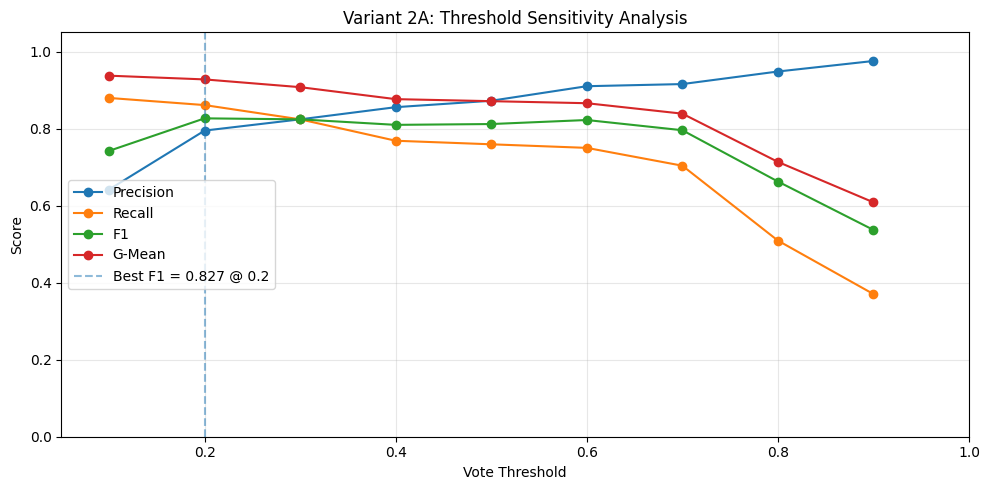


Threshold sweep summary:
  Best F1 threshold:     0.2 -> F1=0.8267
  Best G-Mean threshold: 0.1 -> G-Mean=0.9374

Note: Cross-variant comparison uses threshold=0.5 for fairness.
      AUC and AUPRC are always threshold-independent.


In [0]:
thresh_vals_v2a = [r["threshold"] for r in threshold_results_v2a]
prec_vals_v2a  = [r["precision"] for r in threshold_results_v2a]
rec_vals_v2a  = [r["recall"] for r in threshold_results_v2a]
f1_vals_v2a   = [r["f1"] for r in threshold_results_v2a]
gm_vals_v2a = [r["g_mean"] for r in threshold_results_v2a]

plt.figure(figsize=(10, 5))

plt.plot(thresh_vals_v2a, prec_vals_v2a, marker="o", label="Precision")
plt.plot(thresh_vals_v2a, rec_vals_v2a,  marker="o", label="Recall")
plt.plot(thresh_vals_v2a, f1_vals_v2a,   marker="o", label="F1")
plt.plot(thresh_vals_v2a, gm_vals_v2a,   marker="o", label="G-Mean")

# Mark best F1 threshold
plt.axvline(
    x=best_f1_v2a["threshold"],
    linestyle="--",
    alpha=0.5,
    label=f"Best F1 = {best_f1_v2a['f1']:.3f} @ {best_f1_v2a['threshold']:.1f}"
)

plt.xlabel("Vote Threshold")
plt.ylabel("Score")
plt.title("Variant 2A: Threshold Sensitivity Analysis")
plt.legend(loc="center left")
plt.grid(True, alpha=0.3)
plt.xlim(0.05, 1.0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"\nThreshold sweep summary:")
print(f"  Best F1 threshold:     {best_f1_v2a['threshold']:.1f} -> F1={best_f1_v2a['f1']:.4f}")
print(f"  Best G-Mean threshold: {best_gm_v2a['threshold']:.1f} -> G-Mean={best_gm_v2a['g_mean']:.4f}")
print(f"\nNote: Cross-variant comparison uses threshold=0.5 for fairness.")
print(f"      AUC and AUPRC are always threshold-independent.")

#### Save Final Results

In [0]:
# DRIVER — save Variant 2 summary results
# Threshold 0.5 used — fair comparison across all variants

variant2A_summary = [{
    "variant":              "Variant 2 - Stratified Repartition Option A",
    "threshold":0.5,
    "auc_roc": float(auc_v2a),
    "auprc": float(auprc_v2a),
    "precision":float(precision_v2a),
    "recall": float(recall_v2a),
    "f1": float(f1_v2a),
    "specificity": float(specificity_v2a),
    "gmean": float(gmean_v2a),
    "training_time_sec": float(training_time_v2a),
    "num_trees":int(T_v2a * 8),
    "num_partitions": int(8)
}]

variant2A_summary_df = spark.createDataFrame(pd.DataFrame(variant2A_summary))

display(variant2A_summary_df)

variant,threshold,auc_roc,auprc,precision,recall,f1,specificity,gmean,training_time_sec,num_trees,num_partitions
Variant 2 - Stratified Repartition Option A,0.5,0.970496300596035,0.8351914557144681,0.8723404255319149,0.7592592592592593,0.8118811881188118,0.9997889219186997,0.8712628743792572,19.03,80,8


#### Save to Parquet

In [0]:
# Save threshold sweep and summary to shared storage

threshold_results_df_v2a = spark.createDataFrame(pd.DataFrame(threshold_results_v2a))

threshold_results_df_v2a.write.mode("overwrite").parquet("/mnt/2026-group7/results/variant2_threshold_sweep_A.parquet")
variant2A_summary_df.write.mode("overwrite").parquet("/mnt/2026-group7/results/variant2_summary_A.parquet")

print("Results saved:")
print("  /mnt/2026-group7/results/variant2_threshold_sweep_A.parquet")
print("  /mnt/2026-group7/results/variant2_summary_A.parquet")

Results saved:
  /mnt/2026-group7/results/variant2_threshold_sweep_A.parquet
  /mnt/2026-group7/results/variant2_summary_A.parquet



## Section 5 — Variant 2B: Stratified Repartition via `mapPartitions` + Local SMOTEBagging


**Approach:** Stratified repartitioning using local partition-ID assignment (`mapPartitions`) + `partitionBy` — only 1 shuffle (vs 2 in V2A). SMOTE and bagging run locally per partition. More scalable repartitioning strategy.


### 5.1 Set up and Load

In [0]:

# Load fresh preprocessed data — clean slate
train_final_v2b, test_final_v2b = load_preprocessed()

Loaded train: 227848 rows | test: 56959 rows


####Examine Partitions

In [0]:
# 1. check number of partition in spark
print(f"Number of partitions: {train_final_v2b.rdd.getNumPartitions()}")

Number of partitions: 20


####Fix Shuffle Partitions

In [0]:
# Fix shuffle partitions for rest of pipeline
spark.conf.set("spark.sql.shuffle.partitions", 8)

# Coalesce to 8 — merges 48 partitions down locally
train_final_v2b = train_final_v2b.coalesce(8)
test_final_v2b  = test_final_v2b.coalesce(8)

# Re-cache after coalesce
train_final_v2b.cache()
train_final_v2b.count()
test_final_v2b.cache()
test_final_v2b.count()

print(f"Train partitions: {train_final_v2b.rdd.getNumPartitions()}")
print(f"Test partitions:  {test_final_v2b.rdd.getNumPartitions()}")

Train partitions: 8
Test partitions:  8


####Check Partition (Minority and Majority) Distribution before Repartitioning

In [0]:
# Check majority and minority distribution before repartitioning
current_dist_v2b = train_final_v2b.withColumn("part_id", spark_partition_id())

print("Class distribution per partition BEFORE stratified repartitioning:")
current_dist_v2b.groupBy("part_id").agg(
    spark_sum(when(col("label") == 0, 1).otherwise(0)).alias("majority_count"),
    spark_sum(when(col("label") == 1, 1).otherwise(0)).alias("minority_count")
).orderBy("part_id").show()

Class distribution per partition BEFORE stratified repartitioning:
+-------+--------------+--------------+
|part_id|majority_count|minority_count|
+-------+--------------+--------------+
|      0|         39220|             0|
|      1|         58635|             0|
|      2|         38974|             0|
|      3|         58252|             0|
|      4|         32383|             0|
|      5|             0|           251|
|      6|             0|            72|
|      7|             0|            61|
+-------+--------------+--------------+



**Problem Identification Summary**

Output from Minority Distribution before Repartitioning shows that only 4/8 paritions contain minorty sample and partition 0,1,2,4 contain 0 minority samples. 

This issue needs to be fixed by a distributed design which balances majority and minority samples evenly across all 8 partitions

### 5.2 Repartition the Data — `mapPartitions` approach

- mapPartitions + partitionBy

*Note: local ID assignment only — 1 shuffle, no global sort.*



In [0]:
# 1 shuffle only — local ID assignment, no global sort

NUM_PARTITIONS_v2b = 8

# Separate by class
minority_df_v2b = train_final_v2b.filter(col("label") == 1)
majority_df_v2b = train_final_v2b.filter(col("label") == 0)
minority_df_v2b.cache()
majority_df_v2b.cache()

# Local round robin ID assignment — no shuffle
def assign_ids_local_v2b(rows):
    for i, row in enumerate(rows):
        yield (int(i % NUM_PARTITIONS_v2b), row)

# Apply locally on each partition
minority_keyed_v2b = minority_df_v2b.rdd.mapPartitions(assign_ids_local_v2b)
majority_keyed_v2b = majority_df_v2b.rdd.mapPartitions(assign_ids_local_v2b)

# Union — logical operation, no shuffle
combined_v2b = minority_keyed_v2b.union(majority_keyed_v2b)

# ONE shuffle — send rows to correct partition
start = time.time()
train_repartitioned_b = combined_v2b.partitionBy(NUM_PARTITIONS_v2b) \
                                     .map(lambda x: x[1])
train_repartitioned_b = spark.createDataFrame(
    train_repartitioned_b,
    schema=train_final_v2b.schema
)
train_repartitioned_b.cache()
train_repartitioned_b.count()
end = time.time()

print(f"Option B time: {round(end - start, 2)} seconds")

# Verify balance — both classes per partition
verify_b = train_repartitioned_b.withColumn("part_id", spark_partition_id())

verify_b.groupBy("part_id").agg(
    spark_sum(when(col("label") == 0, 1).otherwise(0)).alias("majority_count"),
    spark_sum(when(col("label") == 1, 1).otherwise(0)).alias("minority_count")
).orderBy("part_id").show()

Option B time: 10.06 seconds
+-------+--------------+--------------+
|part_id|majority_count|minority_count|
+-------+--------------+--------------+
|      0|         28435|            49|
|      1|         28435|            49|
|      2|         28435|            49|
|      3|         28434|            48|
|      4|         28432|            48|
|      5|         28432|            47|
|      6|         28431|            47|
|      7|         28430|            47|
+-------+--------------+--------------+



####Verify Total Row Count

In [0]:

# verify
total_b = train_repartitioned_b.count()
minority_total_b = train_repartitioned_b.filter(col("label") == 1).count()
majority_total_b = train_repartitioned_b.filter(col("label") == 0).count()

print(f"Total rows: {total_b}")
print(f"Minority rows: {minority_total_b}")
print(f"Majority rows: {majority_total_b}")
print(f"Sum check: {minority_total_b + majority_total_b} (should equal {total_b})")

print(f"\nOriginal train_final_v2b:")
print(f"Total: {train_final_v2b.count()}")
train_final_v2b.groupBy("label").count().show()

Total rows: 227848
Minority rows: 384
Majority rows: 227464
Sum check: 227848 (should equal 227848)

Original train_final_v2b:
Total: 227848
+-----+------+
|label| count|
+-----+------+
|    0|227464|
|    1|   384|
+-----+------+



**Note:** No data loss has occured. Next step is to apply smote bagging on each partition.

#### SMOTE Algorithm
Runs locally on minority samples inside each partition via mapPartitions()

In [0]:
# Smote Algorthm: Runs locally inside each partition via mapPartitions()

"""
    Run SMOTE on a list of minority samples within one partition.
    
    Parameters:
    1- minority_samples: list of feature vectors (numpy arrays)
    2- k:number of nearest neighbours
    3- oversample_rate: float e.g. 0.5 = generate 50% more samples
    
    Returns: list of synthetic feature vectors
    """

def smote_partition_v2b(minority_samples, k, oversample_rate):
    
    # Need at least k+1 samples to find k neighbours
    if len(minority_samples) <= k:
        return []
    
    n_synthetic = int(len(minority_samples) * oversample_rate)
    synthetic_samples = []
    
    # Convert to numpy array for distance calculations
    samples_array = np.array(minority_samples)
    
    for _ in range(n_synthetic):
        # Step 1 — pick a random minority sample
        idx = np.random.randint(0, len(minority_samples))
        sample = samples_array[idx]
        
        # Step 2 — find k nearest neighbours using Euclidean distance
        distances = np.sqrt(np.sum((samples_array - sample) ** 2, axis=1))
        distances[idx] = np.inf  # exclude self and take distance from all other rows
        neighbour_indices = np.argsort(distances)[:k]  # sort and take top 5 closest distances
        
        # Step 3 — pick one neighbour randomly out of the 5 closest
        neighbour_idx = np.random.choice(neighbour_indices)
        neighbour = samples_array[neighbour_idx]
        
        # Step 4 — interpolate between sample and neighbour (instead of duplicating to create a new sample)
        gap = np.random.random()  # random number between 0 and 1
        synthetic = sample + gap * (neighbour - sample)
        synthetic_samples.append(synthetic)
    
    return synthetic_samples

####SMOTE Validation - Test on a Tiny Sample

In [0]:
# Test before running on full data

# Extract minority samples from partition 0 only for testing
minority_sample_test_v2b = train_repartitioned_b.filter(col("label") == 1) \
                                                 .limit(20) \
                                                 .collect()

# Convert to numpy arrays
minority_vectors_v2b = [np.array(row["features"].toArray()) for row in minority_sample_test_v2b]

print(f"Test minority samples: {len(minority_vectors_v2b)}")
print(f"Feature vector length: {len(minority_vectors_v2b[0])}")

# Test SMOTE with 50% oversample rate (bag 5 equivalent)
synthetic_v2b = smote_partition_v2b(minority_vectors_v2b, k=5, oversample_rate=0.5)

print(f"\nSynthetic samples generated: {len(synthetic_v2b)}")
print(f"Expected: {int(len(minority_vectors_v2b) * 0.5)} (50% of {len(minority_vectors_v2b)})")
print(f"\nFirst synthetic sample (first 5 features):")
print(synthetic_v2b[0][:5])
print(f"\nOriginal sample (first 5 features):")
print(minority_vectors_v2b[0][:5])

Test minority samples: 20
Feature vector length: 29

Synthetic samples generated: 10
Expected: 10 (50% of 20)

First synthetic sample (first 5 features):
[-1.46629833  3.30840701 -4.65709257  2.52301585 -1.18634898]

Original sample (first 5 features):
[-28.70922925  22.05772899 -27.85581113  11.84501291 -18.98381258]


####SMOTE Validation - Test all 10 Oversampling Rates (bag 1-10)

In [0]:
# Rate = bag_number × 10%

print("Oversampling rate tests:")
print(f"{'Bag':<6} {'Rate':<8} {'Input':<8} {'Expected':<10} {'Generated':<10} {'Match'}")
print("-" * 52)

for bag in range(1, 11):
    rate = bag * 0.1
    synthetic_v2b = smote_partition_v2b(minority_vectors_v2b, k=5, oversample_rate=rate)
    expected = int(len(minority_vectors_v2b) * rate)
    match = "Yes" if len(synthetic_v2b) == expected else "x"
    print(f"{bag:<6} {rate:<8.1f} {len(minority_vectors_v2b):<8} {expected:<10} {len(synthetic_v2b):<10} {match}")

Oversampling rate tests:
Bag    Rate     Input    Expected   Generated  Match
----------------------------------------------------
1      0.1      20       2          2          Yes
2      0.2      20       4          4          Yes
3      0.3      20       6          6          Yes
4      0.4      20       8          8          Yes
5      0.5      20       10         10         Yes
6      0.6      20       12         12         Yes
7      0.7      20       14         14         Yes
8      0.8      20       16         16         Yes
9      0.9      20       18         18         Yes
10     1.0      20       20         20         Yes


### 5.3 SmoteBagging Loop


SMOTE validated. Now integrating into the full bagging pipeline.

- Each partition runs T=10 bags independently
- 8 partitions × 10 bags = 80 trees total
- Only predictions travel to driver — zero data movement

Note: smote_partition redefined inside process_partition because workers cannot access driver-side functions

In [0]:
# define T (number of bags) and K (number of nearest neighbours)
T_v2b = 10
K_v2b = 5

# DRIVER — collect test set once and broadcast to all workers
# Without broadcast: test data fetched 80 separate times
# With broadcast: sent once per worker, reused for all 10 bags
test_collected_v2b   = test_final_v2b.collect()
test_features_v2b    = [
    row["features"].toArray().tolist() if hasattr(row["features"], 'toArray')
    else list(row["features"])
    for row in test_collected_v2b
]
test_labels_v2b = [row["label"] for row in test_collected_v2b]
test_features_bc_v2b = sc.broadcast(test_features_v2b)
test_labels_bc_v2b   = sc.broadcast(test_labels_v2b)
T_bc_v2b  = sc.broadcast(T_v2b)
K_bc_v2b  = sc.broadcast(K_v2b)

print(f"Test samples collected: {len(test_collected_v2b)}")
print(f"T={T_v2b} bags per partition, k={K_v2b}")
print(f"Total trees = {T_v2b} x 8 partitions = {T_v2b * 8}")


# WORKER — process_partition_v2b()
# Runs entirely on each partition independently via mapPartitions
# No data leaves the partition during this function
# Returns T sets of predictions (one per bag)
def process_partition_v2b(partition_id, rows):
    import numpy as np
    from sklearn.tree import DecisionTreeClassifier

    # Worker: load partition rows into memory
    rows_list = list(rows)
    if len(rows_list) == 0:
        return iter([])

    minority = [r for r in rows_list if r["label"] == 1]
    majority = [r for r in rows_list if r["label"] == 0]

    if len(minority) == 0 or len(majority) == 0:
        return iter([])

    # Worker: retrieve broadcast values
    t_features = test_features_bc_v2b.value
    T_local    = T_bc_v2b.value
    K_local    = K_bc_v2b.value

    # Convert test features to numpy once — reused for all 10 bags
    # test_features_v2b contains plain lists — no .toArray() needed
    test_X = np.array(t_features, dtype=np.float64)

    # Helper — handles both DenseVector and plain list
    def to_numpy(feat):
        if hasattr(feat, 'toArray'):
            return feat.toArray()
        return np.array(feat, dtype=np.float64)

    # Worker: convert minority to numpy once — reused across all bags
    # Minority samples never change between bags
    samples_array = np.array([
        to_numpy(r["features"]) for r in minority
    ])
    n_minority = len(samples_array)

    # Worker: precompute k-NN once per partition — reused across all 10 bags
    # Pairwise squared Euclidean distance via matrix multiplication
    # X@X.T is faster than computing distances in a loop
    # Same minority samples every bag → no need to recompute
    eff_k   = min(K_local, n_minority - 1)
    X_sq    = np.sum(samples_array ** 2, axis=1, keepdims=True)
    cross   = samples_array @ samples_array.T
    dist_sq = np.clip(X_sq + X_sq.T - 2 * cross, 0.0, None)
    np.fill_diagonal(dist_sq, np.inf)
    knn_indices = np.argsort(dist_sq, axis=1)[:, :eff_k]  # shape: (n_minority, k)

    # Worker: redefine SMOTE locally using precomputed k-NN
    # knn_indices passed in — no distance recomputation per bag
    def smote_partition(samples_array, knn_indices, n_synthetic, rng):
        if len(samples_array) == 0 or n_synthetic <= 0:
            return []

        synthetic_samples = []

        for _ in range(n_synthetic):
            # Step 1 — pick a random minority sample
            idx = rng.randint(0, len(samples_array))

            # Step 2 — pick one neighbour from precomputed k nearest
            nn_choice     = rng.randint(0, knn_indices.shape[1])
            neighbour_idx = knn_indices[idx, nn_choice]

            # Step 3 — interpolate between sample and neighbour
            gap       = rng.random()
            synthetic = samples_array[idx] + gap * (
                samples_array[neighbour_idx] - samples_array[idx]
            )
            synthetic_samples.append(synthetic)

        return synthetic_samples

    results = []

    # Worker: run T=10 bags locally
    # Each bag gets its own reproducible seed: partition_id * 1000 + bag
    for bag in range(1, T_local + 1):

        bag_seed = partition_id * 1000 + bag
        rng = np.random.RandomState(bag_seed)
        oversample_rate = bag * 0.1  # 10%, 20%, ... 100%
        n_synthetic = int(n_minority * oversample_rate)

        # Worker Step 1 — bootstrap majority with replacement
        bootstrap_majority = [
            majority[rng.randint(0, len(majority))]
            for _ in range(len(majority))
        ]

        # Worker Step 2 — local SMOTE using precomputed k-NN
        # k-NN uses only local partition minority — Variant 2 design
        synthetic_vectors = smote_partition(
            samples_array,
            knn_indices,
            n_synthetic,
            rng
        )

        # Worker: combine into training set
        X_train = []
        y_train = []

        for r in bootstrap_majority:
            X_train.append(to_numpy(r["features"]))
            y_train.append(0)
        for s_arr in samples_array:
            X_train.append(s_arr)
            y_train.append(1)
        for s in synthetic_vectors:
            X_train.append(s)
            y_train.append(1)

        X_train = np.array(X_train)
        y_train = np.array(y_train)

        # Worker Step 3 — train Decision Tree
        dt = DecisionTreeClassifier(max_depth=10, random_state=bag_seed)
        dt.fit(X_train, y_train)

        # Worker Step 4 — predict on full test set
        # model stays on partition — only predictions returned to driver
        bag_preds = dt.predict(test_X).tolist()
        results.append([int(p) for p in bag_preds])

    return iter(results)


# DRIVER — trigger mapPartitionsWithIndex across all 8 partitions
# mapPartitionsWithIndex passes (partition_id, rows) to each partition
# partition_id is used to seed randomness: partition_id * 1000 + bag
# All 8 partitions run simultaneously
# .collect() pulls only predictions back to driver — no data movement

start = time.time()

all_predictions_v2b = train_repartitioned_b.rdd \
                        .mapPartitionsWithIndex(process_partition_v2b) \
                        .collect()

end = time.time()

training_time_v2b = round(end - start, 2)

# DRIVER — results summary
print(f"\nTotal training time: {training_time_v2b} seconds")
print(f"Total trees collected: {len(all_predictions_v2b)}")
print(f"Expected: {T_v2b * 8} trees")
print(f"Predictions matrix: {len(all_predictions_v2b)} trees x {len(all_predictions_v2b[0])} test samples")

Test samples collected: 56959
T=10 bags per partition, k=5
Total trees = 10 x 8 partitions = 80

Total training time: 28.59 seconds
Total trees collected: 80
Expected: 80 trees
Predictions matrix: 80 trees x 56959 test samples


####Majority Vote

In [0]:
# For each test sample — count votes across 80 trees
# If more than 40 trees say fraud (1) → predict fraud
# If 40 or fewer say fraud → predict not fraud

# all_predictions_v2b shape: 80 trees × 57,003 test samples
# Convert to numpy array for easy column-wise operations
predictions_matrix_v2b = np.array(all_predictions_v2b)
print(f"Predictions matrix shape: {predictions_matrix_v2b.shape}")

vote_sums_v2b = predictions_matrix_v2b.sum(axis=0)
vote_scores_v2b = vote_sums_v2b / len(all_predictions_v2b)   # fraction 0-1, used for AUC/AUPRC
final_preds_v2b = (vote_scores_v2b > 0.5).astype(int)        # threshold = 0.5
final_labels_v2b = np.array(test_labels_v2b)

print(f"Final predictions shape: {final_preds_v2b.shape}")
print(f"Predicted fraud cases: {final_preds_v2b.sum()}")
print(f"Actual fraud cases:    {final_labels_v2b.sum()}")

Predictions matrix shape: (80, 56959)
Final predictions shape: (56959,)
Predicted fraud cases: 94
Actual fraud cases:    108


####Model Evaluation

AUC, AUPRC, F1, G-mean, Precision, Recall

In [0]:
# Convert to numpy arrays
y_true_v2b  = np.array(test_labels_v2b)
y_pred_v2b  = final_preds_v2b
y_score_v2b = vote_scores_v2b   # fraction of trees voting fraud — used for AUC/AUPRC

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true_v2b, y_pred_v2b).ravel()

print("Confusion Matrix:")
print(f"  True Negatives  (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives  (TP): {tp}")

# Metrics
precision_v2b   = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_v2b  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_v2b  = f1_score(y_true_v2b, y_pred_v2b)
auc_v2b = roc_auc_score(y_true_v2b, y_score_v2b)          # scores, not binary
auprc_v2b = average_precision_score(y_true_v2b, y_score_v2b)  # scores, not binary

# G-mean
sensitivity_v2b = recall_v2b
specificity_v2b = tn / (tn + fp) if (tn + fp) > 0 else 0
gmean_v2b       = np.sqrt(sensitivity_v2b * specificity_v2b)

print(f"\nEvaluation Metrics (threshold = 0.5):")
print(f"  AUC: {round(auc_v2b, 4)}")
print(f"  AUPRC: {round(auprc_v2b, 4)}")
print(f"  F1 Score:{round(f1_v2b, 4)}")
print(f"  G-mean: {round(gmean_v2b, 4)}")
print(f"  Precision:{round(precision_v2b, 4)}")
print(f"  Recall: {round(recall_v2b, 4)}")
print(f"  Sensitivity: {round(sensitivity_v2b, 4)}")
print(f"  Specificity: {round(specificity_v2b, 4)}")

Confusion Matrix:
  True Negatives  (TN): 56839
  False Positives (FP): 12
  False Negatives (FN): 26
  True Positives  (TP): 82

Evaluation Metrics (threshold = 0.5):
  AUC: 0.9659
  AUPRC: 0.8318
  F1 Score:0.8119
  G-mean: 0.8713
  Precision:0.8723
  Recall: 0.7593
  Sensitivity: 0.7593
  Specificity: 0.9998


### 5.4 Threshold Sensitivity Analysis

In [0]:
# Uses vote_scores from majority vote cell — no retraining
# Varies the decision threshold from 0.1 to 0.9
# Reports how precision, recall, F1, G-mean change
# AUC and AUPRC are threshold-independent — reported once

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results_v2b = []

print(f"{'Thresh':<8} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<8} "
      f"{'Prec':<8} {'Recall':<8} {'F1':<8} {'G-Mean':<8} {'Spec':<8}")
print("-" * 80)

for thresh in thresholds:
    # Apply threshold to vote scores
    preds = (vote_scores_v2b > thresh).astype(int)

    tp_t = int(np.sum((y_true_v2b == 1) & (preds == 1)))
    fp_t = int(np.sum((y_true_v2b == 0) & (preds == 1)))
    fn_t = int(np.sum((y_true_v2b == 1) & (preds == 0)))
    tn_t = int(np.sum((y_true_v2b == 0) & (preds == 0)))

    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    rec_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    spec_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0
    gm_t   = np.sqrt(rec_t * spec_t)

    print(f"{thresh:<8.1f} {tp_t:<6} {fp_t:<6} {fn_t:<6} {tn_t:<8} "
          f"{prec_t:<8.4f} {rec_t:<8.4f} {f1_t:<8.4f} {gm_t:<8.4f} {spec_t:<8.4f}")

    threshold_results_v2b.append({
        "threshold": float(thresh),
        "tp": tp_t, "fp": fp_t, "fn": fn_t, "tn": tn_t,
        "precision": prec_t,
        "recall": rec_t,
        "f1": f1_t,
        "g_mean": gm_t,
        "specificity": spec_t
    })

# Threshold-independent metrics reported once
print(f"\nAUC-ROC (threshold-independent): {auc_v2b:.4f}")
print(f"AUPRC   (threshold-independent): {auprc_v2b:.4f}")

# Find best thresholds
best_f1_v2b = max(threshold_results_v2b, key=lambda r: r["f1"])
best_gm_v2b = max(threshold_results_v2b, key=lambda r: r["g_mean"])

print(f"\nBest F1 threshold:     {best_f1_v2b['threshold']:.1f} "
      f"-> F1={best_f1_v2b['f1']:.4f}, "
      f"Precision={best_f1_v2b['precision']:.4f}, "
      f"Recall={best_f1_v2b['recall']:.4f}")

print(f"Best G-Mean threshold: {best_gm_v2b['threshold']:.1f} "
      f"-> G-Mean={best_gm_v2b['g_mean']:.4f}, "
      f"Precision={best_gm_v2b['precision']:.4f}, "
      f"Recall={best_gm_v2b['recall']:.4f}")

Thresh   TP     FP     FN     TN       Prec     Recall   F1       G-Mean   Spec    
--------------------------------------------------------------------------------
0.1      94     42     14     56809    0.6912   0.8704   0.7705   0.9326   0.9993  
0.2      93     17     15     56834    0.8455   0.8611   0.8532   0.9278   0.9997  
0.3      85     13     23     56838    0.8673   0.7870   0.8252   0.8870   0.9998  
0.4      83     12     25     56839    0.8737   0.7685   0.8177   0.8766   0.9998  
0.5      82     12     26     56839    0.8723   0.7593   0.8119   0.8713   0.9998  
0.6      81     10     27     56841    0.8901   0.7500   0.8141   0.8659   0.9998  
0.7      70     8      38     56843    0.8974   0.6481   0.7527   0.8050   0.9999  
0.8      63     5      45     56846    0.9265   0.5833   0.7159   0.7637   0.9999  
0.9      41     1      67     56850    0.9762   0.3796   0.5467   0.6161   1.0000  

AUC-ROC (threshold-independent): 0.9659
AUPRC   (threshold-independent): 0.831

####Plot for Threshold Sensitivity Analysis

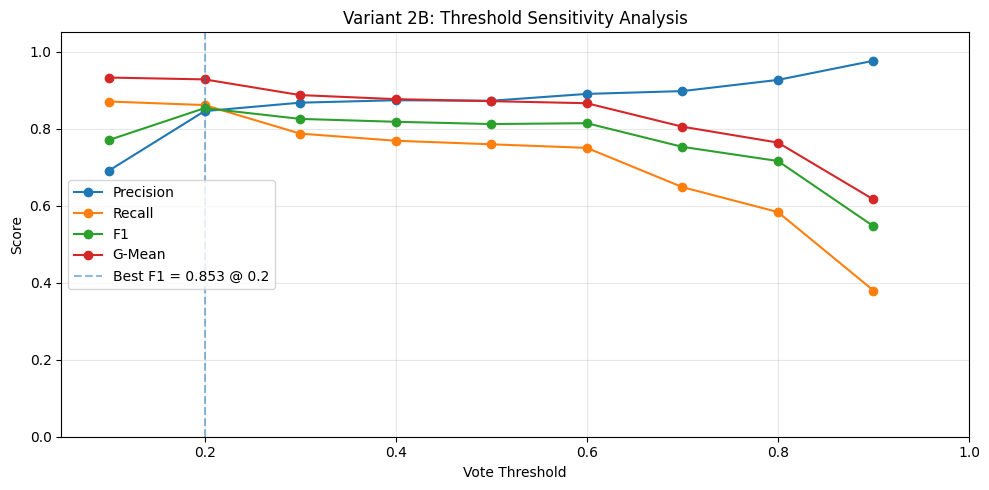


Threshold sweep summary:
  Best F1 threshold:     0.2 -> F1=0.8532
  Best G-Mean threshold: 0.1 -> G-Mean=0.9326

Note: Cross-variant comparison uses threshold=0.5 for fairness.
      AUC and AUPRC are always threshold-independent.


In [0]:

thresh_vals_v2b = [r["threshold"]  for r in threshold_results_v2b]
prec_vals_v2b = [r["precision"]  for r in threshold_results_v2b]
rec_vals_v2b = [r["recall"]     for r in threshold_results_v2b]
f1_vals_v2b  = [r["f1"]        for r in threshold_results_v2b]
gm_vals_v2b = [r["g_mean"]    for r in threshold_results_v2b]

plt.figure(figsize=(10, 5))

plt.plot(thresh_vals_v2b, prec_vals_v2b, marker="o", label="Precision")
plt.plot(thresh_vals_v2b, rec_vals_v2b,  marker="o", label="Recall")
plt.plot(thresh_vals_v2b, f1_vals_v2b,   marker="o", label="F1")
plt.plot(thresh_vals_v2b, gm_vals_v2b,   marker="o", label="G-Mean")

# Mark best F1 threshold
plt.axvline(
    x=best_f1_v2b["threshold"],
    linestyle="--",
    alpha=0.5,
    label=f"Best F1 = {best_f1_v2b['f1']:.3f} @ {best_f1_v2b['threshold']:.1f}"
)

plt.xlabel("Vote Threshold")
plt.ylabel("Score")
plt.title("Variant 2B: Threshold Sensitivity Analysis")
plt.legend(loc="center left")
plt.grid(True, alpha=0.3)
plt.xlim(0.05, 1.0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"\nThreshold sweep summary:")
print(f"  Best F1 threshold:     {best_f1_v2b['threshold']:.1f} -> F1={best_f1_v2b['f1']:.4f}")
print(f"  Best G-Mean threshold: {best_gm_v2b['threshold']:.1f} -> G-Mean={best_gm_v2b['g_mean']:.4f}")
print(f"\nNote: Cross-variant comparison uses threshold=0.5 for fairness.")
print(f"      AUC and AUPRC are always threshold-independent.")

#### Save Final Results

In [0]:
# DRIVER — save Variant 2B summary results
# Threshold 0.5 used — fair comparison across all variants

variant2B_summary = [{
    "variant": "Variant 2 - Stratified Repartition Option B",
    "threshold": 0.5,
    "auc_roc":  float(auc_v2b),
    "auprc": float(auprc_v2b),
    "precision":float(precision_v2b),
    "recall":  float(recall_v2b),
    "f1": float(f1_v2b),
    "specificity": float(specificity_v2b),
    "gmean":   float(gmean_v2b),
    "training_time_sec": float(training_time_v2b),
    "num_trees": int(T_v2b * 8),
    "num_partitions":  int(8)
}]

variant2B_summary_df = spark.createDataFrame(pd.DataFrame(variant2B_summary))
display(variant2B_summary_df)

variant,threshold,auc_roc,auprc,precision,recall,f1,specificity,gmean,training_time_sec,num_trees,num_partitions
Variant 2 - Stratified Repartition Option B,0.5,0.9659070624510986,0.8317937526060957,0.8723404255319149,0.7592592592592593,0.8118811881188118,0.9997889219186997,0.8712628743792572,28.59,80,8


####Save to Parquet

In [0]:
# Save threshold sweep and summary to shared storage
# Other variants can load these for cross-variant comparison

threshold_results_df_v2b = spark.createDataFrame(pd.DataFrame(threshold_results_v2b))

threshold_results_df_v2b.write.mode("overwrite").parquet("/mnt/2026-group7/results/variant2_threshold_sweep_B.parquet")
variant2B_summary_df.write.mode("overwrite").parquet("/mnt/2026-group7/results/variant2_summary_B.parquet")

print("Results saved:")
print("  /mnt/2026-group7/results/variant2_threshold_sweep_B.parquet")
print("  /mnt/2026-group7/results/variant2_summary_B.parquet")

Results saved:
  /mnt/2026-group7/results/variant2_threshold_sweep_B.parquet
  /mnt/2026-group7/results/variant2_summary_B.parquet



## Section 6 — Variant 3: Global Minority Broadcast SMOTEBagging


**Approach:** Minority class is collected to the driver and broadcast to all workers. Majority class stays distributed across partitions. SMOTE uses the full global minority set for neighbour search (vs local-only in V1/V2). Avoids minority data starvation in small partitions.



In [0]:
# Variant 3
# Load fresh preprocessed data — clean slate
train_final, test_final = load_preprocessed()

# Variant 3 aliases 
train_assembled_v3 = train_final
test_assembled_v3 = test_final

Loaded train: 227848 rows | test: 56959 rows


In [0]:
# Check class distribution per Spark partition BEFORE global minority broadcast
from pyspark.sql import functions as F

train_partition_distribution_v3 = (
    train_assembled_v3
    .withColumn("part_id", spark_partition_id())
    .groupBy("part_id")
    .agg(
        F.sum(F.when(col("label") == 0, 1).otherwise(0)).alias("majority_count"),
        F.sum(F.when(col("label") == 1, 1).otherwise(0)).alias("minority_count")
    )
    .orderBy("part_id")
)

print("Class distribution per partition BEFORE global approach:")
train_partition_distribution_v3.show(truncate=False)

Class distribution per partition BEFORE global approach:
+-------+--------------+--------------+
|part_id|majority_count|minority_count|
+-------+--------------+--------------+
|0      |19628         |0             |
|1      |19592         |0             |
|2      |19572         |0             |
|3      |19561         |0             |
|4      |19502         |0             |
|5      |19494         |0             |
|6      |19480         |0             |
|7      |19440         |0             |
|8      |19430         |0             |
|9      |19382         |0             |
|10     |19345         |0             |
|11     |13038         |0             |
|12     |0             |136           |
|13     |0             |67            |
|14     |0             |48            |
|15     |0             |43            |
|16     |0             |29            |
|17     |0             |27            |
|18     |0             |25            |
|19     |0             |9             |
+-------+--------------

#### Global - Distriubuted Design for SMOTE Bagging
The big idea is:

- majority class stays distributed in Spark
- minority class is copied once to every worker using broadcast
- later, each worker can build bags using:
  - its local majority rows
  - the full training minority pool

In [0]:
#Separate training majority/minority and broadcast the training minority set
#Split the training set into minority and majority
train_minority_df_v3 = train_assembled_v3.filter(F.col("label") == 1)
train_majority_df_v3 = train_assembled_v3.filter(F.col("label") == 0)

#Count how many rows are in each class
n_minority_train_v3 = train_minority_df_v3.count()
n_majority_train_v3 = train_majority_df_v3.count()

#Print summary stats
print(f"Training minority (fraud) samples: {n_minority_train_v3}")
print(f"Training majority (legit) samples: {n_majority_train_v3}")
print(f"Imbalance ratio in training set:   1:{n_majority_train_v3 // n_minority_train_v3}")

Training minority (fraud) samples: 384
Training majority (legit) samples: 227464
Imbalance ratio in training set:   1:592


### Collect only minority features to the driver

In [0]:
#Take only the features column from the minority DataFrame
#bring all those rows from Spark workers back to the driver program
#Because we want every worker to have access to the full minority pool for neighbour search.
minority_rows_v3 = train_minority_df_v3.select("features").collect()

#Convert collected Spark vectors into a NumPy matrix
minority_features_np_v3 = np.array([row.features.toArray() for row in minority_rows_v3], dtype=np.float64)

#Print shape and broadcast size
print(f"\nMinority features shape: {minority_features_np_v3.shape}")
print(f"Broadcast size: {minority_features_np_v3.nbytes / 1024:.1f} KB")


Minority features shape: (384, 29)
Broadcast size: 87.0 KB


### Broadcast the minority matrix to all workers

In [0]:
#Take the NumPy minority matrix on the driver
#Send a read-only copy to all Spark workers
broadcast_minority_v3 = spark.sparkContext.broadcast(minority_features_np_v3)
#Print confirmation
print(f"Broadcast complete. All workers now have {minority_features_np_v3.shape[0]} training minority samples.")

Broadcast complete. All workers now have 384 training minority samples.


### Repartition the majority DataFrame

In [0]:
# This controls how many partitions the majority data is spread across.
# Each partition will later do its own bootstrap + SMOTE independently.

#Redistribute the majority rows across 8 Spark partitions
#Keep them as a Spark DataFrame
#Caches them in memory for faster reuse

NUM_PARTITIONS_v3 = 8
train_majority_df_v3 = (
    train_majority_df_v3
      .repartition(NUM_PARTITIONS_v3)
      .cache()
)
#Materialize the cache
_ = train_majority_df_v3.count()

print(f"\nMajority repartitioned into {NUM_PARTITIONS_v3} partitions")

#Check how many majority rows ended up in each partition
partition_counts_v3 = (
    train_majority_df_v3
    .withColumn("partition_id", F.spark_partition_id())
    .groupBy("partition_id")
    .count()
    .orderBy("partition_id")
)
print("\nMajority samples per partition:")
partition_counts_v3.show()


Majority repartitioned into 8 partitions

Majority samples per partition:
+------------+-----+
|partition_id|count|
+------------+-----+
|           0|28434|
|           1|28434|
|           2|28436|
|           3|28433|
|           4|28430|
|           5|28432|
|           6|28433|
|           7|28432|
+------------+-----+



In [0]:
#Final summary printout
print(f"{'='*50}")
print("Variant 3 data setup complete:")
print(f"Minority: {n_minority_train_v3} samples -> broadcast ({minority_features_np_v3.nbytes/1024:.1f} KB)")
print(f"Majority: {n_majority_train_v3} samples -> distributed across {NUM_PARTITIONS_v3} partitions")
print(f"Features: {minority_features_np_v3.shape[1]} per sample")
print("Data movement: only training minority collected to driver")
print(f"{'='*50}")

Variant 3 data setup complete:
Minority: 384 samples -> broadcast (87.0 KB)
Majority: 227464 samples -> distributed across 8 partitions
Features: 29 per sample
Data movement: only training minority collected to driver


### SMOTE Implementation

This section implements the custom SMOTE logic for Variant 3.

Key idea:

neighbour search uses the full broadcast minority set
the minority side of each bag is built to match the local majority bag size
the oversampling rate controls how much of the minority bag is resampled real minority vs synthetic minority

In [0]:
def smote_global(minority_np, k, n_synthetic, seed=42):
    """
    Generate synthetic minority samples using SMOTE with global neighbours.
    Parameters
    minority_np : np.ndarray, shape (n_minority, n_features)
        Full broadcast minority feature matrix.
    k : int
        Number of nearest neighbours.
    n_synthetic : int
        Number of synthetic samples to generate.
    seed : int
        Random seed for reproducibility.

    Returns
    np.ndarray, shape (n_synthetic, n_features)
        Synthetic minority samples.
    """
    #Convert input to NumPy float array
    minority_np = np.asarray(minority_np, dtype=np.float64)

    n_minority, n_features = minority_np.shape

    if n_synthetic <= 0 or n_minority == 0:
        return np.empty((0, n_features), dtype=np.float64)

    if n_minority == 1:
        return np.repeat(minority_np, repeats=n_synthetic, axis=0)

    effective_k = min(k, n_minority - 1)
    
    #Create random generator
    rng = np.random.RandomState(seed)

    # Pairwise squared Euclidean distance matrix
    # ||x-y||^2 = ||x||^2 + ||y||^2 - 2*x·y
    X_sq = np.sum(minority_np ** 2, axis=1, keepdims=True) #Computes squared length of each row vector
    cross = minority_np @ minority_np.T #pairwise dot products
    dist_sq = np.clip(X_sq + X_sq.T - 2 * cross, 0.0, None)

    # Exclude self-neighbour
    np.fill_diagonal(dist_sq, np.inf)

    # k nearest neighbours for each minority point
    knn_indices = np.argsort(dist_sq, axis=1)[:, :effective_k]
    #Create output array
    synthetic = np.zeros((n_synthetic, n_features), dtype=np.float64)

    for i in range(n_synthetic):
        # Pick random seed
        seed_idx = rng.randint(0, n_minority)
        seed_sample = minority_np[seed_idx]

        # Pick one random neighbour from k nearest neighbours
        nn_choice = rng.randint(0, effective_k)
        neighbour_idx = knn_indices[seed_idx, nn_choice]
        neighbour_sample = minority_np[neighbour_idx]

        # Interpolate
        lam = rng.random()  #lam is a random number between 0 and 1.
        synthetic[i] = seed_sample + lam * (neighbour_sample - seed_sample)

    return synthetic


def build_minority_bag(minority_np, oversample_rate, n_majority_in_bag, k=5, seed=42):
    """
    Build the minority side of one bag using the team's chosen balanced-bag schedule.
    Total minority samples in the bag = n_majority_in_bag
    Of those:
      - oversample_rate fraction are resampled real minority samples
      - the remaining fraction are SMOTE-generated synthetic samples

    Parameters
    minority_np : np.ndarray
        Full broadcast minority matrix.
    oversample_rate : float
        Rate for this bag (0.1, 0.2, ..., 1.0).
    n_majority_in_bag : int
        Number of majority samples in this bag.
    k : int
        Number of nearest neighbours for SMOTE.
    seed : int
        Random seed.

    Returns
    np.ndarray
        Minority bag matrix of shape (n_majority_in_bag, n_features).
    """
    #Convert input and create RNG
    minority_np = np.asarray(minority_np, dtype=np.float64)
    rng = np.random.RandomState(seed)

    n_minority, n_features = minority_np.shape

    if n_majority_in_bag <= 0:
        return np.empty((0, n_features), dtype=np.float64)

    #Decide how many real vs synthetic minority samples to create
    n_resampled = min(int(oversample_rate * n_majority_in_bag), n_majority_in_bag)
    n_synthetic = n_majority_in_bag - n_resampled

    # Resample real minority with replacement
    if n_resampled > 0:
        resample_idx = rng.randint(0, n_minority, size=n_resampled) #number of real minority samples to resample
        minority_resampled = minority_np[resample_idx] #number of synthetic SMOTE samples
    else:
        minority_resampled = np.empty((0, n_features), dtype=np.float64)

    # Generate synthetic minority using global neighbour search
    if n_synthetic > 0:
        minority_synthetic = smote_global(
            minority_np=minority_np,
            k=k,
            n_synthetic=n_synthetic,
            seed=seed
        )
    else:
        minority_synthetic = np.empty((0, n_features), dtype=np.float64)
    
    #Combine both parts
    minority_bag = np.vstack([minority_resampled, minority_synthetic])

    # Safety check
    if minority_bag.shape[0] != n_majority_in_bag:
        raise ValueError(
            f"Minority bag size mismatch: expected {n_majority_in_bag}, got {minority_bag.shape[0]}"
        )

    return minority_bag

### SMOTE VALIDATION

In [0]:
# Test 1: Basic SMOTE generation
test_syn_v3 = smote_global(
    minority_np=minority_features_np_v3,
    k=5,
    n_synthetic=10,
    seed=99
)

print(f"Generated {test_syn_v3.shape[0]} synthetic samples")
print(f"Shape: {test_syn_v3.shape}")
print(f"First synthetic sample (first 5 features): {test_syn_v3[0][:5]}")
print(f"First real sample (first 5 features):      {minority_features_np_v3[0][:5]}")

# Test 2: Build minority bag at all 10 rates
print(f"\n{'Bag':<5} {'Rate':<6} {'Resampled':<11} {'Synthetic':<11} {'Total':<8}")
print("-" * 45)

for bag in range(1, 11):
    rate = bag * 0.1
    bag_result_v3 = build_minority_bag(
        minority_np=minority_features_np_v3,
        oversample_rate=rate,
        n_majority_in_bag=100,
        k=5,
        seed=bag
    )

    n_resamp = min(int(rate * 100), 100)
    n_synth = 100 - n_resamp

    print(f"{bag:<5} {rate:<6.1f} {n_resamp:<11} {n_synth:<11} {bag_result_v3.shape[0]:<8}")

print("\nSMOTE functions validated successfully.")

# Test 3: Verify synthetic samples are interpolations
print("\nTest 3: Synthetic sample quality check")
real_min_v3 = minority_features_np_v3.min(axis=0)
real_max_v3 = minority_features_np_v3.max(axis=0)

test_large_v3 = smote_global(minority_features_np_v3, k=5, n_synthetic=100, seed=123)
within_bounds_v3 = np.mean(
    (test_large_v3 >= real_min_v3) & (test_large_v3 <= real_max_v3)
) * 100

print(f"Features within real minority bounds: {within_bounds_v3:.1f}%")

# Test 4: Check for NaN or infinite values
print("\nTest 4: NaN / Inf check")

has_nan_v3 = np.isnan(test_large_v3).any()
has_inf_v3 = np.isinf(test_large_v3).any()

print(f"Contains NaN: {has_nan_v3}")
print(f"Contains Inf: {has_inf_v3}")

Generated 10 synthetic samples
Shape: (10, 29)
First synthetic sample (first 5 features): [-3.86124968  3.51183936 -4.00816418  3.87007672 -2.1864512 ]
First real sample (first 5 features):      [-28.70922925  22.05772899 -27.85581113  11.84501291 -18.98381258]

Bag   Rate   Resampled   Synthetic   Total   
---------------------------------------------
1     0.1    10          90          100     
2     0.2    20          80          100     
3     0.3    30          70          100     
4     0.4    40          60          100     
5     0.5    50          50          100     
6     0.6    60          40          100     
7     0.7    70          30          100     
8     0.8    80          20          100     
9     0.9    90          10          100     
10    1.0    100         0           100     

SMOTE functions validated successfully.

Test 3: Synthetic sample quality check
Features within real minority bounds: 100.0%

Test 4: NaN / Inf check
Contains NaN: False
Contains Inf: 

### SMOTEBAGGING LOOP VIA mapPartitionsWithIndex

**Variant 3 architecture:**
- Majority stays local in Spark partitions
- Minority is broadcast globally to all workers
- Each partition runs T bags independently
- Total trees = NUM_PARTITIONS × T

**Data movement:**

- TO workers: broadcast minority + broadcast test features
- FROM workers: prediction lists only
- Majority data never leaves worker partitions

In [0]:
# Configuration
T_v3 = 10
K_v3 = 5
MAX_DEPTH_v3 = 10

print(f"Configuration: T={T_v3} bags, K={K_v3} neighbours, {NUM_PARTITIONS_v3} partitions")
print(f"Total trees: {T_v3} × {NUM_PARTITIONS_v3} = {T_v3 * NUM_PARTITIONS_v3}")

Configuration: T=10 bags, K=5 neighbours, 8 partitions
Total trees: 10 × 8 = 80


In [0]:
# Broadcast test set once
test_collected_v3 = test_assembled_v3.select("features", "label").collect()

test_features_list_v3 = [row["features"].toArray().tolist() for row in test_collected_v3]
test_labels_v3 = np.array([int(row["label"]) for row in test_collected_v3], dtype=np.int32)

test_features_bc_v3 = spark.sparkContext.broadcast(test_features_list_v3)
T_bc_v3 = spark.sparkContext.broadcast(T_v3)
K_bc_v3 = spark.sparkContext.broadcast(K_v3)

print(f"Test samples broadcast: {len(test_collected_v3)}")
print(f"Approx test broadcast size: ~{len(test_features_list_v3) * 29 * 8 / (1024*1024):.1f} MB")

Test samples broadcast: 56959
Approx test broadcast size: ~12.6 MB


In [0]:
# Worker function
def process_partition_variant3(partition_id, rows):
    import numpy as np
    from sklearn.tree import DecisionTreeClassifier

    rows_list = list(rows)
    if len(rows_list) == 0:
        return iter([])

    # Local majority rows in this partition
    local_majority_v3 = np.array(
        [row["features"].toArray() for row in rows_list],
        dtype=np.float64
    )
    n_local_majority_v3 = local_majority_v3.shape[0]

    # Broadcast values
    global_minority_v3 = np.array(broadcast_minority_v3.value, dtype=np.float64)
    test_X_v3 = np.array(test_features_bc_v3.value, dtype=np.float64)
    T_local_v3 = T_bc_v3.value
    K_local_v3 = K_bc_v3.value

    n_minority_v3, n_features_v3 = global_minority_v3.shape

    # Precompute k-NN once per worker
    eff_k_v3 = min(K_local_v3, n_minority_v3 - 1)

    X_sq_v3 = np.sum(global_minority_v3 ** 2, axis=1, keepdims=True)
    cross_v3 = global_minority_v3 @ global_minority_v3.T
    dist_sq_v3 = np.clip(X_sq_v3 + X_sq_v3.T - 2 * cross_v3, 0.0, None)
    np.fill_diagonal(dist_sq_v3, np.inf)

    knn_indices_v3 = np.argsort(dist_sq_v3, axis=1)[:, :eff_k_v3]

    # Local SMOTE helper using precomputed neighbours
    def smote_worker_v3(minority_np, knn_indices, n_synthetic, seed):
        n_min, n_feat = minority_np.shape

        if n_synthetic <= 0 or n_min == 0:
            return np.empty((0, n_feat), dtype=np.float64)

        if n_min == 1:
            return np.repeat(minority_np, repeats=n_synthetic, axis=0)

        rng = np.random.RandomState(seed)
        synthetic = np.zeros((n_synthetic, n_feat), dtype=np.float64)

        for i in range(n_synthetic):
            seed_idx = rng.randint(0, n_min)
            nn_choice = rng.randint(0, knn_indices.shape[1])
            neighbour_idx = knn_indices[seed_idx, nn_choice]
            lam = rng.random()

            synthetic[i] = (
                minority_np[seed_idx]
                + lam * (minority_np[neighbour_idx] - minority_np[seed_idx])
            )

        return synthetic

    results_v3 = []

    # Run T bags in this partition
    for bag in range(1, T_local_v3 + 1):
        oversample_rate_v3 = bag * 0.1
        bag_seed_v3 = partition_id * 1000 + bag
        rng_v3 = np.random.RandomState(bag_seed_v3)

        # Step 1: bootstrap local majority with replacement
        bootstrap_idx_v3 = rng_v3.randint(0, n_local_majority_v3, size=n_local_majority_v3)
        majority_bootstrap_v3 = local_majority_v3[bootstrap_idx_v3]
        n_maj_in_bag_v3 = majority_bootstrap_v3.shape[0]

        # Step 2: build minority side
        n_resampled_v3 = min(int(oversample_rate_v3 * n_maj_in_bag_v3), n_maj_in_bag_v3)
        n_synthetic_v3 = n_maj_in_bag_v3 - n_resampled_v3

        if n_resampled_v3 > 0:
            resample_idx_v3 = rng_v3.randint(0, n_minority_v3, size=n_resampled_v3)
            minority_resampled_v3 = global_minority_v3[resample_idx_v3]
        else:
            minority_resampled_v3 = np.empty((0, n_features_v3), dtype=np.float64)

        if n_synthetic_v3 > 0:
            minority_synthetic_v3 = smote_worker_v3(
                global_minority_v3,
                knn_indices_v3,
                n_synthetic_v3,
                seed=bag_seed_v3 + 500
            )
        else:
            minority_synthetic_v3 = np.empty((0, n_features_v3), dtype=np.float64)

        # Step 3: combine into balanced training bag
        X_train_v3 = np.vstack([majority_bootstrap_v3, minority_resampled_v3, minority_synthetic_v3])
        y_train_v3 = np.concatenate([
            np.zeros(n_maj_in_bag_v3, dtype=np.int32),
            np.ones(len(minority_resampled_v3), dtype=np.int32),
            np.ones(len(minority_synthetic_v3), dtype=np.int32)
        ])

        # Step 4: train local tree
        dt_v3 = DecisionTreeClassifier(max_depth=MAX_DEPTH_v3, random_state=bag_seed_v3)
        dt_v3.fit(X_train_v3, y_train_v3)

        # Step 5: predict on full broadcast test set
        bag_preds_v3 = dt_v3.predict(test_X_v3).astype(int).tolist()

        results_v3.append((partition_id, bag, bag_preds_v3))

    return iter(results_v3)

In [0]:
# Run the distributed training loop
print("Running Variant 3: Global Minority-Aware SMOTEBagging")
print(f"  {NUM_PARTITIONS_v3} partitions × {T_v3} bags = {T_v3 * NUM_PARTITIONS_v3} trees")
start_time_v3 = time.time()

all_predictions_v3 = (
    train_majority_df_v3.rdd
    .mapPartitionsWithIndex(process_partition_variant3)
    .collect()
)

end_time_v3 = time.time()
total_time_v3 = round(end_time_v3 - start_time_v3, 2)

Running Variant 3: Global Minority-Aware SMOTEBagging
  8 partitions × 10 bags = 80 trees


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:136)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecutio

In [0]:
# Summary
print(f"\nTotal training + prediction time: {total_time_v3} seconds")
print(f"Trees collected: {len(all_predictions_v3)}")
print(f"Expected: {T_v3 * NUM_PARTITIONS_v3}")

if len(all_predictions_v3) > 0:
    print(f"Predictions per tree: {len(all_predictions_v3[0][2])}")
    print(f"Predictions matrix: {len(all_predictions_v3)} trees × {len(all_predictions_v3[0][2])} test samples")
    print(f"First result tuple: partition={all_predictions_v3[0][0]}, bag={all_predictions_v3[0][1]}")
else:
    print("No predictions were returned.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

### MAJORITY VOTE + EVALUATION

In [0]:
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

# Sort prediction tuples for clean, deterministic ordering
all_predictions_sorted_v3 = sorted(all_predictions_v3, key=lambda x: (x[0], x[1]))

# Extract only the prediction lists
prediction_lists_v3 = [preds for (_, _, preds) in all_predictions_sorted_v3]

# Convert to matrix: shape = (num_trees, num_test_samples)
predictions_matrix_v3 = np.array(prediction_lists_v3, dtype=np.int32)

print(f"Predictions matrix shape: {predictions_matrix_v3.shape}")

# Safety check
expected_trees_v3 = NUM_PARTITIONS_v3 * T_v3
if predictions_matrix_v3.shape[0] != expected_trees_v3:
    raise ValueError(
        f"Expected {expected_trees_v3} trees, got {predictions_matrix_v3.shape[0]}"
    )

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# Majority vote
vote_sums_v3 = predictions_matrix_v3.sum(axis=0)
vote_scores_v3 = vote_sums_v3 / predictions_matrix_v3.shape[0]
final_preds_v3 = (vote_scores_v3 > 0.5).astype(int)

y_true_v3 = test_labels_v3
y_pred_v3 = final_preds_v3
y_score_v3 = vote_scores_v3

print(f"Final predictions shape: {y_pred_v3.shape}")
print(f"Predicted fraud cases: {y_pred_v3.sum()}")
print(f"Actual fraud cases:{y_true_v3.sum()}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# Confusion matrix
tn_v3, fp_v3, fn_v3, tp_v3 = confusion_matrix(y_true_v3, y_pred_v3).ravel()

print("\nConfusion Matrix:")
print(f"True Negatives  (TN): {tn_v3}")
print(f"False Positives (FP): {fp_v3}")
print(f"False Negatives (FN): {fn_v3}")
print(f"True Positives  (TP): {tp_v3}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# Metrics
# AUC and AUPRC must use scores, not hard labels
precision_v3 = tp_v3 / (tp_v3 + fp_v3) if (tp_v3 + fp_v3) > 0 else 0.0
recall_v3 = tp_v3 / (tp_v3 + fn_v3) if (tp_v3 + fn_v3) > 0 else 0.0
specificity_v3 = tn_v3 / (tn_v3 + fp_v3) if (tn_v3 + fp_v3) > 0 else 0.0
f1_v3 = f1_score(y_true_v3, y_pred_v3)
auc_v3 = roc_auc_score(y_true_v3, y_score_v3)
auprc_v3 = average_precision_score(y_true_v3, y_score_v3)
gmean_v3 = np.sqrt(recall_v3 * specificity_v3)

print("\nEvaluation Metrics:")
print(f"auc_roc: {auc_v3:.4f}")
print(f"AUPRC: {auprc_v3:.4f}")
print(f"F1 Score: {f1_v3:.4f}")
print(f"G-mean: {gmean_v3:.4f}")
print(f"Precision: {precision_v3:.4f}")
print(f"Recall: {recall_v3:.4f}")
print(f"Specificity: {specificity_v3:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_v3, y_pred_v3, digits=4))

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# VARIANT 3 — SAVE SUMMARY FOR CROSS-VARIANT COMPARISON
v3_summary = {
    "variant": "Variant 3 - Global Minority Broadcast",
    "auc_roc":auc_v3,
    "auprc":auprc_v3,
    "f1":f1_v3,
    "gmean":gmean_v3,
    "precision": precision_v3,
    "recall":recall_v3,
    "threshold": 0.5,
}
print("Variant 3 summary:", v3_summary)

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# Per-partition diagnostics
print("Trees per partition:")
for pid in sorted(set(p for p, _, _ in all_predictions_sorted_v3)):
    pid_preds_v3 = [preds for p, b, preds in all_predictions_sorted_v3 if p == pid]
    pid_matrix_v3 = np.array(pid_preds_v3, dtype=np.int32)

    fraud_counts_v3 = pid_matrix_v3.sum(axis=1)

    print(
        f"  Partition {pid}: {len(pid_preds_v3)} trees, "
        f"avg fraud preds per tree: {fraud_counts_v3.mean():.1f}, "
        f"min: {fraud_counts_v3.min()}, max: {fraud_counts_v3.max()}"
    )

# Cost and timing summary
minority_broadcast_kb_v3 = broadcast_minority_v3.value.nbytes / 1024
test_broadcast_mb_v3 = np.array(test_features_list_v3, dtype=np.float64).nbytes / (1024 * 1024)

print(f"\n{'='*55}")
print("VARIANT 3 — RESULTS SUMMARY")
print(f"{'='*55}")
print(f"Partitions: {NUM_PARTITIONS_v3}")
print(f"Bags per partition: {T_v3}")
print(f"Total trees: {predictions_matrix_v3.shape[0]}")
print(f"Minority broadcast: {minority_broadcast_kb_v3:.1f} KB ({n_minority_train_v3} samples)")
print(f"Test broadcast: {test_broadcast_mb_v3:.1f} MB ({len(test_labels_v3)} samples)")
print(f"Majority data: Stayed local (never left workers)")
print(f"Training time: {total_time_v3} seconds")
print(f"AUC-ROC: {auc_v3:.4f}")
print(f"AUPRC: {auprc_v3:.4f}")
print(f"F1: {f1_v3:.4f}")
print(f"G-Mean: {gmean_v3:.4f}")
print(f"Precision: {precision_v3:.4f}")
print(f"Recall: {recall_v3:.4f}")
print(f"Specificity: {specificity_v3:.4f}")
print(f"{'='*55}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

### THRESHOLD SENSITIVITY ANALYSIS

In this section, we vary the ensemble vote threshold to study the precision–recall trade-off.

This uses the same 80 trained trees and the same vote scores.

We report:
- TP, FP, FN, TN
- Precision
- Recall
- F1
- G-Mean
- Specificity

We also visualise how these metrics change as the vote threshold increases.

In [0]:
# THRESHOLD SENSITIVITY ANALYSIS
thresholds_v3 = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results_v3 = []

print(f"{'Thresh':<8} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<8} "
      f"{'Prec':<8} {'Recall':<8} {'F1':<8} {'G-Mean':<8} {'Spec':<8}")
print("-" * 80)

for thresh in thresholds_v3:
    preds_t_v3 = (vote_scores_v3 > thresh).astype(int)

    tp_t = int(np.sum((y_true_v3 == 1) & (preds_t_v3 == 1)))
    fp_t = int(np.sum((y_true_v3 == 0) & (preds_t_v3 == 1)))
    fn_t = int(np.sum((y_true_v3 == 1) & (preds_t_v3 == 0)))
    tn_t = int(np.sum((y_true_v3 == 0) & (preds_t_v3 == 0)))

    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    rec_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    spec_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0.0
    f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t) if (prec_t + rec_t) > 0 else 0.0
    gm_t   = np.sqrt(rec_t * spec_t)

    print(f"{thresh:<8.1f} {tp_t:<6} {fp_t:<6} {fn_t:<6} {tn_t:<8} "
          f"{prec_t:<8.4f} {rec_t:<8.4f} {f1_t:<8.4f} {gm_t:<8.4f} {spec_t:<8.4f}")

    threshold_results_v3.append({
        "threshold": float(thresh),
        "tp": tp_t,
        "fp": fp_t,
        "fn": fn_t,
        "tn": tn_t,
        "precision": prec_t,
        "recall": rec_t,
        "f1": f1_t,
        "g_mean": gm_t,
        "specificity": spec_t
    })

print(f"\nAUC-ROC (threshold-independent): {auc_v3:.4f}")
print(f"AUPRC (threshold-independent):   {auprc_v3:.4f}")

best_f1_v3 = max(threshold_results_v3, key=lambda r: r["f1"])
best_gm_v3 = max(threshold_results_v3, key=lambda r: r["g_mean"])

print(f"\nBest F1 threshold: {best_f1_v3['threshold']:.1f} "
      f"-> F1={best_f1_v3['f1']:.4f}, "
      f"Precision={best_f1_v3['precision']:.4f}, "
      f"Recall={best_f1_v3['recall']:.4f}")

print(f"Best G-Mean threshold: {best_gm_v3['threshold']:.1f} "
      f"-> G-Mean={best_gm_v3['g_mean']:.4f}, "
      f"Precision={best_gm_v3['precision']:.4f}, "
      f"Recall={best_gm_v3['recall']:.4f}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# Threshold Plot
import matplotlib.pyplot as plt

# Recompute best point safely
best_f1_v3 = max(threshold_results_v3, key=lambda r: r["f1"])

thresh_vals_v3 = [r["threshold"] for r in threshold_results_v3]
prec_vals_v3   = [r["precision"] for r in threshold_results_v3]
rec_vals_v3    = [r["recall"] for r in threshold_results_v3]
f1_vals_v3     = [r["f1"] for r in threshold_results_v3]
gm_vals_v3     = [r["g_mean"] for r in threshold_results_v3]

plt.figure(figsize=(10, 5))

plt.plot(thresh_vals_v3, prec_vals_v3, marker="o", label="Precision")
plt.plot(thresh_vals_v3, rec_vals_v3,  marker="o", label="Recall")
plt.plot(thresh_vals_v3, f1_vals_v3,   marker="o", label="F1")
plt.plot(thresh_vals_v3, gm_vals_v3,   marker="o", label="G-Mean")

plt.axvline(
    x=best_f1_v3["threshold"],
    linestyle="--",
    alpha=0.5,
    label=f"Best F1 = {best_f1_v3['f1']:.3f} @ {best_f1_v3['threshold']:.2f}"
)

plt.xlabel("Vote Threshold")
plt.ylabel("Score")
plt.title("Variant 3: Threshold Sensitivity Analysis")
plt.legend(loc="center left")
plt.grid(True, alpha=0.3)
plt.xlim(0.05, 1.0)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# Best-threshold summary
print("\nThreshold sweep summary:")
print(f"Best F1 threshold: {best_f1_v3['threshold']:.1f}")
print(f"Precision = {best_f1_v3['precision']:.4f}")
print(f"Recall= {best_f1_v3['recall']:.4f}")
print(f"F1= {best_f1_v3['f1']:.4f}")
print(f"G-Mean= {best_f1_v3['g_mean']:.4f}")

print(f"\nBest G-Mean threshold: {best_gm_v3['threshold']:.1f}")
print(f"Precision = {best_gm_v3['precision']:.4f}")
print(f"Recall= {best_gm_v3['recall']:.4f}")
print(f"F1= {best_gm_v3['f1']:.4f}")
print(f"G-Mean= {best_gm_v3['g_mean']:.4f}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# Save summary
v3_summary_df = spark.createDataFrame(pd.DataFrame([v3_summary]))
v3_summary_df.write.mode("overwrite").parquet("/mnt/2026-group7/results/v3_summary.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage


## Section 7 - Scalability Experiments
All variants are evaluated under the same experimental conditions for direct comparison.

**Research Questions:**
- **RQ1:** How does training time scale with dataset size (strong scaling)?
- **RQ2:** How does classification performance change with dataset size?
- **RQ3:** How does partition count affect runtime and performance?

**Setup:** Partition values: `[2, 4, 8, 16]` | Dataset fractions: `[0.25, 0.50, 0.75, 1.00]`


### 7.1 Experiment 1 - Partition Sensitivity
Vary number of Spark partitions `[2, 4, 8, 16]` with fixed dataset size (100%).


This experiment studies how each variant behaves as the number of majority partitions changes.

**Purpose**:
- evaluate runtime scalability
- measure speed-up as partition count increases
- check whether predictive performance stays stable

**Fixed settings:**-
- same train/test split
- same SMOTE logic
- same number of bags per partition (`T=10`)
- same tree depth
- same exploratory decision threshold (`0.5`) for threshold-dependent metrics

**Note:**
- AUC-ROC and AUPRC are threshold-independent
- Precision, Recall, F1, Specificity, and G-Mean are reported at threshold `0.5`

##### Approach A - Vary Partitions

- Approach A - vary partitions 2/4/8/16, T=10 fixed per partition
- Note: total trees change (20/40/80/160) - confounded variable
- This is intentional - we identify the confounding in Approach B

In [0]:
PARTITION_VALUES = [2, 4, 8, 16]
T_EXP = 10       # bags per partition are fixed
K_EXP = 5
MAX_DEPTH_EXP = 10
THRESHOLD_EXP = 0.5
 
print("EXPERIMENT 1: PARTITION SENSITIVITY - APPROACH A")
print()
print(f"Partition counts: {PARTITION_VALUES}")
print(f"Bags per partition: {T_EXP} (fixed)")
print(f"Total trees: varies with partition count")
print(f"Fixed settings: K={K_EXP}, max_depth={MAX_DEPTH_EXP}")
print(f"Threshold: {THRESHOLD_EXP}")
print()
 
print(f"\n{'Partitions':<12} {'Bags/Partition':<16} {'Total Trees'}")
print()
for p in PARTITION_VALUES:
    print(f"{p:<12} {T_EXP:<16} {p * T_EXP}")
 
partition_results_a = []   # list of dicts per run

EXPERIMENT 1: PARTITION SENSITIVITY - APPROACH A

Partition counts: [2, 4, 8, 16]
Bags per partition: 10 (fixed)
Total trees: varies with partition count
Fixed settings: K=5, max_depth=10
Threshold: 0.5


Partitions   Bags/Partition   Total Trees

2            10               20
4            10               40
8            10               80
16           10               160


**Runner Function - Approach A**

- Repartitions data and reruns full SMOTEBagging pipeline
- Returns runtime, performance metrics, partition diagnostics
- T bags per partition - total trees = num_partitions * T.

In [0]:

def run_variant1_partition_experiment(num_partitions, T=10, K=5, max_depth=10, threshold=0.5):
    import time
    import numpy as np
    import pandas as pd
    from pyspark.sql.functions import spark_partition_id, col
    from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix

    current_parts = train_final.rdd.getNumPartitions()

    if num_partitions <= current_parts:
        train_repartitioned = train_final.coalesce(num_partitions)
    else:
        train_repartitioned = train_final.repartition(num_partitions)

    train_repartitioned.cache()
    train_repartitioned.count()

    # Step 2 - log minority samples per partition
    part_info = train_repartitioned.withColumn("part_id", spark_partition_id())
    minority_per_partition = (
        part_info.filter(col("label") == 1)
        .groupBy("part_id")
        .count()
        .orderBy("part_id")
        .collect()
    )
    part_minority_counts = [int(r["count"]) for r in minority_per_partition]
    print(f"  Minority per partition: {part_minority_counts}")

    # Step 3 - broadcast scalars fresh for this run
    T_bc_exp     = sc.broadcast(T)
    K_bc_exp     = sc.broadcast(K)
    depth_bc_exp = sc.broadcast(max_depth)

    # Step 4 - worker function
    def process_partition_exp(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier

        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])

        minority = [r for r in rows_list if r["label"] == 1]
        majority = [r for r in rows_list if r["label"] == 0]

        if len(minority) == 0 or len(majority) == 0:
            return iter([])

        t_features  = test_features_exp_bc.value
        T_local     = T_bc_exp.value
        K_local     = K_bc_exp.value
        depth_local = depth_bc_exp.value

        test_X = np.array([f.toArray() for f in t_features])

        samples_array = np.array([
            np.array(r["features"].toArray()) for r in minority
        ])
        n_minority = len(samples_array)

        eff_k = min(K_local, n_minority - 1)

        if eff_k < 1:
            knn_indices = None
        else:
            X_sq    = np.sum(samples_array ** 2, axis=1, keepdims=True)
            cross   = samples_array @ samples_array.T
            dist_sq = np.clip(X_sq + X_sq.T - 2 * cross, 0.0, None)
            np.fill_diagonal(dist_sq, np.inf)
            knn_indices = np.argsort(dist_sq, axis=1)[:, :eff_k]

        def smote_local(samples_array, knn_indices, n_synthetic, rng):
            if len(samples_array) == 0 or n_synthetic <= 0:
                return []
            synthetic_samples = []
            if knn_indices is None:
                for _ in range(n_synthetic):
                    idx = rng.randint(0, len(samples_array))
                    synthetic_samples.append(samples_array[idx].copy())
            else:
                for _ in range(n_synthetic):
                    idx = rng.randint(0, len(samples_array))
                    nn_choice = rng.randint(0, knn_indices.shape[1])
                    neighbour_idx = knn_indices[idx, nn_choice]
                    gap = rng.random()
                    synthetic = samples_array[idx] + gap * (
                        samples_array[neighbour_idx] - samples_array[idx]
                    )
                    synthetic_samples.append(synthetic)
            return synthetic_samples

        results = []

        for bag in range(1, T_local + 1):
            bag_seed = partition_id * 1000 + bag
            rng  = np.random.RandomState(bag_seed)
            oversample_rate = bag * 0.1
            n_synthetic = int(n_minority * oversample_rate)

            bootstrap_majority = [
                majority[rng.randint(0, len(majority))]
                for _ in range(len(majority))
            ]

            synthetic_vectors = smote_local(
                samples_array, knn_indices, n_synthetic, rng
            )

            X_train, y_train = [], []
            for r in bootstrap_majority:
                X_train.append(r["features"].toArray()); y_train.append(0)
            for s_arr in samples_array:
                X_train.append(s_arr); y_train.append(1)
            for s in synthetic_vectors:
                X_train.append(s); y_train.append(1)

            X_train = np.array(X_train)
            y_train = np.array(y_train)

            dt = DecisionTreeClassifier(max_depth=depth_local, random_state=bag_seed)
            dt.fit(X_train, y_train)

            bag_preds = dt.predict(test_X).tolist()
            results.append((partition_id, bag, [int(p) for p in bag_preds]))

        return iter(results)

    # Step 5 - run and time
    start_time = time.time()

    preds_raw = (
        train_repartitioned.rdd
        .mapPartitionsWithIndex(process_partition_exp)
        .collect()
    )

    runtime_sec = round(time.time() - start_time, 2)

    # Cleanup
    train_repartitioned.unpersist()
    T_bc_exp.unpersist()
    K_bc_exp.unpersist()
    depth_bc_exp.unpersist()

    # Step 6 - aggregate predictions and compute metrics

    # FIX: return None INSIDE the if block only, not unconditionally
    if len(preds_raw) == 0:
        print(f"  WARNING: No predictions returned for {num_partitions} partitions — skipping.")
        return None

    # FIX: removed duplicate sorted() call that appeared after the misplaced return
    preds_sorted = sorted(preds_raw, key=lambda x: (x[0], x[1]))
    pred_lists   = [x[2] for x in preds_sorted]
    pred_matrix  = np.array(pred_lists, dtype=np.int32)

    n_trees     = pred_matrix.shape[0]
    vote_sums   = pred_matrix.sum(axis=0)
    vote_scores = vote_sums / n_trees
    y_true      = np.array(test_labels_exp)

    auc_roc = roc_auc_score(y_true, vote_scores)
    auprc   = average_precision_score(y_true, vote_scores)

    preds_final = (vote_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_final).ravel()

    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, preds_final)
    gmean       = np.sqrt(recall * specificity)

    return {
        "num_partitions": int(num_partitions),
        "num_trees": int(n_trees),
        "runtime_sec": float(runtime_sec),
        "auc_roc": float(auc_roc),
        "auprc": float(auprc),
        "f1": float(f1),
        "gmean": float(gmean),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "minority_per_partition_avg": float(np.mean(part_minority_counts)),
        "minority_per_partition_min": int(min(part_minority_counts)),
        "minority_per_partition_max": int(max(part_minority_counts))
    }


# LOOP - run Approach A for all partition counts

print("Approach A runner ready.")

for n_parts in PARTITION_VALUES:
    print(f"\n{'-' * 55}")
    print(f"Running with {n_parts} partitions, {T_EXP} bags each "
          f"({n_parts * T_EXP} trees total)...")
    print(f"{'-' * 55}")

    result = run_variant1_partition_experiment(
        num_partitions=n_parts,
        T=T_EXP,
        K=K_EXP,
        max_depth=MAX_DEPTH_EXP,
        threshold=THRESHOLD_EXP
    )

    if result is None:
        print(f"  Skipped {n_parts} partitions - no valid predictions.")
        continue                      # FIX: continue is now INSIDE the if block

    partition_results_a.append(result)

    print(f"Trees: {result['num_trees']}")
    print(f"Runtime: {result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC:  {result['auc_roc']:.4f}")
    print(f"AUPRC: {result['auprc']:.4f}")
    print(f"F1: {result['f1']:.4f}")
    print(f"G-Mean: {result['gmean']:.4f}")
    print(f"Minority/part: avg={result['minority_per_partition_avg']:.0f}, "
          f"min={result['minority_per_partition_min']}, "
          f"max={result['minority_per_partition_max']}")

# Only create the DataFrame if we have results
if partition_results_a:
    partition_results_a_df = spark.createDataFrame(pd.DataFrame(partition_results_a))
    display(partition_results_a_df.orderBy("num_partitions"))
else:
    print("\nNo results collected — all partition runs were skipped.")
    print("Tip: ensure train_final has both classes present in every partition.")
    print("Consider using stratified repartitioning or reducing PARTITION_VALUES.")

Approach A runner ready.

-------------------------------------------------------
Running with 2 partitions, 10 bags each (20 trees total)...
-------------------------------------------------------
  Minority per partition: [384]
Trees: 10
Runtime: 18.01 sec
AUC-ROC:  0.9322
AUPRC: 0.1928
F1: 0.0799
G-Mean: 0.9104
Minority/part: avg=384, min=384, max=384

-------------------------------------------------------
Running with 4 partitions, 10 bags each (40 trees total)...
-------------------------------------------------------
  Minority per partition: [251, 133]
Trees: 10
Runtime: 24.56 sec
AUC-ROC:  0.9445
AUPRC: 0.1884
F1: 0.1184
G-Mean: 0.8924
Minority/part: avg=192, min=133, max=251

-------------------------------------------------------
Running with 8 partitions, 10 bags each (80 trees total)...
-------------------------------------------------------
  Minority per partition: [251, 72, 61]
  Skipped 8 partitions - no valid predictions.

---------------------------------------------

num_partitions,num_trees,runtime_sec,auc_roc,auprc,f1,gmean,precision,recall,specificity,tp,fp,fn,tn,minority_per_partition_avg,minority_per_partition_min,minority_per_partition_max
2,10,18.01,0.9322366068025776,0.1928461653178431,0.07986260197509662,0.9104277600808824,0.04187303016659163,0.8611111111111112,0.9625688202494239,93,2128,15,54723,384.0,384,384
4,10,24.56,0.944493549414747,0.18842407439296957,0.11843876177658141,0.8923709645849401,0.06386066763425254,0.8148148148148148,0.977309106260224,88,1290,20,55561,192.0,133,251


**Approach A - Results Summary and Plots**


Parts    Trees    Time(s)    AUC      AUPRC    F1       GMean    Min/Part  
2        10       18.01      0.9322   0.1928   0.0799   0.9104   384       
4        10       24.56      0.9445   0.1884   0.1184   0.8924   192       

Speed-up relative to 2 partitions:
  2 partitions: 1.00x
  4 partitions: 0.73x


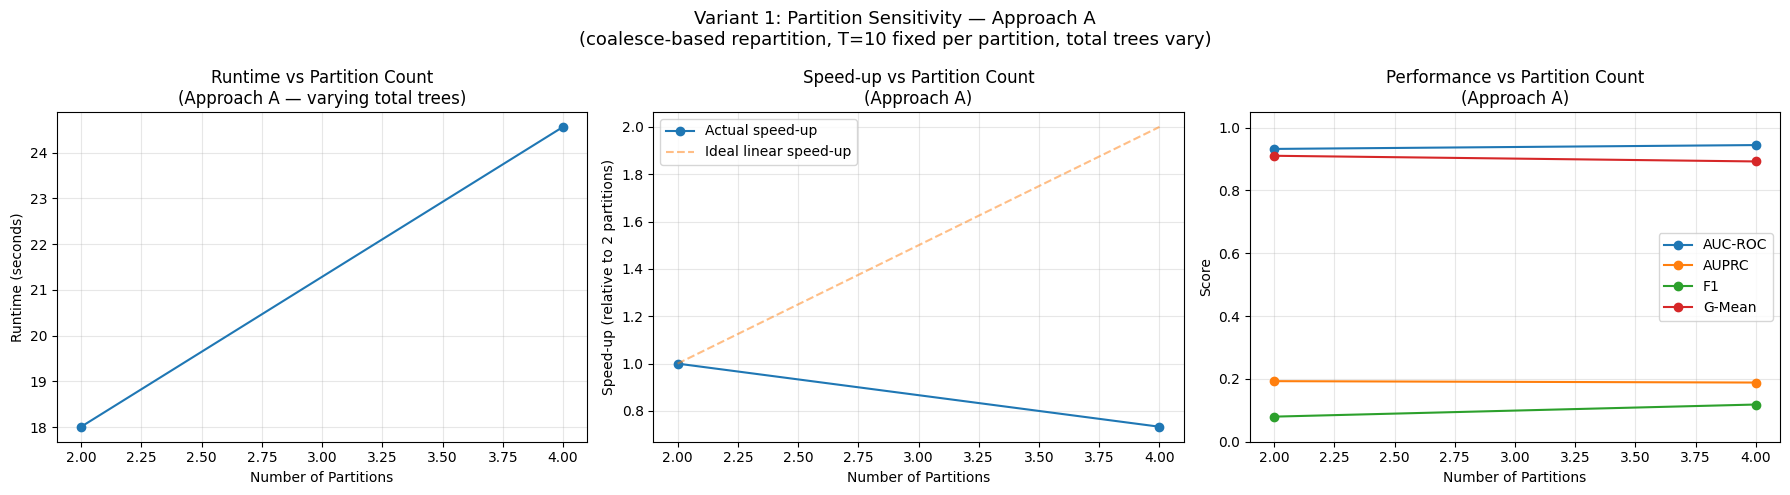


OBSERVATION:
Approach A varies both partition count AND total tree count simultaneously.
Repartitioning uses coalesce() — no shuffle — consistent with Variant 1's
local-first, zero cross-partition movement design.
Performance changes cannot be attributed to partition count alone.
→ Proceed to Approach B to fix total trees at 80.


In [0]:
print(f"\n{'Parts':<8} {'Trees':<8} {'Time(s)':<10} {'AUC':<8} "
      f"{'AUPRC':<8} {'F1':<8} {'GMean':<8} {'Min/Part':<10}")
print("=" * 75)
 
for r in partition_results_a:
    print(f"{r['num_partitions']:<8} {r['num_trees']:<8} "
          f"{r['runtime_sec']:<10.2f} {r['auc_roc']:<8.4f} "
          f"{r['auprc']:<8.4f} {r['f1']:<8.4f} "
          f"{r['gmean']:<8.4f} {r['minority_per_partition_avg']:<10.0f}")
 
baseline_rt = partition_results_a[0]["runtime_sec"]
print(f"\nSpeed-up relative to 2 partitions:")
for r in partition_results_a:
    speedup = baseline_rt / r["runtime_sec"] if r["runtime_sec"] > 0 else 0
    print(f"  {r['num_partitions']} partitions: {speedup:.2f}x")
 
# Plots
import matplotlib.pyplot as plt
 
pdf_a = pd.DataFrame(partition_results_a).sort_values("num_partitions")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Variant 1: Partition Sensitivity — Approach A\n"
    "(coalesce-based repartition, T=10 fixed per partition, total trees vary)",
    fontsize=13
)
 
# Plot 1 — Runtime vs partitions
axes[0].plot(pdf_a["num_partitions"], pdf_a["runtime_sec"], marker="o")
axes[0].set_xlabel("Number of Partitions")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title(
    "Runtime vs Partition Count\n"
    "(Approach A — varying total trees)"
)
axes[0].grid(True, alpha=0.3)
 
# Plot 2 - Speed-up vs partitions
axes[1].plot(
    pdf_a["num_partitions"],
    baseline_rt / pdf_a["runtime_sec"],
    marker="o", label="Actual speed-up"
)
axes[1].plot(
    pdf_a["num_partitions"],
    pdf_a["num_partitions"] / pdf_a["num_partitions"].iloc[0],
    linestyle="--", alpha=0.5, label="Ideal linear speed-up"
)
axes[1].set_xlabel("Number of Partitions")
axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title("Speed-up vs Partition Count\n(Approach A)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
# Plot 3 - Performance vs partitions
axes[2].plot(pdf_a["num_partitions"], pdf_a["auc_roc"], marker="o", label="AUC-ROC")
axes[2].plot(pdf_a["num_partitions"], pdf_a["auprc"],   marker="o", label="AUPRC")
axes[2].plot(pdf_a["num_partitions"], pdf_a["f1"],      marker="o", label="F1")
axes[2].plot(pdf_a["num_partitions"], pdf_a["gmean"],   marker="o", label="G-Mean")
axes[2].set_xlabel("Number of Partitions")
axes[2].set_ylabel("Score")
axes[2].set_title("Performance vs Partition Count\n(Approach A)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1.05)
 
plt.tight_layout()
plt.show()
 
print("\nOBSERVATION:")
print("Approach A varies both partition count AND total tree count simultaneously.")
print("Repartitioning uses coalesce() — no shuffle — consistent with Variant 1's")
print("local-first, zero cross-partition movement design.")
print("Performance changes cannot be attributed to partition count alone.")
print("→ Proceed to Approach B to fix total trees at 80.")

**Approach B - Fix Total Trees at 80**

- Fix total trees at 80adjust bags per partition
- Removes the confounding of total tree count from Approach A
- Per-tree workload still varies (bag size depends on partition size)

In [0]:
TOTAL_TREES_B      = 80
PARTITION_VALUES_B = [2, 4, 8, 16]
THRESHOLD_B        = 0.5
K_B                = 5
MAX_DEPTH_B        = 10
 
# Bags per partition adjusted so num_partitions * bags_per_partition = 80
BAGS_BY_PARTITION_B = {
    2:  40,
    4:  20,
    8:  10,
    16: 5
}
 
# Oversampling schedules - same 10%→100% concept repeated to fill all bags
RATE_SCHEDULES_B = {
    40: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 4,
    20: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 2,
    10: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    5:  [0.1, 0.3, 0.5, 0.7, 0.9]
}
 
print("=" * 70)
print("EXPERIMENT 1: PARTITION SENSITIVITY — APPROACH B")
print("=" * 70)
print(f"Total trees fixed at: {TOTAL_TREES_B}")
print(f"Partition counts:     {PARTITION_VALUES_B}")
print(f"Threshold:            {THRESHOLD_B}")
print(f"K: {K_B}, Max depth: {MAX_DEPTH_B}")
print("=" * 70)
 
print(f"\n{'Partitions':<12} {'Bags/Partition':<16} {'Total Trees'}")
print("-" * 40)
for p in PARTITION_VALUES_B:
    print(f"{p:<12} {BAGS_BY_PARTITION_B[p]:<16} {TOTAL_TREES_B}")

EXPERIMENT 1: PARTITION SENSITIVITY — APPROACH B
Total trees fixed at: 80
Partition counts:     [2, 4, 8, 16]
Threshold:            0.5
K: 5, Max depth: 10

Partitions   Bags/Partition   Total Trees
----------------------------------------
2            40               80
4            20               80
8            10               80
16           5                80


**Runner Function - Approach B**

- Fixed total trees (80)
- Bags per partition adjusted so num_partitions * bags = total_trees
- Oversampling schedule repeated to cover all bags.

In [0]:
def run_variant1_approach_b(num_partitions, total_trees=80, threshold=0.5, K=5, max_depth=10):
    
    import time
    import numpy as np
    import pandas as pd
    from pyspark.sql.functions import spark_partition_id, col
    from sklearn.metrics import (
        roc_auc_score, average_precision_score, f1_score, confusion_matrix
    )
 
    bags_per_partition = BAGS_BY_PARTITION_B[num_partitions]
    rate_schedule      = RATE_SCHEDULES_B[bags_per_partition]
 
    # Step 1 — repartition using coalesce (or repartition if splitting is required), consistent with Variant 1
    
    current_parts = train_final.rdd.getNumPartitions()
 
    if num_partitions <= current_parts:
        # Merge partitions locally — zero shuffle, fully aligned to design
        train_repartitioned = train_final.coalesce(num_partitions)
    else:
        # Splitting requires a shuffle; unavoidable when num_partitions
        # exceeds the current partition count. Documented exception.
        train_repartitioned = train_final.repartition(num_partitions)
 
    train_repartitioned.cache()
    train_repartitioned.count()
 
    # Step 2 — minority per partition diagnostics
    
    part_info = train_repartitioned.withColumn("part_id", spark_partition_id())
    minority_per_partition = (
        part_info.filter(col("label") == 1)
        .groupBy("part_id")
        .count()
        .orderBy("part_id")
        .collect()
    )
    part_minority_counts = [int(r["count"]) for r in minority_per_partition]
    print(f"  Minority per partition: {part_minority_counts}")
 
     # Step 3 — broadcast ALL values needed by workers
    # rate_schedule broadcast explicitly — workers cannot access driver-side dicts (RATE_SCHEDULES_B) directly via closure
   
    T_bc_b           = sc.broadcast(bags_per_partition)
    K_bc_b           = sc.broadcast(K)
    max_depth_bc_b   = sc.broadcast(max_depth)
    rate_schedule_bc = sc.broadcast(rate_schedule)
    # test_features_exp_bc already broadcast at top of experiment cell
 
    # Step 4 - worker function
 
    def process_partition_b(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier
 
        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])
 
        minority = [r for r in rows_list if r["label"] == 1]
        majority = [r for r in rows_list if r["label"] == 0]
 
        # Failsafe — case 1: if either class absent, skip partition
        if len(minority) == 0 or len(majority) == 0:
            return iter([])
 
        # Retrieve all broadcast values
        t_features          = test_features_exp_bc.value
        T_local             = T_bc_b.value
        K_local             = K_bc_b.value
        depth_local         = max_depth_bc_b.value
        rate_schedule_local = rate_schedule_bc.value
 
        # Convert test features to numpy once — reused for all bags
        test_X = np.array([f.toArray() for f in t_features])
 
        # Convert minority to numpy once — reused across all bags
        samples_array = np.array([
            np.array(r["features"].toArray()) for r in minority
        ])
        n_minority = len(samples_array)
 
        # Precompute k-NN once per partition — mirrors smote_from_scratch()
        eff_k = min(K_local, n_minority - 1)
 
        if eff_k < 1:
            # Failsafe — case 2: too few minority for k-NN
            knn_indices = None
        else:
            X_sq    = np.sum(samples_array ** 2, axis=1, keepdims=True)
            cross   = samples_array @ samples_array.T
            dist_sq = np.clip(X_sq + X_sq.T - 2 * cross, 0.0, None)
            np.fill_diagonal(dist_sq, np.inf)
            knn_indices = np.argsort(dist_sq, axis=1)[:, :eff_k]
 
        def smote_local(samples_array, knn_indices, n_synthetic, rng):
            if len(samples_array) == 0 or n_synthetic <= 0:
                return []
            synthetic_samples = []
            if knn_indices is None:
                # Case 2 fallback: random duplication with replacement
                for _ in range(n_synthetic):
                    idx = rng.randint(0, len(samples_array))
                    synthetic_samples.append(samples_array[idx].copy())
            else:
                for _ in range(n_synthetic):
                    idx           = rng.randint(0, len(samples_array))
                    nn_choice     = rng.randint(0, knn_indices.shape[1])
                    neighbour_idx = knn_indices[idx, nn_choice]
                    gap           = rng.random()
                    synthetic     = samples_array[idx] + gap * (
                        samples_array[neighbour_idx] - samples_array[idx]
                    )
                    synthetic_samples.append(synthetic)
            return synthetic_samples
 
        results = []
 
        for bag in range(1, T_local + 1):
            bag_seed        = partition_id * 1000 + bag
            rng             = np.random.RandomState(bag_seed)
            # Use rate schedule instead of bag * 0.1
            oversample_rate = rate_schedule_local[bag - 1]
            n_synthetic     = int(n_minority * oversample_rate)
 
            # Bootstrap majority with replacement — mirrors
            # local_bootstrapping_mapper in the main pipeline
            bootstrap_majority = [
                majority[rng.randint(0, len(majority))]
                for _ in range(len(majority))
            ]
 
            synthetic_vectors = smote_local(
                samples_array, knn_indices, n_synthetic, rng
            )
 
            X_train, y_train = [], []
            for r in bootstrap_majority:
                X_train.append(r["features"].toArray()); y_train.append(0)
            for s_arr in samples_array:
                X_train.append(s_arr); y_train.append(1)
            for s in synthetic_vectors:
                X_train.append(s); y_train.append(1)
 
            X_train = np.array(X_train)
            y_train = np.array(y_train)
 
            dt = DecisionTreeClassifier(max_depth=depth_local, random_state=bag_seed)
            dt.fit(X_train, y_train)
 
            bag_preds = dt.predict(test_X).tolist()
            results.append((partition_id, bag, [int(p) for p in bag_preds]))
 
        return iter(results)
 
    # Step 5 - run and time
    
    start_time = time.time()
 
    preds_raw = (
        train_repartitioned.rdd
        .mapPartitionsWithIndex(process_partition_b)
        .collect()
    )
 
    runtime_sec = round(time.time() - start_time, 2)
 
    # Cleanup
    train_repartitioned.unpersist()
    T_bc_b.unpersist()
    K_bc_b.unpersist()
    max_depth_bc_b.unpersist()
    rate_schedule_bc.unpersist()
 
    # Step 6 — aggregate and evaluate
   
    # Guard - if no predictions returned, skip this run
    if len(preds_raw) == 0:
        print(f"  WARNING: No predictions returned for {num_partitions} "
              f"partitions — skipping.")
        return None
 
    preds_sorted = sorted(preds_raw, key=lambda x: (x[0], x[1]))
    pred_lists   = [x[2] for x in preds_sorted]
    pred_matrix  = np.array(pred_lists, dtype=np.int32)
 
    n_trees     = pred_matrix.shape[0]
    vote_sums   = pred_matrix.sum(axis=0)
    vote_scores = vote_sums / n_trees
    y_true      = np.array(test_labels_exp)
 
    auc_roc = roc_auc_score(y_true, vote_scores)
    auprc   = average_precision_score(y_true, vote_scores)
 
    preds_final    = (vote_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_final).ravel()
 
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, preds_final)
    gmean       = np.sqrt(recall * specificity)
 
    return {
        "num_partitions": int(num_partitions),
        "bags_per_partition": int(bags_per_partition),
        "num_trees": int(n_trees),
        "runtime_sec": float(runtime_sec),
        "auc_roc": float(auc_roc),
        "auprc": float(auprc),
        "f1": float(f1),
        "gmean": float(gmean),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "minority_per_partition_avg": float(np.mean(part_minority_counts)),
        "minority_per_partition_min": int(min(part_minority_counts)),
        "minority_per_partition_max": int(max(part_minority_counts))
    }
 
 

# LOOP — run Approach B for all partition counts
 
print("Approach B runner ready.")
 
partition_results_b = []
 
for n_parts in PARTITION_VALUES_B:
    bags_here = BAGS_BY_PARTITION_B[n_parts]
    print(f"\n{'-' * 55}")
    print(f"Running with {n_parts} partitions, {bags_here} bags each "
          f"(80 trees total)...")
    print(f"{'-' * 55}")
 
    result = run_variant1_approach_b(
        num_partitions=n_parts,
        total_trees=TOTAL_TREES_B,
        threshold=THRESHOLD_B,
        K=K_B,
        max_depth=MAX_DEPTH_B
    )
 
    if result is None:
        print(f"  Skipped {n_parts} partitions — no valid predictions.")
        continue
 
    partition_results_b.append(result)
 
    print(f"Trees:          {result['num_trees']}")
    print(f"Bags/partition: {result['bags_per_partition']}")
    print(f"Runtime:        {result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC:        {result['auc_roc']:.4f}")
    print(f"AUPRC:          {result['auprc']:.4f}")
    print(f"F1:             {result['f1']:.4f}")
    print(f"G-Mean:         {result['gmean']:.4f}")
    print(f"Minority/part:  avg={result['minority_per_partition_avg']:.0f}, "
          f"min={result['minority_per_partition_min']}, "
          f"max={result['minority_per_partition_max']}")
 
partition_results_b_df = spark.createDataFrame(pd.DataFrame(partition_results_b))
display(partition_results_b_df.orderBy("num_partitions"))

Approach B runner ready.

-------------------------------------------------------
Running with 2 partitions, 40 bags each (80 trees total)...
-------------------------------------------------------
  Minority per partition: [384]
Trees:          40
Bags/partition: 40
Runtime:        56.77 sec
AUC-ROC:        0.9491
AUPRC:          0.4552
F1:             0.0862
G-Mean:         0.9118
Minority/part:  avg=384, min=384, max=384

-------------------------------------------------------
Running with 4 partitions, 20 bags each (80 trees total)...
-------------------------------------------------------
  Minority per partition: [251, 133]
Trees:          20
Bags/partition: 20
Runtime:        37.14 sec
AUC-ROC:        0.9443
AUPRC:          0.2423
F1:             0.0932
G-Mean:         0.8940
Minority/part:  avg=192, min=133, max=251

-------------------------------------------------------
Running with 8 partitions, 10 bags each (80 trees total)...
-----------------------------------------------

num_partitions,bags_per_partition,num_trees,runtime_sec,auc_roc,auprc,f1,gmean,precision,recall,specificity,tp,fp,fn,tn,minority_per_partition_avg,minority_per_partition_min,minority_per_partition_max
2,40,40,56.77,0.9491434562211681,0.455228460570084,0.08619091751621871,0.91184911596264,0.045365853658536584,0.8611111111111112,0.9655766829079524,93,1957,15,54894,384.0,384,384
4,20,20,37.14,0.9442619498533203,0.24229120442064753,0.09324253535882661,0.8940123416703961,0.049416990560799554,0.8240740740740741,0.9698861937344989,89,1712,19,55139,192.0,133,251


**Approach B - Results Summary and Plots**


Fixed total trees: 80

Parts   Bags/P   Trees   Time(s)    AUC      AUPRC    F1       GMean    Min/Part  
2       40       40      56.77      0.9491   0.4552   0.0862   0.9118   384       
4       20       20      37.14      0.9443   0.2423   0.0932   0.8940   192       

Speed-up relative to 2 partitions (fixed 80 trees):
  2 partitions: 1.00x
  4 partitions: 1.53x


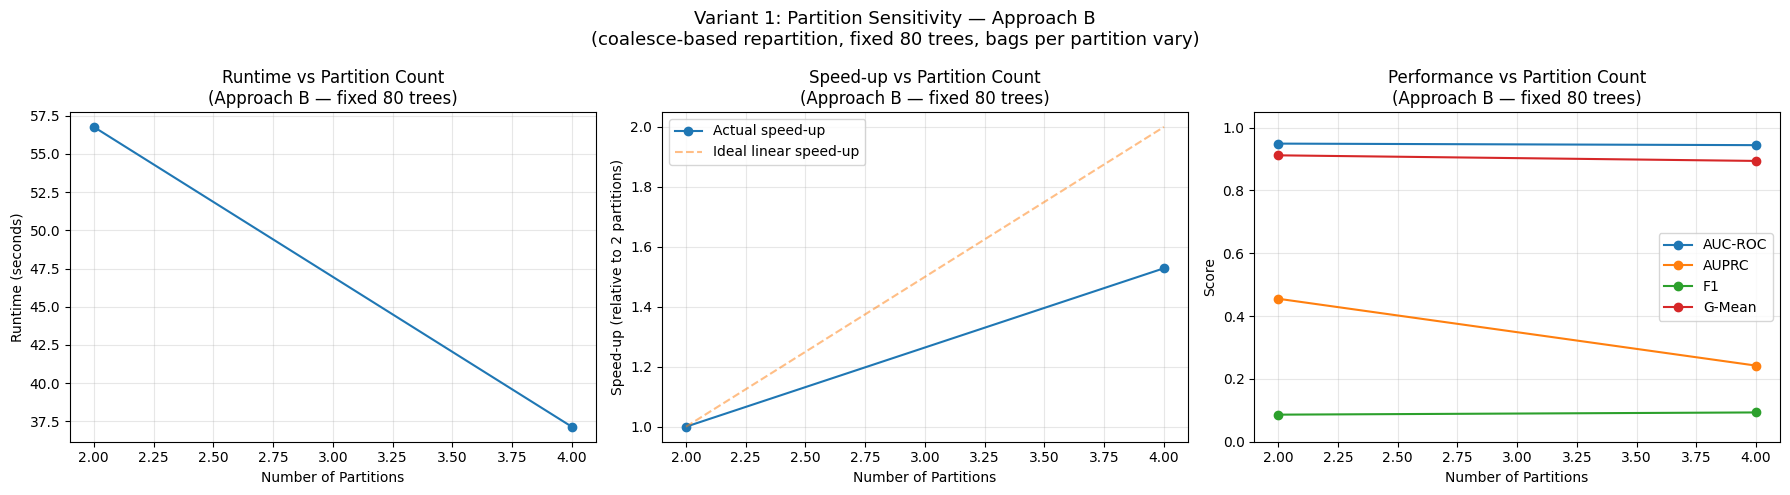


OBSERVATION:
Approach B fixes total trees at 80 but per-tree bag size still varies
because each partition holds different amounts of majority data.
Repartitioning uses coalesce() — no shuffle — consistent with Variant 1's
local-first, zero cross-partition movement design.
→ Proceed to Approach C to also fix bag size per tree.


In [0]:
print(f"\nFixed total trees: {TOTAL_TREES_B}")
print(f"\n{'Parts':<7} {'Bags/P':<8} {'Trees':<7} {'Time(s)':<10} {'AUC':<8} "
      f"{'AUPRC':<8} {'F1':<8} {'GMean':<8} {'Min/Part':<10}")
print("=" * 85)
 
for r in partition_results_b:
    print(f"{r['num_partitions']:<7} {r['bags_per_partition']:<8} "
          f"{r['num_trees']:<7} {r['runtime_sec']:<10.2f} "
          f"{r['auc_roc']:<8.4f} {r['auprc']:<8.4f} "
          f"{r['f1']:<8.4f} {r['gmean']:<8.4f} "
          f"{r['minority_per_partition_avg']:<10.0f}")
 
baseline_rt_b = partition_results_b[0]["runtime_sec"]
print(f"\nSpeed-up relative to 2 partitions (fixed {TOTAL_TREES_B} trees):")
for r in partition_results_b:
    speedup = baseline_rt_b / r["runtime_sec"] if r["runtime_sec"] > 0 else 0
    print(f"  {r['num_partitions']} partitions: {speedup:.2f}x")
 
import matplotlib.pyplot as plt
import pandas as pd
 
pdf_b = pd.DataFrame(partition_results_b).sort_values("num_partitions")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Variant 1: Partition Sensitivity — Approach B\n"
    f"(coalesce-based repartition, fixed {TOTAL_TREES_B} trees, bags per partition vary)",
    fontsize=13
)
 
# Plot 1 - Runtime vs partitions
axes[0].plot(pdf_b["num_partitions"], pdf_b["runtime_sec"], marker="o")
axes[0].set_xlabel("Number of Partitions")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title(
    f"Runtime vs Partition Count\n"
    f"(Approach B — fixed {TOTAL_TREES_B} trees)"
)
axes[0].grid(True, alpha=0.3)
 
# Plot 2 - Speed-up vs partitions
axes[1].plot(
    pdf_b["num_partitions"],
    baseline_rt_b / pdf_b["runtime_sec"],
    marker="o", label="Actual speed-up"
)
axes[1].plot(
    pdf_b["num_partitions"],
    pdf_b["num_partitions"] / pdf_b["num_partitions"].iloc[0],
    linestyle="--", alpha=0.5, label="Ideal linear speed-up"
)
axes[1].set_xlabel("Number of Partitions")
axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title(
    f"Speed-up vs Partition Count\n"
    f"(Approach B — fixed {TOTAL_TREES_B} trees)"
)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
# Plot 3 - Performance vs partitions
axes[2].plot(pdf_b["num_partitions"], pdf_b["auc_roc"], marker="o", label="AUC-ROC")
axes[2].plot(pdf_b["num_partitions"], pdf_b["auprc"],   marker="o", label="AUPRC")
axes[2].plot(pdf_b["num_partitions"], pdf_b["f1"],      marker="o", label="F1")
axes[2].plot(pdf_b["num_partitions"], pdf_b["gmean"],   marker="o", label="G-Mean")
axes[2].set_xlabel("Number of Partitions")
axes[2].set_ylabel("Score")
axes[2].set_title(
    f"Performance vs Partition Count\n"
    f"(Approach B — fixed {TOTAL_TREES_B} trees)"
)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1.05)
 
plt.tight_layout()
plt.show()
 
print("\nOBSERVATION:")
print("Approach B fixes total trees at 80 but per-tree bag size still varies")
print("because each partition holds different amounts of majority data.")
print("Repartitioning uses coalesce() — no shuffle — consistent with Variant 1's")
print("local-first, zero cross-partition movement design.")
print("→ Proceed to Approach C to also fix bag size per tree.")

**Approach C - Fixed Tree Size and Bag Size**
- Fix total trees at 80 AND fix bag size per tree
- Most controlled experiment — only partition count changes
- Per-tree workload is identical across all partition counts

In [0]:
TOTAL_TREES_C      = 80
PARTITION_VALUES_C = [2, 4, 8, 16]
THRESHOLD_C        = 0.5
K_C                = 5
MAX_DEPTH_C        = 10
FIXED_BAG_SIZE_C   = 10000   # fixed majority bag size per tree
 
BAGS_BY_PARTITION_C = {
    2:  40,
    4:  20,
    8:  10,
    16: 5
}
 
RATE_SCHEDULES_C = {
    40: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 4,
    20: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 2,
    10: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    5:  [0.1, 0.3, 0.5, 0.7, 0.9]
}
 
print("=" * 70)
print("EXPERIMENT 1: PARTITION SENSITIVITY — APPROACH C")
print("=" * 70)
print(f"Total trees fixed at: {TOTAL_TREES_C}")
print(f"Fixed majority bag size: {FIXED_BAG_SIZE_C} per tree")
print(f"Partition counts: {PARTITION_VALUES_C}")
print(f"Threshold: {THRESHOLD_C}")
print(f"K: {K_C}, Max depth: {MAX_DEPTH_C}")
print("=" * 70)
 
print(f"\n{'Partitions':<12} {'Bags/Partition':<16} {'Total Trees':<14} {'Bag Size'}")
print("-" * 55)
for p in PARTITION_VALUES_C:
    print(f"{p:<12} {BAGS_BY_PARTITION_C[p]:<16} {TOTAL_TREES_C:<14} {FIXED_BAG_SIZE_C}")

EXPERIMENT 1: PARTITION SENSITIVITY — APPROACH C
Total trees fixed at: 80
Fixed majority bag size: 10000 per tree
Partition counts: [2, 4, 8, 16]
Threshold: 0.5
K: 5, Max depth: 10

Partitions   Bags/Partition   Total Trees    Bag Size
-------------------------------------------------------
2            40               80             10000
4            20               80             10000
8            10               80             10000
16           5                80             10000


**Runner Function - Approach C**

- Fixed total trees - 80
- Fixed majority bag size per tree - 10,000
- Only partition count varies - most controlled experiment

In [0]:
def run_variant1_approach_c(num_partitions, total_trees=80, fixed_bag_size=10000, threshold=0.5, K=5, max_depth=10):
  
    import time
    import numpy as np
    import pandas as pd
    from pyspark.sql.functions import spark_partition_id, col
    from sklearn.metrics import (
        roc_auc_score, average_precision_score, f1_score, confusion_matrix
    )
 
    bags_per_partition = BAGS_BY_PARTITION_C[num_partitions]
    rate_schedule      = RATE_SCHEDULES_C[bags_per_partition]
 
    # Step 1 — repartition using coalesce (or repartition if splitting is required), consistent with Variant 1.
    
    current_parts = train_final.rdd.getNumPartitions()
 
    if num_partitions <= current_parts:
        # Merge partitions locally — zero shuffle, fully aligned to design
        train_repartitioned = train_final.coalesce(num_partitions)
    else:
        # Splitting requires a shuffle; unavoidable when num_partitions
        # exceeds the current partition count. Documented exception.
        train_repartitioned = train_final.repartition(num_partitions)
 
    train_repartitioned.cache()
    train_repartitioned.count()
 
    # Step 2 — minority per partition diagnostics
    
    part_info = train_repartitioned.withColumn("part_id", spark_partition_id())
    minority_per_partition = (
        part_info.filter(col("label") == 1)
        .groupBy("part_id")
        .count()
        .orderBy("part_id")
        .collect()
    )
    part_minority_counts = [int(r["count"]) for r in minority_per_partition]
    print(f"  Minority per partition: {part_minority_counts}")
 
    # Step 3 — broadcast ALL values workers need explicitly.
    # rate_schedule and bag_size broadcast explicitly - workers cannot access driver-side dicts or scalars via closure.
    
    T_bc_c = sc.broadcast(bags_per_partition)
    K_bc_c = sc.broadcast(K)
    depth_bc_c = sc.broadcast(max_depth)
    rate_schedule_bc = sc.broadcast(rate_schedule)
    bag_size_bc = sc.broadcast(fixed_bag_size)
    # test_features_exp_bc already broadcast at top of experiment cell
 
    # Step 4 — worker function
     
    def process_partition_c(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier
 
        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])
 
        minority = [r for r in rows_list if r["label"] == 1]
        majority = [r for r in rows_list if r["label"] == 0]
 
        # Failsafe — case 1: if either class absent, skip partition
        if len(minority) == 0 or len(majority) == 0:
            return iter([])
 
        # Retrieve all broadcast values
        t_features          = test_features_exp_bc.value
        T_local             = T_bc_c.value
        K_local             = K_bc_c.value
        depth_local         = depth_bc_c.value
        rate_schedule_local = rate_schedule_bc.value
        maj_bag_size        = bag_size_bc.value
 
        # Convert test features to numpy once — reused for all bags
        test_X = np.array([f.toArray() for f in t_features])
 
        # Convert minority to numpy once — reused across all bags
        samples_array = np.array([
            np.array(r["features"].toArray()) for r in minority
        ])
        n_minority = len(samples_array)
 
        # Precompute k-NN once per partition — mirrors smote_from_scratch()
        eff_k = min(K_local, n_minority - 1)
 
        if eff_k < 1:
            # Failsafe — case 2: too few minority for k-NN
            knn_indices = None
        else:
            X_sq    = np.sum(samples_array ** 2, axis=1, keepdims=True)
            cross   = samples_array @ samples_array.T
            dist_sq = np.clip(X_sq + X_sq.T - 2 * cross, 0.0, None)
            np.fill_diagonal(dist_sq, np.inf)
            knn_indices = np.argsort(dist_sq, axis=1)[:, :eff_k]
 
        def smote_local(samples_array, knn_indices, n_synthetic, rng):
            if len(samples_array) == 0 or n_synthetic <= 0:
                return []
            synthetic_samples = []
            if knn_indices is None:
                # Case 2 fallback: random duplication with replacement
                for _ in range(n_synthetic):
                    idx = rng.randint(0, len(samples_array))
                    synthetic_samples.append(samples_array[idx].copy())
            else:
                for _ in range(n_synthetic):
                    idx           = rng.randint(0, len(samples_array))
                    nn_choice     = rng.randint(0, knn_indices.shape[1])
                    neighbour_idx = knn_indices[idx, nn_choice]
                    gap           = rng.random()
                    synthetic     = samples_array[idx] + gap * (
                        samples_array[neighbour_idx] - samples_array[idx]
                    )
                    synthetic_samples.append(synthetic)
            return synthetic_samples
 
        results = []
 
        for bag in range(1, T_local + 1):
            bag_seed = partition_id * 1000 + bag
            rng = np.random.RandomState(bag_seed)
            oversample_rate = rate_schedule_local[bag - 1]
            n_synthetic = int(n_minority * oversample_rate)
 
            # Fixed bag size — sample maj_bag_size rows regardless of
            # partition size. This is the key difference from Approach B:
            # every tree trains on the same amount of majority data.
            bootstrap_majority = [
                majority[rng.randint(0, len(majority))]
                for _ in range(maj_bag_size)
            ]
 
            synthetic_vectors = smote_local(
                samples_array, knn_indices, n_synthetic, rng
            )
 
            X_train, y_train = [], []
            for r in bootstrap_majority:
                X_train.append(r["features"].toArray()); y_train.append(0)
            for s_arr in samples_array:
                X_train.append(s_arr); y_train.append(1)
            for s in synthetic_vectors:
                X_train.append(s); y_train.append(1)
 
            X_train = np.array(X_train)
            y_train = np.array(y_train)
 
            dt = DecisionTreeClassifier(max_depth=depth_local, random_state=bag_seed)
            dt.fit(X_train, y_train)
 
            bag_preds = dt.predict(test_X).tolist()
            results.append((partition_id, bag, [int(p) for p in bag_preds]))
 
        return iter(results)
 
    # Step 5 - run and time
    
    start_time = time.time()
 
    preds_raw = (
        train_repartitioned.rdd
        .mapPartitionsWithIndex(process_partition_c)
        .collect()
    )
 
    runtime_sec = round(time.time() - start_time, 2)
 
    # Cleanup
    train_repartitioned.unpersist()
    T_bc_c.unpersist()
    K_bc_c.unpersist()
    depth_bc_c.unpersist()
    rate_schedule_bc.unpersist()
    bag_size_bc.unpersist()
 
    # Step 6 — aggregate and evaluate
    
    # Guard - if no predictions returned, skip this run
    if len(preds_raw) == 0:
        print(f"  WARNING: No predictions returned for {num_partitions} "
              f"partitions — skipping.")
        return None
 
    preds_sorted = sorted(preds_raw, key=lambda x: (x[0], x[1]))
    pred_lists   = [x[2] for x in preds_sorted]
    pred_matrix  = np.array(pred_lists, dtype=np.int32)
 
    n_trees     = pred_matrix.shape[0]
    vote_sums   = pred_matrix.sum(axis=0)
    vote_scores = vote_sums / n_trees
    y_true      = np.array(test_labels_exp)
 
    auc_roc = roc_auc_score(y_true, vote_scores)
    auprc   = average_precision_score(y_true, vote_scores)
 
    preds_final    = (vote_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_final).ravel()
 
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, preds_final)
    gmean = np.sqrt(recall * specificity)
 
    return {
        "num_partitions": int(num_partitions),
        "bags_per_partition": int(bags_per_partition),
        "num_trees": int(n_trees),
        "fixed_bag_size": int(fixed_bag_size),
        "runtime_sec": float(runtime_sec),
        "auc_roc": float(auc_roc),
        "auprc": float(auprc),
        "f1": float(f1),
        "gmean": float(gmean),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "minority_per_partition_avg": float(np.mean(part_minority_counts)),
        "minority_per_partition_min": int(min(part_minority_counts)),
        "minority_per_partition_max": int(max(part_minority_counts))
    }
 
 
# LOOP - run Approach C for all partition counts
 
print("Approach C runner ready.")
 
partition_results_c = []
 
for n_parts in PARTITION_VALUES_C:
    bags_here = BAGS_BY_PARTITION_C[n_parts]
    print(f"\n{'-' * 62}")
    print(f"Running with {n_parts} partitions, {bags_here} bags, "
          f"bag size={FIXED_BAG_SIZE_C} (80 trees total)...")
    print(f"{'-' * 62}")
 
    result = run_variant1_approach_c(
        num_partitions=n_parts,
        total_trees=TOTAL_TREES_C,
        fixed_bag_size=FIXED_BAG_SIZE_C,
        threshold=THRESHOLD_C,
        K=K_C,
        max_depth=MAX_DEPTH_C
    )
 
    if result is None:
        print(f"  Skipped {n_parts} partitions — no valid predictions.")
        continue
 
    partition_results_c.append(result)
 
    print(f"Trees: {result['num_trees']}")
    print(f"Bags/partition: {result['bags_per_partition']}")
    print(f"Bag size: {result['fixed_bag_size']}")
    print(f"Runtime: {result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC: {result['auc_roc']:.4f}")
    print(f"AUPRC: {result['auprc']:.4f}")
    print(f"F1: {result['f1']:.4f}")
    print(f"G-Mean: {result['gmean']:.4f}")
    print(f"Minority/part:  avg={result['minority_per_partition_avg']:.0f}, "
          f"min={result['minority_per_partition_min']}, "
          f"max={result['minority_per_partition_max']}")
 
partition_results_c_df = spark.createDataFrame(pd.DataFrame(partition_results_c))
display(partition_results_c_df.orderBy("num_partitions"))

Approach C runner ready.

--------------------------------------------------------------
Running with 2 partitions, 40 bags, bag size=10000 (80 trees total)...
--------------------------------------------------------------
  Minority per partition: [384]
Trees: 40
Bags/partition: 40
Bag size: 10000
Runtime: 23.40 sec
AUC-ROC: 0.9534
AUPRC: 0.2139
F1: 0.0743
G-Mean: 0.9183
Minority/part:  avg=384, min=384, max=384

--------------------------------------------------------------
Running with 4 partitions, 20 bags, bag size=10000 (80 trees total)...
--------------------------------------------------------------
  Minority per partition: [251, 133]
Trees: 20
Bags/partition: 20
Bag size: 10000
Runtime: 12.45 sec
AUC-ROC: 0.9428
AUPRC: 0.0746
F1: 0.0822
G-Mean: 0.9157
Minority/part:  avg=192, min=133, max=251

--------------------------------------------------------------
Running with 8 partitions, 10 bags, bag size=10000 (80 trees total)...
---------------------------------------------------

num_partitions,bags_per_partition,num_trees,fixed_bag_size,runtime_sec,auc_roc,auprc,f1,gmean,precision,recall,specificity,tp,fp,fn,tn,minority_per_partition_avg,minority_per_partition_min,minority_per_partition_max
2,40,40,10000,23.4,0.9534356215109412,0.21392920231093093,0.07430582714118106,0.9182631756653675,0.03879134340547162,0.8796296296296297,0.9585935163849361,95,2354,13,54497,384.0,384,384
4,20,20,10000,12.45,0.942757937089611,0.07458811096084068,0.08220376038478355,0.9156689885763336,0.043139054612207434,0.8703703703703703,0.9633251833740831,94,2085,14,54766,192.0,133,251


**Approach C - Results Summary and Plots**


Fixed total trees: 80
Fixed bag size per tree: 10000

Parts   Bags/P   Trees   BagSize   Time(s)    AUC      AUPRC    F1       GMean    Min/Part  
2       40       40      10000     23.40      0.9534   0.2139   0.0743   0.9183   384       
4       20       20      10000     12.45      0.9428   0.0746   0.0822   0.9157   192       

Speed-up relative to 2 partitions (fully controlled):
  2 partitions: 1.00x
  4 partitions: 1.88x


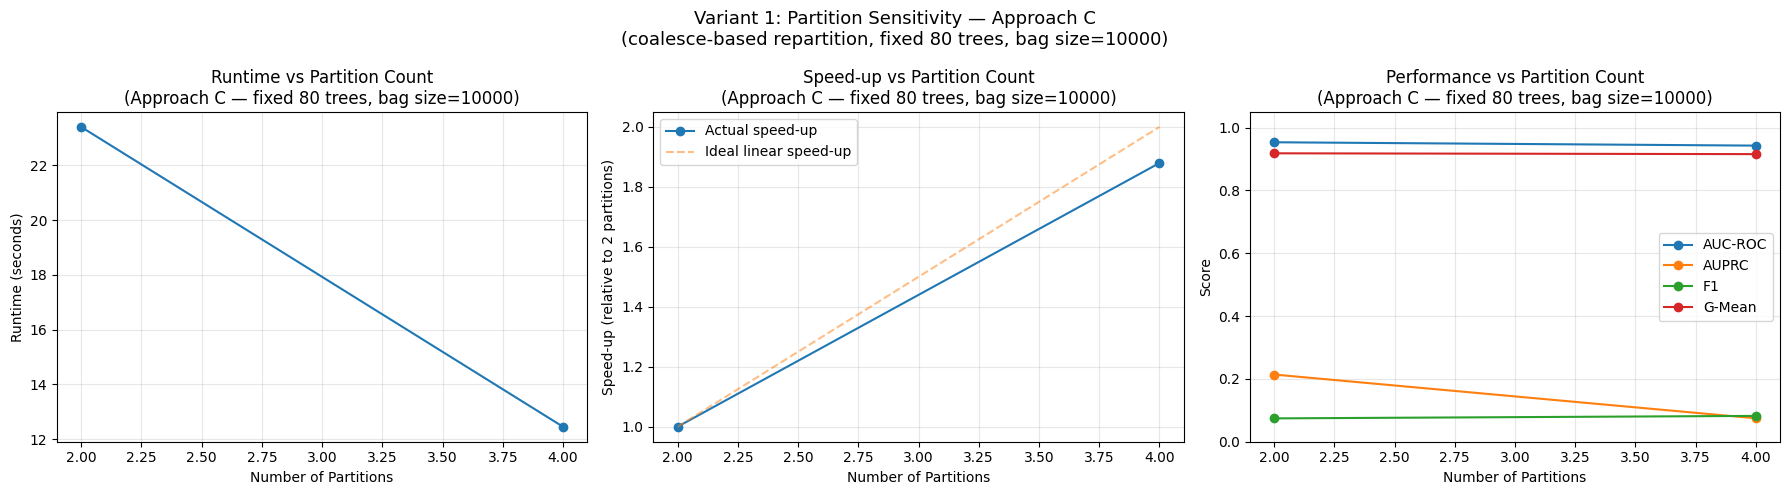


KEY FINDINGS (Fully Controlled):
  AUC range:     0.0107 (min=0.9428 @ 4P, max=0.9534 @ 2P)
  Fastest:       12.45s @ 4 partitions
  Slowest:       23.40s @ 2 partitions
  Max speed-up:  1.88x

Note: Any F1/AUC degradation at 16 partitions is now purely due to
minority starvation (~25 samples/partition), not bag size or tree count.

This is Variant 1's fundamental limitation — local SMOTE degrades
as minority samples thin out across more partitions.


In [0]:
print(f"\nFixed total trees: {TOTAL_TREES_C}")
print(f"Fixed bag size per tree: {FIXED_BAG_SIZE_C}")
 
print(f"\n{'Parts':<7} {'Bags/P':<8} {'Trees':<7} {'BagSize':<9} {'Time(s)':<10} "
      f"{'AUC':<8} {'AUPRC':<8} {'F1':<8} {'GMean':<8} {'Min/Part':<10}")
print("=" * 100)
 
for r in partition_results_c:
    print(f"{r['num_partitions']:<7} {r['bags_per_partition']:<8} "
          f"{r['num_trees']:<7} {r['fixed_bag_size']:<9} "
          f"{r['runtime_sec']:<10.2f} {r['auc_roc']:<8.4f} "
          f"{r['auprc']:<8.4f} {r['f1']:<8.4f} "
          f"{r['gmean']:<8.4f} {r['minority_per_partition_avg']:<10.0f}")
 
baseline_rt_c = partition_results_c[0]["runtime_sec"]
print(f"\nSpeed-up relative to 2 partitions (fully controlled):")
for r in partition_results_c:
    speedup = baseline_rt_c / r["runtime_sec"] if r["runtime_sec"] > 0 else 0
    print(f"  {r['num_partitions']} partitions: {speedup:.2f}x")
 
import matplotlib.pyplot as plt
import pandas as pd
 
pdf_c = pd.DataFrame(partition_results_c).sort_values("num_partitions")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Variant 1: Partition Sensitivity — Approach C\n"
    f"(coalesce-based repartition, fixed {TOTAL_TREES_C} trees, "
    f"bag size={FIXED_BAG_SIZE_C})",
    fontsize=13
)
 
# Plot 1 - Runtime vs partitions
axes[0].plot(pdf_c["num_partitions"], pdf_c["runtime_sec"], marker="o")
axes[0].set_xlabel("Number of Partitions")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title(
    f"Runtime vs Partition Count\n"
    f"(Approach C — fixed {TOTAL_TREES_C} trees, bag size={FIXED_BAG_SIZE_C})"
)
axes[0].grid(True, alpha=0.3)
 
# Plot 2 - Speed-up vs partitions
axes[1].plot(
    pdf_c["num_partitions"],
    baseline_rt_c / pdf_c["runtime_sec"],
    marker="o", label="Actual speed-up"
)
axes[1].plot(
    pdf_c["num_partitions"],
    pdf_c["num_partitions"] / pdf_c["num_partitions"].iloc[0],
    linestyle="--", alpha=0.5, label="Ideal linear speed-up"
)
axes[1].set_xlabel("Number of Partitions")
axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title(
    f"Speed-up vs Partition Count\n"
    f"(Approach C — fixed {TOTAL_TREES_C} trees, bag size={FIXED_BAG_SIZE_C})"
)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
# Plot 3 - Performance vs partitions
axes[2].plot(pdf_c["num_partitions"], pdf_c["auc_roc"], marker="o", label="AUC-ROC")
axes[2].plot(pdf_c["num_partitions"], pdf_c["auprc"],   marker="o", label="AUPRC")
axes[2].plot(pdf_c["num_partitions"], pdf_c["f1"],      marker="o", label="F1")
axes[2].plot(pdf_c["num_partitions"], pdf_c["gmean"],   marker="o", label="G-Mean")
axes[2].set_xlabel("Number of Partitions")
axes[2].set_ylabel("Score")
axes[2].set_title(
    f"Performance vs Partition Count\n"
    f"(Approach C — fixed {TOTAL_TREES_C} trees, bag size={FIXED_BAG_SIZE_C})"
)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1.05)
 
plt.tight_layout()
plt.show()
 
best_auc  = max(partition_results_c, key=lambda r: r["auc_roc"])
worst_auc = min(partition_results_c, key=lambda r: r["auc_roc"])
fastest   = min(partition_results_c, key=lambda r: r["runtime_sec"])
slowest   = max(partition_results_c, key=lambda r: r["runtime_sec"])
 
auc_range   = best_auc["auc_roc"] - worst_auc["auc_roc"]
max_speedup = slowest["runtime_sec"] / fastest["runtime_sec"]
 
print("\nKEY FINDINGS (Fully Controlled):")
print(f"  AUC range:     {auc_range:.4f} "
      f"(min={worst_auc['auc_roc']:.4f} @ {worst_auc['num_partitions']}P, "
      f"max={best_auc['auc_roc']:.4f} @ {best_auc['num_partitions']}P)")
print(f"  Fastest:       {fastest['runtime_sec']:.2f}s @ {fastest['num_partitions']} partitions")
print(f"  Slowest:       {slowest['runtime_sec']:.2f}s @ {slowest['num_partitions']} partitions")
print(f"  Max speed-up:  {max_speedup:.2f}x")
print(f"\nNote: Any F1/AUC degradation at 16 partitions is now purely due to")
print(f"minority starvation (~25 samples/partition), not bag size or tree count.")
print(f"\nThis is Variant 1's fundamental limitation — local SMOTE degrades")
print(f"as minority samples thin out across more partitions.")

**Saving The Results for All Aproaches**

In [0]:
# Build v1_partition_results - list of dicts with keys: num_partitions, runtime, auc, f1
# Sourced from Approach C as the most controlled run (fixed trees + fixed bag size).
# Falls back to B then A if C is unavailable for a given partition count.

results_by_parts_c = {r["num_partitions"]: r for r in partition_results_c}
results_by_parts_b = {r["num_partitions"]: r for r in partition_results_b}
results_by_parts_a = {r["num_partitions"]: r for r in partition_results_a}

v1_partition_results = []
for p in [2, 4, 8, 16]:
    source = (results_by_parts_c.get(p)
              or results_by_parts_b.get(p)
              or results_by_parts_a.get(p))
    if source:
        v1_partition_results.append({
            "num_partitions": source["num_partitions"],
            "runtime":        source["runtime_sec"],
            "auc":            source["auc_roc"],
            "f1":             source["f1"]
        })

print(f"v1_partition_results assembled: {len(v1_partition_results)} entries")
for r in v1_partition_results:
    print(f"  {r['num_partitions']} partitions — "
          f"runtime={r['runtime']:.2f}s, auc={r['auc']:.4f}, f1={r['f1']:.4f}")


# Save all three approaches and the consolidated summary

partition_results_a_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant1_partition_sensitivity_a.parquet")

partition_results_b_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant1_partition_sensitivity_b.parquet")

partition_results_c_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant1_partition_sensitivity_c.parquet")

spark.createDataFrame(pd.DataFrame(v1_partition_results)) \
     .write.mode("overwrite").parquet(
         "/mnt/2026-group7/results/variant1_partition_sensitivity_summary.parquet")

print("\nPartition sensitivity results saved:")
print("  /mnt/2026-group7/results/variant1_partition_sensitivity_a.parquet")
print("  /mnt/2026-group7/results/variant1_partition_sensitivity_b.parquet")
print("  /mnt/2026-group7/results/variant1_partition_sensitivity_c.parquet")
print("  /mnt/2026-group7/results/variant1_partition_sensitivity_summary.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

####Variant 2 - Partition Sensitivity 

##### Approach A - Vary Partitions

- Approach A - vary partitions 2/4/8/16, T=10 fixed per partition
- Note: total trees change (20/40/80/160) - confounded variable
- This is intentional - we identify the confounding in Approach B


In [0]:

# SET UP — Partition Sensitivity Experiment

PARTITION_VALUES_EXP = [2, 4, 8, 16]
T_EXP      = 10
K_EXP      = 5
MAX_DEPTH_EXP  = 10
THRESHOLD_EXP  = 0.5 # fair comparison threshold


print("PARTITION SENSITIVITY — APPROACH A")
print(f"Partition counts: {PARTITION_VALUES_EXP}")
print(f"Bags per partition: {T_EXP} (fixed)")
print(f"Total trees: varies with partition count")
print(f"Fixed settings: K={K_EXP}, max_depth={MAX_DEPTH_EXP}")
print(f"Threshold: {THRESHOLD_EXP}")
print("=" * 70)

# Partition counts and their total trees
print(f"\n{'Partitions':<12} {'Bags/Partition':<16} {'Total Trees'}")
print("-" * 40)
for p in PARTITION_VALUES_EXP:
    print(f"{p:<12} {T_EXP:<16} {p * T_EXP}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

**Runner Function - Approach A**

- Repartitions data and reruns full SMOTEBagging pipeline
-  Returns runtime, performance metrics, partition diagnostics

In [0]:

# Broadcast test set — convert to plain lists before broadcasting
# so .toArray() is never needed inside workers after Parquet reload
test_collected_exp = test_final_v2b.collect()
test_features_exp = [
    row["features"].toArray().tolist() if hasattr(row["features"], 'toArray')
    else list(row["features"])
    for row in test_collected_exp
]
test_labels_exp = [int(row["label"]) for row in test_collected_exp]
test_features_bc_exp = sc.broadcast(test_features_exp)
test_labels_bc_exp   = sc.broadcast(test_labels_exp)

print(f"Test samples broadcast: {len(test_features_exp)}")


def run_variant2_partition_experiment(num_partitions, T=10, K=5, max_depth=10, threshold=0.5):
    """
    Run Variant 2B SMOTEBagging with a given number of partitions.
    T bags per partition — total trees = num_partitions * T
    """

    
    # Step 1 — stratified repartition with given partition count
    minority_rdd = train_final_v2b.filter(col("label") == 1)
    majority_rdd = train_final_v2b.filter(col("label") == 0)

    def assign_ids_local(rows):
        for i, row in enumerate(rows):
            yield (int(i % num_partitions), row)

    minority_keyed = minority_rdd.rdd.mapPartitions(assign_ids_local)
    majority_keyed = majority_rdd.rdd.mapPartitions(assign_ids_local)

    combined = minority_keyed.union(majority_keyed)

    train_repartitioned = combined.partitionBy(num_partitions) \
                                  .map(lambda x: x[1])
    train_repartitioned = spark.createDataFrame(
        train_repartitioned,
        schema=train_final_v2b.schema
    )
    train_repartitioned.cache()
    train_repartitioned.count()

    
    # Step 2 — log minority samples per partition
    # Key diagnostic for Variant 2 — shows starvation at high partitions
    part_info = train_repartitioned.withColumn("part_id", spark_partition_id())
    minority_per_partition = (
        part_info.filter(col("label") == 1)
        .groupBy("part_id")
        .count()
        .orderBy("part_id")
        .collect()
    )
    part_minority_counts = [int(r["count"]) for r in minority_per_partition]

    # Step 3 — broadcast scalars
    T_bc_exp = sc.broadcast(T)
    K_bc_exp = sc.broadcast(K)

    # Step 4 — worker function
    def process_partition_exp(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier

        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])

        minority = [r for r in rows_list if r["label"] == 1]
        majority = [r for r in rows_list if r["label"] == 0]

        if len(minority) == 0 or len(majority) == 0:
            return iter([])

        # test_features_bc_exp contains plain lists — no .toArray() needed
        t_features = test_features_bc_exp.value
        T_local    = T_bc_exp.value
        K_local    = K_bc_exp.value
        test_X     = np.array(t_features, dtype=np.float64)

        # Helper — handles both DenseVector and plain list
        def to_numpy(feat):
            if hasattr(feat, 'toArray'):
                return feat.toArray()
            return np.array(feat, dtype=np.float64)

        samples_array = np.array([
            to_numpy(r["features"]) for r in minority
        ], dtype=np.float64)
        n_minority = len(samples_array)

        # Precompute k-NN once per partition
        eff_k   = min(K_local, n_minority - 1)
        X_sq    = np.sum(samples_array ** 2, axis=1, keepdims=True)
        cross   = samples_array @ samples_array.T
        dist_sq = np.clip(X_sq + X_sq.T - 2 * cross, 0.0, None)
        np.fill_diagonal(dist_sq, np.inf)
        knn_indices = np.argsort(dist_sq, axis=1)[:, :eff_k]

        # SMOTE using precomputed k-NN
        def smote_partition(samples_array, knn_indices, n_synthetic, rng):
            if len(samples_array) == 0 or n_synthetic <= 0:
                return []
            synthetic_samples = []
            for _ in range(n_synthetic):
                idx   = rng.randint(0, len(samples_array))
                nn_choice = rng.randint(0, knn_indices.shape[1])
                neighbour_idx = knn_indices[idx, nn_choice]
                gap  = rng.random()
                synthetic     = samples_array[idx] + gap * (
                    samples_array[neighbour_idx] - samples_array[idx]
                )
                synthetic_samples.append(synthetic)
            return synthetic_samples

        results = []

        for bag in range(1, T_local + 1):
            bag_seed = partition_id * 1000 + bag
            rng  = np.random.RandomState(bag_seed)
            oversample_rate = bag * 0.1
            n_synthetic = int(n_minority * oversample_rate)

            # Bootstrap majority with replacement
            bootstrap_majority = [
                majority[rng.randint(0, len(majority))]
                for _ in range(len(majority))
            ]

            # Local SMOTE using precomputed k-NN
            # k-NN uses only local partition minority — Variant 2B design
            synthetic_vectors = smote_partition(
                samples_array, knn_indices, n_synthetic, rng
            )

            # Combine into training set
            X_train, y_train = [], []
            for r in bootstrap_majority:
                X_train.append(to_numpy(r["features"]))
                y_train.append(0)
            for s_arr in samples_array:
                X_train.append(s_arr)
                y_train.append(1)
            for s in synthetic_vectors:
                X_train.append(s)
                y_train.append(1)

            X_train = np.array(X_train, dtype=np.float64)
            y_train = np.array(y_train)

            dt = DecisionTreeClassifier(max_depth=max_depth, random_state=bag_seed)
            dt.fit(X_train, y_train)

            bag_preds = dt.predict(test_X).tolist()
            results.append((partition_id, bag, [int(p) for p in bag_preds]))

        return iter(results)

    # Step 5 — run and time
    start_time = time.time()

    preds_raw = (
        train_repartitioned.rdd
        .mapPartitionsWithIndex(process_partition_exp)
        .collect()
    )

    runtime_sec = round(time.time() - start_time, 2)

    # Cleanup
    train_repartitioned.unpersist()
    T_bc_exp.unpersist()
    K_bc_exp.unpersist()

    # Step 6 — aggregate predictions and compute metrics
    preds_sorted = sorted(preds_raw, key=lambda x: (x[0], x[1]))
    pred_lists   = [x[2] for x in preds_sorted]
    pred_matrix  = np.array(pred_lists, dtype=np.int32)

    n_trees = pred_matrix.shape[0]
    vote_sums = pred_matrix.sum(axis=0)
    vote_scores = vote_sums / n_trees

    y_true = np.array(test_labels_exp)

    auc_roc = roc_auc_score(y_true, vote_scores)
    auprc   = average_precision_score(y_true, vote_scores)

    preds_final = (vote_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_final).ravel()

    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, preds_final)
    gmean       = np.sqrt(recall * specificity)

    return {
        "num_partitions": int(num_partitions),
        "num_trees":int(n_trees),
        "runtime_sec": float(runtime_sec),
        "auc_roc": float(auc_roc),
        "auprc": float(auprc),
        "f1": float(f1),
        "gmean": float(gmean),
        "precision": float(precision),
        "recall":float(recall),
        "specificity": float(specificity),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "minority_per_partition_avg": float(np.mean(part_minority_counts)),
        "minority_per_partition_min": int(min(part_minority_counts)),
        "minority_per_partition_max": int(max(part_minority_counts))
    }


print("Approach A runner ready.")

partition_results_a = []

for n_parts in PARTITION_VALUES_EXP:
    print(f"\n{'-' * 55}")
    print(f"Running with {n_parts} partitions, {T_EXP} bags each ({n_parts * T_EXP} trees total)...")
    print(f"{'-' * 55}")

    result = run_variant2_partition_experiment(
        num_partitions=n_parts,
        T=T_EXP, K=K_EXP,
        max_depth=MAX_DEPTH_EXP,
        threshold=THRESHOLD_EXP
    )

    partition_results_a.append(result)

    print(f"Trees: {result['num_trees']}")
    print(f"Runtime:  {result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC: {result['auc_roc']:.4f}")
    print(f"AUPRC:{result['auprc']:.4f}")
    print(f"F1: {result['f1']:.4f}")
    print(f"G-Mean: {result['gmean']:.4f}")
    print(f"Minority/part:    avg={result['minority_per_partition_avg']:.0f}, "
          f"min={result['minority_per_partition_min']}, "
          f"max={result['minority_per_partition_max']}")

partition_results_a_df = spark.createDataFrame(pd.DataFrame(partition_results_a))
display(partition_results_a_df.orderBy("num_partitions"))

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

**Approach A - Results Summary and Plots**

In [0]:

# Approach A results summary and plots

print(f"\n{'Parts':<8} {'Trees':<8} {'Time(s)':<10} {'AUC':<8} "
      f"{'AUPRC':<8} {'F1':<8} {'GMean':<8} {'Min/Part':<10}")
print("=" * 75)

for r in partition_results_a:
    print(f"{r['num_partitions']:<8} {r['num_trees']:<8} "
          f"{r['runtime_sec']:<10.2f} {r['auc_roc']:<8.4f} "
          f"{r['auprc']:<8.4f} {r['f1']:<8.4f} "
          f"{r['gmean']:<8.4f} {r['minority_per_partition_avg']:<10.0f}")

baseline_rt_a = partition_results_a[0]["runtime_sec"]
print(f"\nSpeed-up relative to 2 partitions:")
for r in partition_results_a:
    speedup = baseline_rt_a / r["runtime_sec"] if r["runtime_sec"] > 0 else 0
    print(f"  {r['num_partitions']} partitions: {speedup:.2f}x")

# Plots
pdf_a = pd.DataFrame(partition_results_a).sort_values("num_partitions")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Runtime vs partitions
axes[0].plot(pdf_a["num_partitions"], pdf_a["runtime_sec"], marker="o")
axes[0].set_xlabel("Number of Partitions")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Variant 2: Runtime vs Partition Count\n(Approach A — varying total trees)")
axes[0].grid(True, alpha=0.3)

# Plot 2 — Speed-up vs partitions
axes[1].plot(pdf_a["num_partitions"],
             baseline_rt_a / pdf_a["runtime_sec"],
             marker="o", label="Actual speed-up")
axes[1].plot(pdf_a["num_partitions"],
             pdf_a["num_partitions"] / pdf_a["num_partitions"].iloc[0],
             linestyle="--", alpha=0.5, label="Ideal linear speed-up")
axes[1].set_xlabel("Number of Partitions")
axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title("Variant 2: Speed-up vs Partition Count\n(Approach A)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — Performance vs partitions
ax3 = axes[2]
ax3.plot(pdf_a["num_partitions"], pdf_a["auc_roc"], marker="o", label="AUC-ROC", color="blue")
ax3.plot(pdf_a["num_partitions"], pdf_a["auprc"],   marker="o", label="AUPRC",   color="green")
ax3.plot(pdf_a["num_partitions"], pdf_a["f1"],      marker="o", label="F1",      color="orange")
ax3.set_xlabel("Number of Partitions")
ax3.set_ylabel("Score")
ax3.set_title("Variant 2: Performance vs Partition Count\n(Approach A)")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Observation note
print("\nOBSERVATION:")
print("Approach A varies both partition count AND total tree count simultaneously.")
print("Performance changes cannot be attributed to partition count alone.")
print("→ Proceed to Approach B to fix total trees at 80.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

#####Approach B — Fix Total Trees at 80

- Fix total trees at 80adjust bags per partition
- Removes the confounding of total tree count from Approach A
- Per-tree workload still varies (bag size depends on partition size)


In [0]:

# Set up — Approach B: fixed total trees, varying bags per partition

TOTAL_TREES_B      = 80
PARTITION_VALUES_B = [2, 4, 8, 16]
THRESHOLD_B        = 0.5
K_B                = 5
MAX_DEPTH_B        = 10

# Bags per partition adjusted so total trees = 80
BAGS_BY_PARTITION_B = {
    2:  40,
    4:  20,
    8:  10,
    16: 5
}

# Controlled oversampling schedules — same 10%→100% concept repeated
RATE_SCHEDULES_B = {
    40: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 4,
    20: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 2,
    10: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    5:  [0.1, 0.3, 0.5, 0.7, 0.9]
}

print("=" * 70)
print("EXPERIMENT 3: PARTITION SENSITIVITY — APPROACH B")
print("=" * 70)
print(f"Total trees fixed at: {TOTAL_TREES_B}")
print(f"Partition counts: {PARTITION_VALUES_B}")
print(f"Threshold: {THRESHOLD_B}")
print(f"K: {K_B}, Max depth: {MAX_DEPTH_B}")
print("=" * 70)

print(f"\n{'Partitions':<12} {'Bags/Partition':<16} {'Total Trees'}")
print("-" * 40)
for p in PARTITION_VALUES_B:
    print(f"{p:<12} {BAGS_BY_PARTITION_B[p]:<16} {TOTAL_TREES_B}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

**Runner Function - Approach B**

In [0]:

# Approach B runner — fixed total trees, varying bags per partition

def run_variant2_approach_b(num_partitions, total_trees=80, threshold=0.5, K=5, max_depth=10):
    """
    Run Variant 2 with fixed total trees.
    Bags per partition adjusted so num_partitions * bags = total_trees.
    Oversampling schedule repeated to cover all bags.
    """

    bags_per_partition = BAGS_BY_PARTITION_B[num_partitions]
    rate_schedule  = RATE_SCHEDULES_B[bags_per_partition]

    # Step 1 — stratified repartition
    minority_rdd = train_final_v2b.filter(col("label") == 1)
    majority_rdd = train_final_v2b.filter(col("label") == 0)

    def assign_ids_local(rows):
        for i, row in enumerate(rows):
            yield (int(i % num_partitions), row)

    minority_keyed = minority_rdd.rdd.mapPartitions(assign_ids_local)
    majority_keyed = majority_rdd.rdd.mapPartitions(assign_ids_local)

    combined = minority_keyed.union(majority_keyed)

    train_repartitioned = combined.partitionBy(num_partitions) \
                                  .map(lambda x: x[1])
    train_repartitioned = spark.createDataFrame(
        train_repartitioned,
        schema=train_final_v2b.schema
    )
    train_repartitioned.cache()
    train_repartitioned.count()

    # Step 2 — minority per partition diagnostics
    part_info = train_repartitioned.withColumn("part_id", spark_partition_id())
    minority_per_partition = (
        part_info.filter(col("label") == 1)
        .groupBy("part_id")
        .count()
        .orderBy("part_id")
        .collect()
    )
    part_minority_counts = [int(r["count"]) for r in minority_per_partition]

    # Step 3 — broadcast scalars
    bags_bc = sc.broadcast(bags_per_partition)
    K_bc_b = sc.broadcast(K)
    rate_schedule_bc = sc.broadcast(rate_schedule)

    # Step 4 — worker function
    def process_partition_b(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier

        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])

        minority = [r for r in rows_list if r["label"] == 1]
        majority = [r for r in rows_list if r["label"] == 0]

        if len(minority) == 0 or len(majority) == 0:
            return iter([])

        # test_features_bc_exp contains plain lists — no .toArray() needed
        t_features  = test_features_bc_exp.value
        T_local = bags_bc.value
        K_local = K_bc_b.value
        rate_schedule_local = rate_schedule_bc.value
        test_X  = np.array(t_features, dtype=np.float64)

        # Helper — handles both DenseVector and plain list
        def to_numpy(feat):
            if hasattr(feat, 'toArray'):
                return feat.toArray()
            return np.array(feat, dtype=np.float64)

        def smote_partition(minority_samples, k, oversample_rate, rng):
            if len(minority_samples) <= k:
                return []
            n_synthetic = int(len(minority_samples) * oversample_rate)
            synthetic_samples = []
            samples_array = np.array(minority_samples, dtype=np.float64)
            for _ in range(n_synthetic):
                idx  = rng.randint(0, len(minority_samples))
                sample  = samples_array[idx]
                distances = np.sqrt(np.sum((samples_array - sample) ** 2, axis=1))
                distances[idx]    = np.inf
                neighbour_indices = np.argsort(distances)[:k]
                neighbour_idx     = neighbour_indices[rng.randint(0, len(neighbour_indices))]
                neighbour  = samples_array[neighbour_idx]
                gap = rng.random()
                synthetic= sample + gap * (neighbour - sample)
                synthetic_samples.append(synthetic)
            return synthetic_samples

        results = []

        for bag in range(1, T_local + 1):
            bag_seed = partition_id * 1000 + bag
            rng  = np.random.RandomState(bag_seed)
            oversample_rate = rate_schedule_local[bag - 1]

            # Bootstrap majority with replacement
            bootstrap_majority = [
                majority[rng.randint(0, len(majority))]
                for _ in range(len(majority))
            ]

            # Convert minority features — safe for both DenseVector and list
            minority_vectors  = [to_numpy(r["features"]) for r in minority]
            synthetic_vectors = smote_partition(
                minority_vectors, k=K_local,
                oversample_rate=oversample_rate, rng=rng
            )

            # Combine into training set
            X_train, y_train = [], []
            for r in bootstrap_majority:
                X_train.append(to_numpy(r["features"]))
                y_train.append(0)
            for r in minority:
                X_train.append(to_numpy(r["features"]))
                y_train.append(1)
            for s in synthetic_vectors:
                X_train.append(s)
                y_train.append(1)

            X_train = np.array(X_train, dtype=np.float64)
            y_train = np.array(y_train)

            dt = DecisionTreeClassifier(max_depth=max_depth, random_state=bag_seed)
            dt.fit(X_train, y_train)

            bag_preds = dt.predict(test_X).tolist()
            results.append((partition_id, bag, [int(p) for p in bag_preds]))

        return iter(results)

    # Step 5 — run and time
    start_time = time.time()

    preds_raw = (
        train_repartitioned.rdd
        .mapPartitionsWithIndex(process_partition_b)
        .collect()
    )

    runtime_sec = round(time.time() - start_time, 2)

    # Cleanup
    train_repartitioned.unpersist()
    bags_bc.unpersist()
    K_bc_b.unpersist()
    rate_schedule_bc.unpersist()

    # Step 6 — aggregate and evaluate
    preds_sorted = sorted(preds_raw, key=lambda x: (x[0], x[1]))
    pred_lists   = [x[2] for x in preds_sorted]
    pred_matrix  = np.array(pred_lists, dtype=np.int32)

    n_trees     = pred_matrix.shape[0]
    vote_sums   = pred_matrix.sum(axis=0)
    vote_scores = vote_sums / n_trees
    y_true      = np.array(test_labels_exp)

    auc_roc = roc_auc_score(y_true, vote_scores)
    auprc   = average_precision_score(y_true, vote_scores)

    preds_final = (vote_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_final).ravel()

    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, preds_final)
    gmean       = np.sqrt(recall * specificity)

    return {
        "num_partitions": int(num_partitions),
        "bags_per_partition": int(bags_per_partition),
        "num_trees":int(n_trees),
        "runtime_sec":  float(runtime_sec),
        "auc_roc": float(auc_roc),
        "auprc": float(auprc),
        "f1": float(f1),
        "gmean": float(gmean),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "minority_per_partition_avg": float(np.mean(part_minority_counts)),
        "minority_per_partition_min": int(min(part_minority_counts)),
        "minority_per_partition_max": int(max(part_minority_counts))
    }


print("Approach B runner ready.")

partition_results_b = []

for n_parts in PARTITION_VALUES_B:
    bags_here = BAGS_BY_PARTITION_B[n_parts]

    print(f"\n{'-' * 55}")
    print(f"Running with {n_parts} partitions, {bags_here} bags each (80 trees total)...")
    print(f"{'-' * 55}")

    result = run_variant2_approach_b(
        num_partitions=n_parts,
        total_trees=TOTAL_TREES_B,
        threshold=THRESHOLD_B,
        K=K_B,
        max_depth=MAX_DEPTH_B
    )

    partition_results_b.append(result)

    print(f"Trees:{result['num_trees']}")
    print(f"Bags/partition: {result['bags_per_partition']}")
    print(f"Runtime:{result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC: {result['auc_roc']:.4f}")
    print(f"AUPRC:{result['auprc']:.4f}")
    print(f"F1: {result['f1']:.4f}")
    print(f"G-Mean: {result['gmean']:.4f}")
    print(f"Minority/part:  avg={result['minority_per_partition_avg']:.0f}, "
          f"min={result['minority_per_partition_min']}, "
          f"max={result['minority_per_partition_max']}")

partition_results_b_df = spark.createDataFrame(pd.DataFrame(partition_results_b))
display(partition_results_b_df.orderBy("num_partitions"))

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

**Approach B - Results Summary and Plots**``

In [0]:

# Approach B results summary and plots

print(f"\nFixed total trees: {TOTAL_TREES_B}")
print(f"\n{'Parts':<7} {'Bags/P':<8} {'Trees':<7} {'Time(s)':<10} {'AUC':<8} "
      f"{'AUPRC':<8} {'F1':<8} {'GMean':<8} {'Min/Part':<10}")
print("=" * 85)

for r in partition_results_b:
    print(f"{r['num_partitions']:<7} {r['bags_per_partition']:<8} "
          f"{r['num_trees']:<7} {r['runtime_sec']:<10.2f} "
          f"{r['auc_roc']:<8.4f} {r['auprc']:<8.4f} "
          f"{r['f1']:<8.4f} {r['gmean']:<8.4f} "
          f"{r['minority_per_partition_avg']:<10.0f}")

baseline_rt_b = partition_results_b[0]["runtime_sec"]
print(f"\nSpeed-up relative to 2 partitions (fixed {TOTAL_TREES_B} trees):")
for r in partition_results_b:
    speedup = baseline_rt_b / r["runtime_sec"] if r["runtime_sec"] > 0 else 0
    print(f"  {r['num_partitions']} partitions: {speedup:.2f}x")

# Plots
pdf_b = pd.DataFrame(partition_results_b).sort_values("num_partitions")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Runtime
axes[0].plot(pdf_b["num_partitions"], pdf_b["runtime_sec"], marker="o")
axes[0].set_xlabel("Number of Partitions")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title(f"Variant 2: Runtime vs Partition Count\n(Approach B — fixed {TOTAL_TREES_B} trees)")
axes[0].grid(True, alpha=0.3)

# Plot 2 — Speed-up
axes[1].plot(pdf_b["num_partitions"],
             baseline_rt_b / pdf_b["runtime_sec"],
             marker="o", label="Actual speed-up")
axes[1].plot(pdf_b["num_partitions"],
             pdf_b["num_partitions"] / pdf_b["num_partitions"].iloc[0],
             linestyle="--", alpha=0.5, label="Ideal linear speed-up")
axes[1].set_xlabel("Number of Partitions")
axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title(f"Variant 2: Speed-up vs Partition Count\n(Approach B — fixed {TOTAL_TREES_B} trees)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — Performance
axes[2].plot(pdf_b["num_partitions"], pdf_b["auc_roc"], marker="o", label="AUC-ROC")
axes[2].plot(pdf_b["num_partitions"], pdf_b["auprc"],   marker="o", label="AUPRC")
axes[2].plot(pdf_b["num_partitions"], pdf_b["f1"],      marker="o", label="F1")
axes[2].plot(pdf_b["num_partitions"], pdf_b["gmean"],   marker="o", label="G-Mean")
axes[2].set_xlabel("Number of Partitions")
axes[2].set_ylabel("Score")
axes[2].set_title(f"Variant 2: Performance vs Partition Count\n(Approach B — fixed {TOTAL_TREES_B} trees)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("\nOBSERVATION:")
print("Approach B fixes total trees at 80 but per-tree bag size still varies")
print("because each partition holds different amounts of majority data.")
print("→ Proceed to Approach C to also fix bag size per tree.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

#####Approach C - Fixed Tree Size and Bag Size

- Fix total trees at 80 AND fix bag size per tree
- Most controlled experiment — only partition count changes
- Per-tree workload is identical across all partition counts


In [0]:

# Set up — Approach C: fixed total trees, fixed bag size, only partition count varies

TOTAL_TREES_C       = 80
PARTITION_VALUES_2C = [2, 4, 8, 16]
THRESHOLD_2C        = 0.5
K_2C                = 5
MAX_DEPTH_2C        = 10
FIXED_BAG_SIZE_2C   = 10000   # fixed majority bag size per tree

BAGS_BY_PARTITION_2C = {
    2:  40,
    4:  20,
    8:  10,
    16: 5
}

RATE_SCHEDULES_2C = {
    40: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 4,
    20: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 2,
    10: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    5:  [0.1, 0.3, 0.5, 0.7, 0.9]
}

print("=" * 70)
print("EXPERIMENT 3: PARTITION SENSITIVITY — APPROACH C")
print("=" * 70)
print(f"Total trees fixed at:{TOTAL_TREES_C}")
print(f"Fixed majority bag size: {FIXED_BAG_SIZE_2C} per tree")
print(f"Fixed minority bag size: {FIXED_BAG_SIZE_2C} per tree")
print(f"Partition counts: {PARTITION_VALUES_2C}")
print(f"Threshold:{THRESHOLD_2C}")
print(f"K: {K_2C}, Max depth: {MAX_DEPTH_2C}")
print("=" * 70)

print(f"\n{'Partitions':<12} {'Bags/Partition':<16} {'Total Trees':<14} {'Bag Size'}")
print("-" * 55)
for p in PARTITION_VALUES_2C:
    print(f"{p:<12} {BAGS_BY_PARTITION_2C[p]:<16} {TOTAL_TREES_C:<14} {FIXED_BAG_SIZE_2C}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

**Runner Function - Approach C**

In [0]:

# Approach C runner — fixed total trees, fixed bag size, only partition count varies

def run_variant2_approach_c(num_partitions, total_trees=80, fixed_bag_size=10000,
                             threshold=0.5, K=5, max_depth=10):
    """
    Run Variant 2 with:
    - fixed total trees
    - fixed majority bag size per tree
    - fixed minority bag size per tree
    Only partition count varies.
    """

    bags_per_partition = BAGS_BY_PARTITION_2C[num_partitions]
    rate_schedule      = RATE_SCHEDULES_2C[bags_per_partition]

    # Step 1 — stratified repartition
    minority_rdd = train_final_v2b.filter(col("label") == 1)
    majority_rdd = train_final_v2b.filter(col("label") == 0)

    def assign_ids_local(rows):
        for i, row in enumerate(rows):
            yield (int(i % num_partitions), row)

    minority_keyed = minority_rdd.rdd.mapPartitions(assign_ids_local)
    majority_keyed = majority_rdd.rdd.mapPartitions(assign_ids_local)

    combined = minority_keyed.union(majority_keyed)

    train_repartitioned = combined.partitionBy(num_partitions) \
                                  .map(lambda x: x[1])
    train_repartitioned = spark.createDataFrame(
        train_repartitioned,
        schema=train_final_v2b.schema
    )
    train_repartitioned.cache()
    train_repartitioned.count()

    # Step 2 — minority per partition diagnostics
    part_info = train_repartitioned.withColumn("part_id", spark_partition_id())
    minority_per_partition = (
        part_info.filter(col("label") == 1)
        .groupBy("part_id")
        .count()
        .orderBy("part_id")
        .collect()
    )
    part_minority_counts = [int(r["count"]) for r in minority_per_partition]

    # Step 3 — broadcast scalars
    bags_bc = sc.broadcast(bags_per_partition)
    K_bc_c  = sc.broadcast(K)
    rate_schedule_bc = sc.broadcast(rate_schedule)
    bag_size_bc = sc.broadcast(fixed_bag_size)

    # Step 4 — worker function
    def process_partition_c(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier

        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])

        minority = [r for r in rows_list if r["label"] == 1]
        majority = [r for r in rows_list if r["label"] == 0]

        if len(minority) == 0 or len(majority) == 0:
            return iter([])

        # test_features_bc_exp contains plain lists — no .toArray() needed
        t_features = test_features_bc_exp.value
        T_local = bags_bc.value
        K_local  = K_bc_c.value
        rate_schedule_local = rate_schedule_bc.value
        maj_bag_size  = bag_size_bc.value
        test_X  = np.array(t_features, dtype=np.float64)

        # Helper — handles both DenseVector and plain list
        def to_numpy(feat):
            if hasattr(feat, 'toArray'):
                return feat.toArray()
            return np.array(feat, dtype=np.float64)

        def smote_partition(minority_samples, k, oversample_rate, rng):
            if len(minority_samples) <= k:
                return []
            n_synthetic = int(len(minority_samples) * oversample_rate)
            synthetic_samples = []
            samples_array = np.array(minority_samples, dtype=np.float64)
            for _ in range(n_synthetic):
                idx               = rng.randint(0, len(minority_samples))
                sample            = samples_array[idx]
                distances         = np.sqrt(np.sum((samples_array - sample) ** 2, axis=1))
                distances[idx]    = np.inf
                neighbour_indices = np.argsort(distances)[:k]
                neighbour_idx     = neighbour_indices[rng.randint(0, len(neighbour_indices))]
                neighbour         = samples_array[neighbour_idx]
                gap               = rng.random()
                synthetic         = sample + gap * (neighbour - sample)
                synthetic_samples.append(synthetic)
            return synthetic_samples

        results = []

        for bag in range(1, T_local + 1):
            bag_seed = partition_id * 1000 + bag
            rng = np.random.RandomState(bag_seed)
            oversample_rate = rate_schedule_local[bag - 1]

            # Fixed bag size — sample maj_bag_size rows from local majority
            bootstrap_majority = [
                majority[rng.randint(0, len(majority))]
                for _ in range(maj_bag_size)
            ]

            # Convert minority features — safe for both DenseVector and list
            minority_vectors  = [to_numpy(r["features"]) for r in minority]
            synthetic_vectors = smote_partition(
                minority_vectors, k=K_local,
                oversample_rate=oversample_rate, rng=rng
            )

            # Combine into training set
            X_train, y_train = [], []
            for r in bootstrap_majority:
                X_train.append(to_numpy(r["features"]))
                y_train.append(0)
            for r in minority:
                X_train.append(to_numpy(r["features"]))
                y_train.append(1)
            for s in synthetic_vectors:
                X_train.append(s)
                y_train.append(1)

            X_train = np.array(X_train, dtype=np.float64)
            y_train = np.array(y_train)

            dt = DecisionTreeClassifier(max_depth=max_depth, random_state=bag_seed)
            dt.fit(X_train, y_train)

            bag_preds = dt.predict(test_X).tolist()
            results.append((partition_id, bag, [int(p) for p in bag_preds]))

        return iter(results)

    # Step 5 — run and time
    start_time = time.time()

    preds_raw = (
        train_repartitioned.rdd
        .mapPartitionsWithIndex(process_partition_c)
        .collect()
    )

    runtime_sec = round(time.time() - start_time, 2)

    # Cleanup
    train_repartitioned.unpersist()
    bags_bc.unpersist()
    K_bc_c.unpersist()
    rate_schedule_bc.unpersist()
    bag_size_bc.unpersist()

    # Step 6 — aggregate and evaluate
    preds_sorted = sorted(preds_raw, key=lambda x: (x[0], x[1]))
    pred_lists = [x[2] for x in preds_sorted]
    pred_matrix  = np.array(pred_lists, dtype=np.int32)

    n_trees = pred_matrix.shape[0]
    vote_sums   = pred_matrix.sum(axis=0)
    vote_scores = vote_sums / n_trees
    y_true = np.array(test_labels_exp)

    auc_roc = roc_auc_score(y_true, vote_scores)
    auprc   = average_precision_score(y_true, vote_scores)

    preds_final = (vote_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_final).ravel()

    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1   = f1_score(y_true, preds_final)
    gmean = np.sqrt(recall * specificity)

    return {
        "num_partitions":  int(num_partitions),
        "bags_per_partition":  int(bags_per_partition),
        "num_trees": int(n_trees),
        "fixed_bag_size": int(fixed_bag_size),
        "runtime_sec": float(runtime_sec),
        "auc_roc": float(auc_roc),
        "auprc": float(auprc),
        "f1": float(f1),
        "gmean": float(gmean),
        "precision": float(precision),
        "recall": float(recall),
        "specificity":  float(specificity),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "minority_per_partition_avg": float(np.mean(part_minority_counts)),
        "minority_per_partition_min": int(min(part_minority_counts)),
        "minority_per_partition_max": int(max(part_minority_counts))
    }


print("Approach C runner ready.")

partition_results_2c = []

for n_parts in PARTITION_VALUES_2C:
    bags_here = BAGS_BY_PARTITION_2C[n_parts]

    print(f"\n{'-' * 62}")
    print(f"Running with {n_parts} partitions, {bags_here} bags, "
          f"bag size={FIXED_BAG_SIZE_2C} (80 trees total)...")
    print(f"{'-' * 62}")

    result = run_variant2_approach_c(
        num_partitions=n_parts,
        total_trees=TOTAL_TREES_C,
        fixed_bag_size=FIXED_BAG_SIZE_2C,
        threshold=THRESHOLD_2C,
        K=K_2C,
        max_depth=MAX_DEPTH_2C
    )

    partition_results_2c.append(result)

    print(f"Trees: {result['num_trees']}")
    print(f"Bags/partition: {result['bags_per_partition']}")
    print(f"Bag size: {result['fixed_bag_size']}")
    print(f"Runtime:  {result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC:  {result['auc_roc']:.4f}")
    print(f"AUPRC: {result['auprc']:.4f}")
    print(f"F1: {result['f1']:.4f}")
    print(f"G-Mean: {result['gmean']:.4f}")
    print(f"Minority/part:  avg={result['minority_per_partition_avg']:.0f}, "
          f"min={result['minority_per_partition_min']}, "
          f"max={result['minority_per_partition_max']}")

partition_results_2c_df = spark.createDataFrame(pd.DataFrame(partition_results_2c))
display(partition_results_2c_df.orderBy("num_partitions"))

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

**Approach C - Results Summary and Plots**

In [0]:
# Approach C results summary and plots

print(f"\nFixed total trees: {TOTAL_TREES_C}")
print(f"Fixed bag size per tree: {FIXED_BAG_SIZE_2C}")

print(f"\n{'Parts':<7} {'Bags/P':<8} {'Trees':<7} {'BagSize':<9} {'Time(s)':<10} "
      f"{'AUC':<8} {'AUPRC':<8} {'F1':<8} {'GMean':<8} {'Min/Part':<10}")
print("=" * 100)

for r in partition_results_2c:
    print(f"{r['num_partitions']:<7} {r['bags_per_partition']:<8} "
          f"{r['num_trees']:<7} {r['fixed_bag_size']:<9} "
          f"{r['runtime_sec']:<10.2f} {r['auc_roc']:<8.4f} "
          f"{r['auprc']:<8.4f} {r['f1']:<8.4f} "
          f"{r['gmean']:<8.4f} {r['minority_per_partition_avg']:<10.0f}")

baseline_rt_2c = partition_results_2c[0]["runtime_sec"]
print(f"\nSpeed-up relative to 2 partitions (fully controlled):")
for r in partition_results_2c:
    speedup = baseline_rt_2c / r["runtime_sec"] if r["runtime_sec"] > 0 else 0
    print(f"  {r['num_partitions']} partitions: {speedup:.2f}x")

# Plots
pdf_2c = pd.DataFrame(partition_results_2c).sort_values("num_partitions")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Runtime
axes[0].plot(pdf_2c["num_partitions"], pdf_2c["runtime_sec"], marker="o")
axes[0].set_xlabel("Number of Partitions")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title(f"Variant 2: Runtime vs Partition Count\n"
                  f"(Approach C — fixed {TOTAL_TREES_C} trees, bag size={FIXED_BAG_SIZE_2C})")
axes[0].grid(True, alpha=0.3)

# Plot 2 — Speed-up
axes[1].plot(pdf_2c["num_partitions"],
             baseline_rt_2c / pdf_2c["runtime_sec"],
             marker="o", label="Actual speed-up")
axes[1].plot(pdf_2c["num_partitions"],
             pdf_2c["num_partitions"] / pdf_2c["num_partitions"].iloc[0],
             linestyle="--", alpha=0.5, label="Ideal linear speed-up")
axes[1].set_xlabel("Number of Partitions")
axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title(f"Variant 2: Speed-up vs Partition Count\n"
                  f"(Approach C — fixed {TOTAL_TREES_C} trees, bag size={FIXED_BAG_SIZE_2C})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — Performance
axes[2].plot(pdf_2c["num_partitions"], pdf_2c["auc_roc"], marker="o", label="AUC-ROC")
axes[2].plot(pdf_2c["num_partitions"], pdf_2c["auprc"],   marker="o", label="AUPRC")
axes[2].plot(pdf_2c["num_partitions"], pdf_2c["f1"],      marker="o", label="F1")
axes[2].plot(pdf_2c["num_partitions"], pdf_2c["gmean"],   marker="o", label="G-Mean")
axes[2].set_xlabel("Number of Partitions")
axes[2].set_ylabel("Score")
axes[2].set_title(f"Variant 2: Performance vs Partition Count\n"
                  f"(Approach C — fixed {TOTAL_TREES_C} trees, bag size={FIXED_BAG_SIZE_2C})")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Key findings
best_auc_2c  = max(partition_results_2c, key=lambda r: r["auc_roc"])
worst_auc_2c = min(partition_results_2c, key=lambda r: r["auc_roc"])
fastest_2c   = min(partition_results_2c, key=lambda r: r["runtime_sec"])
slowest_2c   = max(partition_results_2c, key=lambda r: r["runtime_sec"])

auc_range_2c  = best_auc_2c["auc_roc"] - worst_auc_2c["auc_roc"]
max_speedup_2c = slowest_2c["runtime_sec"] / fastest_2c["runtime_sec"]

print("\nKEY FINDINGS (Fully Controlled):")
print(f"  AUC range:     {auc_range_2c:.4f} "
      f"(min={worst_auc_2c['auc_roc']:.4f} @ {worst_auc_2c['num_partitions']}P, "
      f"max={best_auc_2c['auc_roc']:.4f} @ {best_auc_2c['num_partitions']}P)")
print(f"  Fastest:  {fastest_2c['runtime_sec']:.2f}s @ {fastest_2c['num_partitions']} partitions")
print(f"  Slowest: {slowest_2c['runtime_sec']:.2f}s @ {slowest_2c['num_partitions']} partitions")
print(f"  Max speed-up:  {max_speedup_2c:.2f}x")
print(f"\nNote: Any F1/AUC degradation at 16 partitions is now purely due to")
print(f"minority starvation (~25 samples/partition), not bag size or tree count.")
print(f"\nThis is Variant 2's fundamental limitation — local SMOTE degrades")
print(f"as minority samples thin out across more partitions.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

#####Save Results for Scalabilty Experiment 1 - Partition Sensitivity Experiment

In [0]:
# Save all three approaches to shared storage

partition_results_a_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant2_partition_sensitivity_a.parquet")

partition_results_b_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant2_partition_sensitivity_b.parquet")

partition_results_2c_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant2_partition_sensitivity_c.parquet")

print("Partition sensitivity results saved:")
print("  /mnt/2026-group7/results/variant2_partition_sensitivity_a.parquet")
print("  /mnt/2026-group7/results/variant2_partition_sensitivity_b.parquet")
print("  /mnt/2026-group7/results/variant2_partition_sensitivity_c.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

#### Variant 3 — Partition Sensitivity 

##### PARTITION SENSITIVITY SETUP

In [0]:
# Experiment settings
PARTITION_VALUES_v3 = [2, 4, 8, 16]
PARTITION_EXP_THRESHOLD_v3 = 0.5

# Keep these fixed across runs
T_EXP_v3 = 10
K_EXP_v3 = 5
MAX_DEPTH_EXP_v3 = 10

print("EXPERIMENT: PARTITION SENSITIVITY")
print(f"Partition counts to test: {PARTITION_VALUES_v3}")
print(f"Fixed settings: T={T_EXP_v3}, K={K_EXP_v3}, MAX_DEPTH={MAX_DEPTH_EXP_v3}")
print(f"Threshold-dependent metrics reported at threshold = {PARTITION_EXP_THRESHOLD_v3}")
print("AUC-ROC and AUPRC are threshold-independent.")

# Recreate clean base majority DataFrame from train_assembled_v3
train_majority_base_v3 = train_assembled_v3.filter(F.col("label") == 0).cache()
_ = train_majority_base_v3.count()

# Prepare test set once
test_rows_v3 = test_assembled_v3.select("features", "label").collect()

test_features_list_exp_v3 = [row["features"].toArray().tolist() for row in test_rows_v3]
test_labels_exp_v3 = np.array([int(row["label"]) for row in test_rows_v3], dtype=np.int32)

# Broadcast test features once for the experiment
test_features_bc_exp_v3 = spark.sparkContext.broadcast(test_features_list_exp_v3)

# Check that minority broadcast exists
try:
    _ = broadcast_minority_v3.value
except NameError:
    minority_rows_v3 = train_assembled_v3.filter(F.col("label") == 1).select("features").collect()
    minority_features_np_v3 = np.array([row["features"].toArray() for row in minority_rows_v3], dtype=np.float64)
    broadcast_minority_v3 = spark.sparkContext.broadcast(minority_features_np_v3)

print(f"Minority broadcast size: {broadcast_minority_v3.value.nbytes / 1024:.1f} KB")
print(f"Test broadcast size: {np.array(test_features_list_exp_v3, dtype=np.float64).nbytes / (1024*1024):.1f} MB")


def run_variant3_partition_experiment(num_partitions, threshold=0.5, T=10, K=5, max_depth=10):
    """
    Run Variant 3 with a given number of majority partitions.
    Returns a dictionary with runtime, performance metrics,
    and majority partition-size diagnostics.
    """

    # Repartition majority only for this run
    majority_repartitioned_v3 = train_majority_base_v3.repartition(num_partitions).cache()
    _ = majority_repartitioned_v3.count()

    # Check how majority rows are distributed
    part_dist_v3 = (
        majority_repartitioned_v3
        .withColumn("pid", F.spark_partition_id())
        .groupBy("pid")
        .count()
        .orderBy("pid")
        .collect()
    )
    part_sizes_v3 = [int(row["count"]) for row in part_dist_v3]

    # Broadcast simple scalars for this run
    T_bc_exp_v3 = spark.sparkContext.broadcast(T)
    K_bc_exp_v3 = spark.sparkContext.broadcast(K)

    # Worker function
    def process_partition_experiment_v3(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier

        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])

        local_majority_v3 = np.array(
            [row["features"].toArray() for row in rows_list],
            dtype=np.float64
        )
        n_local_majority_v3 = local_majority_v3.shape[0]

        global_minority_v3 = np.array(broadcast_minority_v3.value, dtype=np.float64)
        test_X_v3 = np.array(test_features_bc_exp_v3.value, dtype=np.float64)

        T_local_v3 = T_bc_exp_v3.value
        K_local_v3 = K_bc_exp_v3.value

        n_minority_v3, n_features_v3 = global_minority_v3.shape

        eff_k_v3 = min(K_local_v3, n_minority_v3 - 1)

        X_sq_v3 = np.sum(global_minority_v3 ** 2, axis=1, keepdims=True)
        cross_v3 = global_minority_v3 @ global_minority_v3.T
        dist_sq_v3 = np.clip(X_sq_v3 + X_sq_v3.T - 2 * cross_v3, 0.0, None)
        np.fill_diagonal(dist_sq_v3, np.inf)

        knn_indices_v3 = np.argsort(dist_sq_v3, axis=1)[:, :eff_k_v3]

        def smote_worker_v3(minority_np, knn_indices, n_synthetic, seed):
            n_min, n_feat = minority_np.shape

            if n_synthetic <= 0 or n_min == 0:
                return np.empty((0, n_feat), dtype=np.float64)

            if n_min == 1:
                return np.repeat(minority_np, repeats=n_synthetic, axis=0)

            rng = np.random.RandomState(seed)
            synthetic = np.zeros((n_synthetic, n_feat), dtype=np.float64)

            for i in range(n_synthetic):
                seed_idx = rng.randint(0, n_min)
                nn_choice = rng.randint(0, knn_indices.shape[1])
                neighbour_idx = knn_indices[seed_idx, nn_choice]
                lam = rng.random()

                synthetic[i] = (
                    minority_np[seed_idx]
                    + lam * (minority_np[neighbour_idx] - minority_np[seed_idx])
                )

            return synthetic

        results_v3 = []

        for bag in range(1, T_local_v3 + 1):
            oversample_rate_v3 = bag * 0.1
            bag_seed_v3 = partition_id * 1000 + bag
            rng_v3 = np.random.RandomState(bag_seed_v3)

            bootstrap_idx_v3 = rng_v3.randint(0, n_local_majority_v3, size=n_local_majority_v3)
            majority_bootstrap_v3 = local_majority_v3[bootstrap_idx_v3]
            n_maj_in_bag_v3 = majority_bootstrap_v3.shape[0]

            n_resampled_v3 = min(int(oversample_rate_v3 * n_maj_in_bag_v3), n_maj_in_bag_v3)
            n_synthetic_v3 = n_maj_in_bag_v3 - n_resampled_v3

            if n_resampled_v3 > 0:
                resample_idx_v3 = rng_v3.randint(0, n_minority_v3, size=n_resampled_v3)
                minority_resampled_v3 = global_minority_v3[resample_idx_v3]
            else:
                minority_resampled_v3 = np.empty((0, n_features_v3), dtype=np.float64)

            if n_synthetic_v3 > 0:
                minority_synthetic_v3 = smote_worker_v3(
                    global_minority_v3,
                    knn_indices_v3,
                    n_synthetic_v3,
                    seed=bag_seed_v3 + 500
                )
            else:
                minority_synthetic_v3 = np.empty((0, n_features_v3), dtype=np.float64)

            X_train_v3 = np.vstack([majority_bootstrap_v3, minority_resampled_v3, minority_synthetic_v3])
            y_train_v3 = np.concatenate([
                np.zeros(n_maj_in_bag_v3, dtype=np.int32),
                np.ones(len(minority_resampled_v3), dtype=np.int32),
                np.ones(len(minority_synthetic_v3), dtype=np.int32)
            ])

            clf_v3 = DecisionTreeClassifier(max_depth=max_depth, random_state=bag_seed_v3)
            clf_v3.fit(X_train_v3, y_train_v3)

            bag_preds_v3 = clf_v3.predict(test_X_v3).astype(int).tolist()
            results_v3.append((partition_id, bag, bag_preds_v3))

        return iter(results_v3)

    # Run the experiment
    start_time_v3 = time.time()

    preds_raw_v3 = (
        majority_repartitioned_v3.rdd
        .mapPartitionsWithIndex(process_partition_experiment_v3)
        .collect()
    )

    runtime_sec_v3 = round(time.time() - start_time_v3, 2)

    # Clean up per-run Spark objects
    majority_repartitioned_v3.unpersist()
    T_bc_exp_v3.unpersist()
    K_bc_exp_v3.unpersist()

    # Aggregate predictions
    preds_sorted_v3 = sorted(preds_raw_v3, key=lambda x: (x[0], x[1]))
    pred_lists_v3 = [x[2] for x in preds_sorted_v3]
    pred_matrix_v3 = np.array(pred_lists_v3, dtype=np.int32)

    n_trees_v3 = pred_matrix_v3.shape[0]
    expected_trees_v3 = num_partitions * T

    vote_sums_v3 = pred_matrix_v3.sum(axis=0)
    vote_scores_v3 = vote_sums_v3 / n_trees_v3

    auc_roc_v3 = roc_auc_score(test_labels_exp_v3, vote_scores_v3)
    auprc_v3 = average_precision_score(test_labels_exp_v3, vote_scores_v3)

    preds_final_v3 = (vote_scores_v3 > threshold).astype(int)

    tn_v3, fp_v3, fn_v3, tp_v3 = confusion_matrix(test_labels_exp_v3, preds_final_v3).ravel()

    precision_v3 = tp_v3 / (tp_v3 + fp_v3) if (tp_v3 + fp_v3) > 0 else 0.0
    recall_v3 = tp_v3 / (tp_v3 + fn_v3) if (tp_v3 + fn_v3) > 0 else 0.0
    specificity_v3 = tn_v3 / (tn_v3 + fp_v3) if (tn_v3 + fp_v3) > 0 else 0.0
    f1_final_v3 = f1_score(test_labels_exp_v3, preds_final_v3)
    gmean_v3 = np.sqrt(recall_v3 * specificity_v3)

    return {
        "num_partitions": int(num_partitions),
        "num_trees": int(n_trees_v3),
        "expected_trees": int(expected_trees_v3),
        "runtime_sec": float(runtime_sec_v3),
        "auc_roc": float(auc_roc_v3),
        "auprc": float(auprc_v3),
        "threshold": float(threshold),
        "precision": float(precision_v3),
        "recall": float(recall_v3),
        "f1": float(f1_final_v3),
        "specificity": float(specificity_v3),
        "gmean": float(gmean_v3),
        "tp": int(tp_v3),
        "fp": int(fp_v3),
        "fn": int(fn_v3),
        "tn": int(tn_v3),
        "maj_per_partition_avg": float(np.mean(part_sizes_v3)),
        "maj_per_partition_min": int(min(part_sizes_v3)),
        "maj_per_partition_max": int(max(part_sizes_v3)),
        "minority_broadcast_kb": float(broadcast_minority_v3.value.nbytes / 1024),
        "test_broadcast_mb": float(np.array(test_features_list_exp_v3, dtype=np.float64).nbytes / (1024 * 1024))
    }

print("Partition sensitivity runner ready.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage


##### Approach A - Partition - and - Ensemble Scaling Experiment

In [0]:
# Partition-and-ensemble scaling experiment

partition_results_v3 = []

for n_parts in PARTITION_VALUES_v3:
    print(f"Running Variant 3 with {n_parts} partitions...")

    result = run_variant3_partition_experiment(
        num_partitions=n_parts,
        threshold=PARTITION_EXP_THRESHOLD_v3,
        T=T_EXP_v3,
        K=K_EXP_v3,
        max_depth=MAX_DEPTH_EXP_v3
    )

    partition_results_v3.append(result)

    print(f"Trees: {result['num_trees']} (expected {result['expected_trees']})")
    print(f"Runtime: {result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC: {result['auc_roc']:.4f}")
    print(f"AUPRC: {result['auprc']:.4f}")
    print(f"Threshold: {result['threshold']:.1f}")
    print(f"Precision@0.5: {result['precision']:.4f}")
    print(f"Recall@0.5: {result['recall']:.4f}")
    print(f"F1@0.5: {result['f1']:.4f}")
    print(f"Specificity@0.5: {result['specificity']:.4f}")
    print(f"GMean@0.5: {result['gmean']:.4f}")
    print(
        f"Majority/part: avg={result['maj_per_partition_avg']:.0f}, "
        f"min={result['maj_per_partition_min']}, "
        f"max={result['maj_per_partition_max']}"
    )

partition_results_v3_df = spark.createDataFrame(pd.DataFrame(partition_results_v3))
display(partition_results_v3_df.orderBy("num_partitions"))

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# RESULTS SUMMARY

print(f"\n{'Partitions':<12} {'Trees':<8} {'Runtime(s)':<12} {'AUC':<8} {'AUPRC':<8} "
      f"{'Prec@0.5':<10} {'Recall@0.5':<12} {'F1@0.5':<8} {'GMean@0.5':<12} {'Maj/Part':<10}")

for r in partition_results_v3:
    print(
        f"{r['num_partitions']:<12} "
        f"{r['num_trees']:<8} "
        f"{r['runtime_sec']:<12.2f} "
        f"{r['auc_roc']:<8.4f} "
        f"{r['auprc']:<8.4f} "
        f"{r['precision']:<10.4f} "
        f"{r['recall']:<12.4f} "
        f"{r['f1']:<8.4f} "
        f"{r['gmean']:<12.4f} "
        f"{r['maj_per_partition_avg']:<10.0f}"
    )

baseline_runtime_v3 = partition_results_v3[0]["runtime_sec"]

print("\nSpeed-up relative to 2 partitions:")
for r in partition_results_v3:
    speedup = baseline_runtime_v3 / r["runtime_sec"] if r["runtime_sec"] > 0 else 0.0
    print(f"  {r['num_partitions']} partitions: {speedup:.2f}x")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# PLOTS
pdf_global_v3 = pd.DataFrame(partition_results_v3).sort_values("num_partitions")
baseline_runtime_v3 = pdf_global_v3.iloc[0]["runtime_sec"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Runtime vs partitions
axes[0].plot(pdf_global_v3["num_partitions"], pdf_global_v3["runtime_sec"], marker="o")
axes[0].set_xlabel("Number of Partitions")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Variant 3: Runtime vs Partition Count\n(Approach A — varying total trees)")
axes[0].grid(True, alpha=0.3)

# Plot 2 — Speed-up vs partitions
axes[1].plot(pdf_global_v3["num_partitions"],
             baseline_runtime_v3 / pdf_global_v3["runtime_sec"],
             marker="o", label="Actual speed-up")
axes[1].plot(pdf_global_v3["num_partitions"],
             pdf_global_v3["num_partitions"] / pdf_global_v3["num_partitions"].iloc[0],
             linestyle="--", alpha=0.5, label="Ideal linear speed-up")
axes[1].set_xlabel("Number of Partitions")
axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title("Variant 3: Speed-up vs Partition Count\n(Approach A)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — Performance vs partitions
axes[2].plot(pdf_global_v3["num_partitions"], pdf_global_v3["auc_roc"], marker="o", label="AUC-ROC")
axes[2].plot(pdf_global_v3["num_partitions"], pdf_global_v3["auprc"],   marker="o", label="AUPRC")
axes[2].plot(pdf_global_v3["num_partitions"], pdf_global_v3["f1"],      marker="o", label="F1 @ 0.5")
axes[2].plot(pdf_global_v3["num_partitions"], pdf_global_v3["recall"],  marker="o", label="Recall @ 0.5")
axes[2].set_xlabel("Number of Partitions")
axes[2].set_ylabel("Score")
axes[2].set_title("Variant 3: Performance vs Partition Count\n(Approach A)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# SAVE RESULTS
partition_results_v3_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant3_partition_sensitivity_A.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# KEY FINDINGS SUMMARY FOR APPROACH A

best_auc_v3  = max(partition_results_v3, key=lambda r: r["auc_roc"])
worst_auc_v3 = min(partition_results_v3, key=lambda r: r["auc_roc"])
fastest_v3   = min(partition_results_v3, key=lambda r: r["runtime_sec"])
slowest_v3   = max(partition_results_v3, key=lambda r: r["runtime_sec"])

auc_range_v3  = best_auc_v3["auc_roc"] - worst_auc_v3["auc_roc"]
max_speedup_v3 = slowest_v3["runtime_sec"] / fastest_v3["runtime_sec"] if fastest_v3["runtime_sec"] > 0 else 0.0

print("KEY FINDINGS:")
print(
    f"  AUC-ROC range across partitions: {auc_range_v3:.4f} "
    f"(min={worst_auc_v3['auc_roc']:.4f} @ {worst_auc_v3['num_partitions']}P, "
    f"max={best_auc_v3['auc_roc']:.4f} @ {best_auc_v3['num_partitions']}P)"
)
print(f"Fastest: {fastest_v3['runtime_sec']:.2f}s @ {fastest_v3['num_partitions']} partitions")
print(f"Slowest: {slowest_v3['runtime_sec']:.2f}s @ {slowest_v3['num_partitions']} partitions")
print(f"Max speed-up: {max_speedup_v3:.2f}x")

if auc_range_v3 < 0.01:
    print("\n AUC is stable across partition counts.")
    print("This suggests Variant 3's broadcast design is relatively partition-insensitive,")
    print("since every worker has access to the same global minority pool.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

##### Approach B - Fixed 80 trees partition sensitivity

In [0]:
# SETUP + RUNNER
# Fixed experiment settings

TOTAL_TREES_FIXED_v3 = 80
PARTITION_VALUES_FIXED_v3 = [2, 4, 8, 16]
THRESHOLD_FIXED_v3 = 0.5
K_FIXED_v3 = 5
MAX_DEPTH_FIXED_v3 = 10

BAGS_BY_PARTITION_v3 = {
    2: 40,
    4: 20,
    8: 10,
    16: 5
}

RATE_SCHEDULES_v3 = {
    40: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 4,
    20: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 2,
    10: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    5:  [0.1, 0.3, 0.5, 0.7, 0.9]
}

print("CORRECTED PARTITION SENSITIVITY EXPERIMENT (FIXED 80 TREES)")
print(f"Total trees fixed at: {TOTAL_TREES_FIXED_v3}")
print(f"Partition counts: {PARTITION_VALUES_FIXED_v3}")
print(f"Threshold: {THRESHOLD_FIXED_v3}")
print(f"K: {K_FIXED_v3}")
print(f"Max depth: {MAX_DEPTH_FIXED_v3}")

# Reuse or recreate clean base majority DataFrame
try:
    train_majority_base_v3
    _ = train_majority_base_v3.count()
except NameError:
    train_majority_base_v3 = train_assembled_v3.filter(F.col("label") == 0).cache()
    _ = train_majority_base_v3.count()

# Reuse or recreate test data
try:
    test_features_list_exp_v3
    test_labels_exp_v3
except NameError:
    test_rows_v3 = test_assembled_v3.select("features", "label").collect()
    test_features_list_exp_v3 = [row["features"].toArray().tolist() for row in test_rows_v3]
    test_labels_exp_v3 = np.array([int(row["label"]) for row in test_rows_v3], dtype=np.int32)

# Broadcast test features once for this whole experiment
try:
    test_features_bc_fixed_v3
    _ = test_features_bc_fixed_v3.value
except NameError:
    test_features_bc_fixed_v3 = spark.sparkContext.broadcast(test_features_list_exp_v3)

# Check minority broadcast
try:
    _ = broadcast_minority_v3.value
except NameError:
    minority_rows_v3 = train_assembled_v3.filter(F.col("label") == 1).select("features").collect()
    minority_features_np_v3 = np.array([row["features"].toArray() for row in minority_rows_v3], dtype=np.float64)
    broadcast_minority_v3 = spark.sparkContext.broadcast(minority_features_np_v3)

print(f"Minority broadcast size: {broadcast_minority_v3.value.nbytes / 1024:.1f} KB")
print(f"Test broadcast size: {np.array(test_features_list_exp_v3, dtype=np.float64).nbytes / (1024 * 1024):.1f} MB")


def run_variant3_fixed80_experiment(
    num_partitions,
    total_trees=80,
    threshold=0.5,
    K=5,
    max_depth=10
):
    """
    Run Variant 3 with fixed total trees and a controlled rate schedule.
    """

    if num_partitions not in BAGS_BY_PARTITION_v3:
        raise ValueError(f"Unsupported partition count: {num_partitions}")

    bags_per_partition_v3 = BAGS_BY_PARTITION_v3[num_partitions]

    if total_trees != num_partitions * bags_per_partition_v3:
        raise ValueError(
            f"Mismatch: {num_partitions} partitions × {bags_per_partition_v3} bags "
            f"!= {total_trees} total trees"
        )

    rate_schedule_v3 = RATE_SCHEDULES_v3[bags_per_partition_v3]

    majority_repartitioned_v3 = train_majority_base_v3.repartition(num_partitions).cache()
    _ = majority_repartitioned_v3.count()

    part_dist_v3 = (
        majority_repartitioned_v3
        .withColumn("pid", F.spark_partition_id())
        .groupBy("pid")
        .count()
        .orderBy("pid")
        .collect()
    )
    part_sizes_v3 = [int(row["count"]) for row in part_dist_v3]

    bags_bc_v3 = spark.sparkContext.broadcast(bags_per_partition_v3)
    K_bc_v3 = spark.sparkContext.broadcast(K)
    rate_schedule_bc_v3 = spark.sparkContext.broadcast(rate_schedule_v3)

    def process_partition_fixed80_v3(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier

        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])

        local_majority_v3 = np.array(
            [row["features"].toArray() for row in rows_list],
            dtype=np.float64
        )
        n_local_majority_v3 = local_majority_v3.shape[0]

        global_minority_v3 = np.array(broadcast_minority_v3.value, dtype=np.float64)
        test_X_v3 = np.array(test_features_bc_fixed_v3.value, dtype=np.float64)

        T_local_v3 = bags_bc_v3.value
        K_local_v3 = K_bc_v3.value
        rate_schedule_local_v3 = rate_schedule_bc_v3.value

        n_minority_v3, n_features_v3 = global_minority_v3.shape

        eff_k_v3 = min(K_local_v3, n_minority_v3 - 1)
        X_sq_v3 = np.sum(global_minority_v3 ** 2, axis=1, keepdims=True)
        cross_v3 = global_minority_v3 @ global_minority_v3.T
        dist_sq_v3 = np.clip(X_sq_v3 + X_sq_v3.T - 2 * cross_v3, 0.0, None)
        np.fill_diagonal(dist_sq_v3, np.inf)
        knn_indices_v3 = np.argsort(dist_sq_v3, axis=1)[:, :eff_k_v3]

        def smote_worker_v3(minority_np, knn_indices, n_synthetic, seed):
            n_min, n_feat = minority_np.shape

            if n_synthetic <= 0 or n_min == 0:
                return np.empty((0, n_feat), dtype=np.float64)

            if n_min == 1:
                return np.repeat(minority_np, repeats=n_synthetic, axis=0)

            rng = np.random.RandomState(seed)
            synthetic = np.zeros((n_synthetic, n_feat), dtype=np.float64)

            for i in range(n_synthetic):
                seed_idx = rng.randint(0, n_min)
                nn_choice = rng.randint(0, knn_indices.shape[1])
                neighbour_idx = knn_indices[seed_idx, nn_choice]
                lam = rng.random()

                synthetic[i] = (
                    minority_np[seed_idx]
                    + lam * (minority_np[neighbour_idx] - minority_np[seed_idx])
                )

            return synthetic

        results_v3 = []

        for bag in range(1, T_local_v3 + 1):
            oversample_rate_v3 = rate_schedule_local_v3[bag - 1]
            bag_seed_v3 = partition_id * 1000 + bag
            rng_v3 = np.random.RandomState(bag_seed_v3)

            bootstrap_idx_v3 = rng_v3.randint(0, n_local_majority_v3, size=n_local_majority_v3)
            majority_bootstrap_v3 = local_majority_v3[bootstrap_idx_v3]
            n_maj_in_bag_v3 = majority_bootstrap_v3.shape[0]

            n_resampled_v3 = min(int(oversample_rate_v3 * n_maj_in_bag_v3), n_maj_in_bag_v3)
            n_synthetic_v3 = n_maj_in_bag_v3 - n_resampled_v3

            if n_resampled_v3 > 0:
                resample_idx_v3 = rng_v3.randint(0, n_minority_v3, size=n_resampled_v3)
                minority_resampled_v3 = global_minority_v3[resample_idx_v3]
            else:
                minority_resampled_v3 = np.empty((0, n_features_v3), dtype=np.float64)

            if n_synthetic_v3 > 0:
                minority_synthetic_v3 = smote_worker_v3(
                    global_minority_v3,
                    knn_indices_v3,
                    n_synthetic_v3,
                    seed=bag_seed_v3 + 500
                )
            else:
                minority_synthetic_v3 = np.empty((0, n_features_v3), dtype=np.float64)

            X_train_v3 = np.vstack([majority_bootstrap_v3, minority_resampled_v3, minority_synthetic_v3])
            y_train_v3 = np.concatenate([
                np.zeros(n_maj_in_bag_v3, dtype=np.int32),
                np.ones(len(minority_resampled_v3), dtype=np.int32),
                np.ones(len(minority_synthetic_v3), dtype=np.int32)
            ])

            clf_v3 = DecisionTreeClassifier(max_depth=max_depth, random_state=bag_seed_v3)
            clf_v3.fit(X_train_v3, y_train_v3)

            bag_preds_v3 = clf_v3.predict(test_X_v3).astype(int).tolist()
            results_v3.append((partition_id, bag, bag_preds_v3))

        return iter(results_v3)

    start_time_v3 = time.time()

    preds_raw_v3 = (
        majority_repartitioned_v3.rdd
        .mapPartitionsWithIndex(process_partition_fixed80_v3)
        .collect()
    )

    runtime_sec_v3 = round(time.time() - start_time_v3, 2)

    majority_repartitioned_v3.unpersist()
    bags_bc_v3.unpersist()
    K_bc_v3.unpersist()
    rate_schedule_bc_v3.unpersist()

    preds_sorted_v3 = sorted(preds_raw_v3, key=lambda x: (x[0], x[1]))
    pred_lists_v3 = [x[2] for x in preds_sorted_v3]
    pred_matrix_v3 = np.array(pred_lists_v3, dtype=np.int32)

    n_trees_v3 = pred_matrix_v3.shape[0]

    vote_sums_v3 = pred_matrix_v3.sum(axis=0)
    vote_scores_v3 = vote_sums_v3 / n_trees_v3

    auc_roc_v3 = roc_auc_score(test_labels_exp_v3, vote_scores_v3)
    auprc_v3 = average_precision_score(test_labels_exp_v3, vote_scores_v3)

    preds_final_v3 = (vote_scores_v3 > threshold).astype(int)
    tn_v3, fp_v3, fn_v3, tp_v3 = confusion_matrix(test_labels_exp_v3, preds_final_v3).ravel()

    precision_v3 = tp_v3 / (tp_v3 + fp_v3) if (tp_v3 + fp_v3) > 0 else 0.0
    recall_v3 = tp_v3 / (tp_v3 + fn_v3) if (tp_v3 + fn_v3) > 0 else 0.0
    specificity_v3 = tn_v3 / (tn_v3 + fp_v3) if (tn_v3 + fp_v3) > 0 else 0.0
    f1_final_v3 = f1_score(test_labels_exp_v3, preds_final_v3)
    gmean_v3 = np.sqrt(recall_v3 * specificity_v3)

    return {
        "num_partitions": int(num_partitions),
        "bags_per_partition": int(bags_per_partition_v3),
        "num_trees": int(n_trees_v3),
        "runtime_sec": float(runtime_sec_v3),
        "auc_roc": float(auc_roc_v3),
        "auprc": float(auprc_v3),
        "threshold": float(threshold),
        "precision": float(precision_v3),
        "recall": float(recall_v3),
        "f1": float(f1_final_v3),
        "specificity": float(specificity_v3),
        "gmean": float(gmean_v3),
        "tp": int(tp_v3),
        "fp": int(fp_v3),
        "fn": int(fn_v3),
        "tn": int(tn_v3),
        "maj_per_partition_avg": float(np.mean(part_sizes_v3)),
        "maj_per_partition_min": int(min(part_sizes_v3)),
        "maj_per_partition_max": int(max(part_sizes_v3)),
        "minority_broadcast_kb": float(broadcast_minority_v3.value.nbytes / 1024),
        "test_broadcast_mb": float(np.array(test_features_list_exp_v3, dtype=np.float64).nbytes / (1024 * 1024))
    }

print("Fixed-80-trees partition sensitivity runner ready.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# RUN CORRECTED FIXED-80-TREES EXPERIMENT

partition_results_fixed_v3 = []

for n_parts in PARTITION_VALUES_FIXED_v3:
    bags_here = BAGS_BY_PARTITION_v3[n_parts]

    print(f"Running with {n_parts} partitions and {bags_here} bags/partition...")

    result = run_variant3_fixed80_experiment(
        num_partitions=n_parts,
        total_trees=TOTAL_TREES_FIXED_v3,
        threshold=THRESHOLD_FIXED_v3,
        K=K_FIXED_v3,
        max_depth=MAX_DEPTH_FIXED_v3
    )

    partition_results_fixed_v3.append(result)

    print(f"Trees: {result['num_trees']}")
    print(f"Bags/partition: {result['bags_per_partition']}")
    print(f"Runtime: {result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC: {result['auc_roc']:.4f}")
    print(f"AUPRC: {result['auprc']:.4f}")
    print(f"Threshold: {result['threshold']:.1f}")
    print(f"Precision@0.5: {result['precision']:.4f}")
    print(f"Recall@0.5: {result['recall']:.4f}")
    print(f"F1@0.5: {result['f1']:.4f}")
    print(f"Specificity@0.5: {result['specificity']:.4f}")
    print(f"GMean@0.5: {result['gmean']:.4f}")

partition_results_fixed_v3_df = spark.createDataFrame(pd.DataFrame(partition_results_fixed_v3))
display(partition_results_fixed_v3_df.orderBy("num_partitions"))

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# RESULTS SUMMARY
print(f"\nFixed total trees: {TOTAL_TREES_FIXED_v3}")
print(f"\n{'Parts':<7} {'Bags/P':<8} {'Trees':<7} {'Time(s)':<10} {'AUC':<8} "
      f"{'AUPRC':<8} {'Prec@0.5':<10} {'Recall@0.5':<12} {'F1@0.5':<8} {'GMean@0.5':<12}")

for r in partition_results_fixed_v3:
    print(
        f"{r['num_partitions']:<7} "
        f"{r['bags_per_partition']:<8} "
        f"{r['num_trees']:<7} "
        f"{r['runtime_sec']:<10.2f} "
        f"{r['auc_roc']:<8.4f} "
        f"{r['auprc']:<8.4f} "
        f"{r['precision']:<10.4f} "
        f"{r['recall']:<12.4f} "
        f"{r['f1']:<8.4f} "
        f"{r['gmean']:<12.4f}"
    )

baseline_rt_fixed_v3 = partition_results_fixed_v3[0]["runtime_sec"]

print(f"\nSpeed-up relative to 2 partitions (fixed {TOTAL_TREES_FIXED_v3} trees):")
for r in partition_results_fixed_v3:
    speedup = baseline_rt_fixed_v3 / r["runtime_sec"] if r["runtime_sec"] > 0 else 0.0
    print(f"  {r['num_partitions']} partitions: {speedup:.2f}x")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# PLOTS
pdf_fixed_v3 = pd.DataFrame(partition_results_fixed_v3).sort_values("num_partitions")
baseline_rt_fixed_v3 = pdf_fixed_v3.iloc[0]["runtime_sec"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(pdf_fixed_v3["num_partitions"], pdf_fixed_v3["runtime_sec"], marker="o")
axes[0].set_xlabel("Number of Partitions")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title(f"Variant 3: Runtime vs Partition Count\n(Approach B — Fixed {TOTAL_TREES_FIXED_v3} Trees)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(pdf_fixed_v3["num_partitions"],
             baseline_rt_fixed_v3 / pdf_fixed_v3["runtime_sec"],
             marker="o", label="Actual speed-up")
axes[1].plot(pdf_fixed_v3["num_partitions"],
             pdf_fixed_v3["num_partitions"] / pdf_fixed_v3["num_partitions"].iloc[0],
             linestyle="--", alpha=0.5, label="Ideal linear speed-up")
axes[1].set_xlabel("Number of Partitions")
axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title(f"Variant 3: Speed-up vs Partition Count\n(Approach B — Fixed {TOTAL_TREES_FIXED_v3} Trees)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(pdf_fixed_v3["num_partitions"], pdf_fixed_v3["auc_roc"], marker="o", label="AUC-ROC")
axes[2].plot(pdf_fixed_v3["num_partitions"], pdf_fixed_v3["auprc"],   marker="o", label="AUPRC")
axes[2].plot(pdf_fixed_v3["num_partitions"], pdf_fixed_v3["f1"],      marker="o", label="F1 @ 0.5")
axes[2].plot(pdf_fixed_v3["num_partitions"], pdf_fixed_v3["recall"],  marker="o", label="Recall @ 0.5")
axes[2].set_xlabel("Number of Partitions")
axes[2].set_ylabel("Score")
axes[2].set_title(f"Variant 3: Performance vs Partition Count\n(Approach B — Fixed {TOTAL_TREES_FIXED_v3} Trees)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# SAVE
partition_results_fixed_v3_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant3_partition_sensitivity_B.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# KEY FINDINGS
best_auc_v3  = max(partition_results_fixed_v3, key=lambda r: r["auc_roc"])
worst_auc_v3 = min(partition_results_fixed_v3, key=lambda r: r["auc_roc"])
fastest_v3   = min(partition_results_fixed_v3, key=lambda r: r["runtime_sec"])
slowest_v3   = max(partition_results_fixed_v3, key=lambda r: r["runtime_sec"])

auc_range_v3  = best_auc_v3["auc_roc"] - worst_auc_v3["auc_roc"]
auprc_range_v3 = max(r["auprc"] for r in partition_results_fixed_v3) - min(r["auprc"] for r in partition_results_fixed_v3)
f1_range_v3   = max(r["f1"] for r in partition_results_fixed_v3) - min(r["f1"] for r in partition_results_fixed_v3)

max_speedup_v3 = slowest_v3["runtime_sec"] / fastest_v3["runtime_sec"] if fastest_v3["runtime_sec"] > 0 else 0.0

print("KEY FINDINGS (Fixed 80 Trees):")
print(
    f"  AUC-ROC range: {auc_range_v3:.4f} "
    f"(min={worst_auc_v3['auc_roc']:.4f} @ {worst_auc_v3['num_partitions']}P, "
    f"max={best_auc_v3['auc_roc']:.4f} @ {best_auc_v3['num_partitions']}P)"
)
print(f"AUPRC range:  {auprc_range_v3:.4f}")
print(f"F1@0.5 range: {f1_range_v3:.4f}")
print(f"Fastest: {fastest_v3['runtime_sec']:.2f}s @ {fastest_v3['num_partitions']} partitions")
print(f"Slowest: {slowest_v3['runtime_sec']:.2f}s @ {slowest_v3['num_partitions']} partitions")
print(f" Max speed-up: {max_speedup_v3:.2f}x")

print(f"\nComparison with Section 12B:")
print(f"12B mixed partition count and total tree count.")
print(f"12C fixes total trees at {TOTAL_TREES_FIXED_v3}, so partition effects are cleaner.")

if auc_range_v3 < 0.02:
    print("\n  Interpretation:")
    print(" Performance is relatively stable across partition counts under a fixed tree budget.")
    print(" This suggests Variant 3 is not highly sensitive to partition count,")
    print(" because minority neighbour information is global via broadcast.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# SAVE RESULTS 
partition_results_fixed_v3_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant3_partition_sensitivity_B.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

##### Approach C - Fully controlled partition scalability experiment

In [0]:
# SETUP + RUNNER

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score
)

TOTAL_TREES_CLEAN_v3 = 80
PARTITION_VALUES_CLEAN_v3 = [2, 4, 8, 16]
THRESHOLD_CLEAN_v3 = 0.5
K_CLEAN_v3 = 5
MAX_DEPTH_CLEAN_v3 = 10
FIXED_MAJ_BAG_SIZE_v3 = 10000

BAGS_BY_PARTITION_CLEAN_v3 = {
    2: 40,
    4: 20,
    8: 10,
    16: 5
}

RATE_SCHEDULES_CLEAN_v3 = {
    40: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 4,
    20: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] * 2,
    10: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    5:  [0.1, 0.3, 0.5, 0.7, 0.9]
}

print("FULLY CONTROLLED PARTITION SCALABILITY EXPERIMENT")
print(f"Total trees fixed at: {TOTAL_TREES_CLEAN_v3}")
print(f"Fixed majority bag size: {FIXED_MAJ_BAG_SIZE_v3}")
print(f"Fixed minority bag size: {FIXED_MAJ_BAG_SIZE_v3}")
print(f"Partition counts: {PARTITION_VALUES_CLEAN_v3}")
print(f"Threshold: {THRESHOLD_CLEAN_v3}")
print(f"K: {K_CLEAN_v3}")
print(f"Max depth: {MAX_DEPTH_CLEAN_v3}")

# Reuse or recreate clean base majority DataFrame
try:
    train_majority_base_v3
    _ = train_majority_base_v3.count()
except NameError:
    train_majority_base_v3 = train_assembled_v3.filter(F.col("label") == 0).cache()
    _ = train_majority_base_v3.count()

# Reuse or recreate test data
try:
    test_features_list_exp_v3
    test_labels_exp_v3
except NameError:
    test_rows_v3 = test_assembled_v3.select("features", "label").collect()
    test_features_list_exp_v3 = [row["features"].toArray().tolist() for row in test_rows_v3]
    test_labels_exp_v3 = np.array([int(row["label"]) for row in test_rows_v3], dtype=np.int32)

# Broadcast test features once
try:
    test_features_bc_clean_v3
    _ = test_features_bc_clean_v3.value
except NameError:
    test_features_bc_clean_v3 = spark.sparkContext.broadcast(test_features_list_exp_v3)

# Check minority broadcast
try:
    _ = broadcast_minority_v3.value
except NameError:
    minority_rows_v3 = train_assembled_v3.filter(F.col("label") == 1).select("features").collect()
    minority_features_np_v3 = np.array([row["features"].toArray() for row in minority_rows_v3], dtype=np.float64)
    broadcast_minority_v3 = spark.sparkContext.broadcast(minority_features_np_v3)

print(f"Minority broadcast size: {broadcast_minority_v3.value.nbytes / 1024:.1f} KB")
print(f"Test broadcast size: {np.array(test_features_list_exp_v3, dtype=np.float64).nbytes / (1024 * 1024):.1f} MB")


def run_variant3_clean_scalability_experiment(
    num_partitions,
    total_trees=80,
    fixed_maj_bag_size=10000,
    threshold=0.5,
    K=5,
    max_depth=10
):
    if num_partitions not in BAGS_BY_PARTITION_CLEAN_v3:
        raise ValueError(f"Unsupported partition count: {num_partitions}")

    bags_per_partition_v3 = BAGS_BY_PARTITION_CLEAN_v3[num_partitions]

    if total_trees != num_partitions * bags_per_partition_v3:
        raise ValueError(
            f"Mismatch: {num_partitions} partitions × {bags_per_partition_v3} bags "
            f"!= {total_trees} total trees"
        )

    rate_schedule_v3 = RATE_SCHEDULES_CLEAN_v3[bags_per_partition_v3]

    majority_repartitioned_v3 = train_majority_base_v3.repartition(num_partitions).cache()
    _ = majority_repartitioned_v3.count()

    part_dist_v3 = (
        majority_repartitioned_v3
        .withColumn("pid", F.spark_partition_id())
        .groupBy("pid")
        .count()
        .orderBy("pid")
        .collect()
    )
    part_sizes_v3 = [int(row["count"]) for row in part_dist_v3]

    bags_bc_v3 = spark.sparkContext.broadcast(bags_per_partition_v3)
    K_bc_v3 = spark.sparkContext.broadcast(K)
    rate_schedule_bc_v3 = spark.sparkContext.broadcast(rate_schedule_v3)
    maj_bag_size_bc_v3 = spark.sparkContext.broadcast(fixed_maj_bag_size)

    def process_partition_clean_v3(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier

        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])

        local_majority_v3 = np.array(
            [row["features"].toArray() for row in rows_list],
            dtype=np.float64
        )
        n_local_majority_v3 = local_majority_v3.shape[0]

        global_minority_v3 = np.array(broadcast_minority_v3.value, dtype=np.float64)
        test_X_v3 = np.array(test_features_bc_clean_v3.value, dtype=np.float64)

        T_local_v3 = bags_bc_v3.value
        K_local_v3 = K_bc_v3.value
        rate_schedule_local_v3 = rate_schedule_bc_v3.value
        maj_bag_size_local_v3 = maj_bag_size_bc_v3.value

        n_minority_v3, n_features_v3 = global_minority_v3.shape

        eff_k_v3 = min(K_local_v3, n_minority_v3 - 1)
        X_sq_v3 = np.sum(global_minority_v3 ** 2, axis=1, keepdims=True)
        cross_v3 = global_minority_v3 @ global_minority_v3.T
        dist_sq_v3 = np.clip(X_sq_v3 + X_sq_v3.T - 2 * cross_v3, 0.0, None)
        np.fill_diagonal(dist_sq_v3, np.inf)
        knn_indices_v3 = np.argsort(dist_sq_v3, axis=1)[:, :eff_k_v3]

        def smote_worker_v3(minority_np, knn_indices, n_synthetic, seed):
            n_min, n_feat = minority_np.shape

            if n_synthetic <= 0 or n_min == 0:
                return np.empty((0, n_feat), dtype=np.float64)

            if n_min == 1:
                return np.repeat(minority_np, repeats=n_synthetic, axis=0)

            rng = np.random.RandomState(seed)
            synthetic = np.zeros((n_synthetic, n_feat), dtype=np.float64)

            for i in range(n_synthetic):
                seed_idx = rng.randint(0, n_min)
                nn_choice = rng.randint(0, knn_indices.shape[1])
                neighbour_idx = knn_indices[seed_idx, nn_choice]
                lam = rng.random()

                synthetic[i] = (
                    minority_np[seed_idx]
                    + lam * (minority_np[neighbour_idx] - minority_np[seed_idx])
                )

            return synthetic

        results_v3 = []

        for bag in range(1, T_local_v3 + 1):
            oversample_rate_v3 = rate_schedule_local_v3[bag - 1]
            bag_seed_v3 = partition_id * 1000 + bag
            rng_v3 = np.random.RandomState(bag_seed_v3)

            bootstrap_idx_v3 = rng_v3.randint(0, n_local_majority_v3, size=maj_bag_size_local_v3)
            majority_bootstrap_v3 = local_majority_v3[bootstrap_idx_v3]
            n_maj_in_bag_v3 = maj_bag_size_local_v3

            n_resampled_v3 = min(int(oversample_rate_v3 * n_maj_in_bag_v3), n_maj_in_bag_v3)
            n_synthetic_v3 = n_maj_in_bag_v3 - n_resampled_v3

            if n_resampled_v3 > 0:
                resample_idx_v3 = rng_v3.randint(0, n_minority_v3, size=n_resampled_v3)
                minority_resampled_v3 = global_minority_v3[resample_idx_v3]
            else:
                minority_resampled_v3 = np.empty((0, n_features_v3), dtype=np.float64)

            if n_synthetic_v3 > 0:
                minority_synthetic_v3 = smote_worker_v3(
                    global_minority_v3,
                    knn_indices_v3,
                    n_synthetic_v3,
                    seed=bag_seed_v3 + 500
                )
            else:
                minority_synthetic_v3 = np.empty((0, n_features_v3), dtype=np.float64)

            X_train_v3 = np.vstack([majority_bootstrap_v3, minority_resampled_v3, minority_synthetic_v3])
            y_train_v3 = np.concatenate([
                np.zeros(n_maj_in_bag_v3, dtype=np.int32),
                np.ones(len(minority_resampled_v3), dtype=np.int32),
                np.ones(len(minority_synthetic_v3), dtype=np.int32)
            ])

            clf_v3 = DecisionTreeClassifier(max_depth=max_depth, random_state=bag_seed_v3)
            clf_v3.fit(X_train_v3, y_train_v3)

            bag_preds_v3 = clf_v3.predict(test_X_v3).astype(int).tolist()
            results_v3.append((partition_id, bag, bag_preds_v3))

        return iter(results_v3)

    start_time_v3 = time.time()

    preds_raw_v3 = (
        majority_repartitioned_v3.rdd
        .mapPartitionsWithIndex(process_partition_clean_v3)
        .collect()
    )

    runtime_sec_v3 = round(time.time() - start_time_v3, 2)

    majority_repartitioned_v3.unpersist()
    bags_bc_v3.unpersist()
    K_bc_v3.unpersist()
    rate_schedule_bc_v3.unpersist()
    maj_bag_size_bc_v3.unpersist()

    preds_sorted_v3 = sorted(preds_raw_v3, key=lambda x: (x[0], x[1]))
    pred_lists_v3 = [x[2] for x in preds_sorted_v3]
    pred_matrix_v3 = np.array(pred_lists_v3, dtype=np.int32)

    n_trees_v3 = pred_matrix_v3.shape[0]

    vote_sums_v3 = pred_matrix_v3.sum(axis=0)
    vote_scores_v3 = vote_sums_v3 / n_trees_v3

    auc_roc_v3 = roc_auc_score(test_labels_exp_v3, vote_scores_v3)
    auprc_v3 = average_precision_score(test_labels_exp_v3, vote_scores_v3)

    preds_final_v3 = (vote_scores_v3 > threshold).astype(int)
    tn_v3, fp_v3, fn_v3, tp_v3 = confusion_matrix(test_labels_exp_v3, preds_final_v3).ravel()

    precision_v3 = tp_v3 / (tp_v3 + fp_v3) if (tp_v3 + fp_v3) > 0 else 0.0
    recall_v3 = tp_v3 / (tp_v3 + fn_v3) if (tp_v3 + fn_v3) > 0 else 0.0
    specificity_v3 = tn_v3 / (tn_v3 + fp_v3) if (tn_v3 + fp_v3) > 0 else 0.0
    f1_final_v3 = f1_score(test_labels_exp_v3, preds_final_v3)
    gmean_v3 = np.sqrt(recall_v3 * specificity_v3)

    return {
        "num_partitions": int(num_partitions),
        "bags_per_partition": int(bags_per_partition_v3),
        "num_trees": int(n_trees_v3),
        "fixed_maj_bag_size": int(fixed_maj_bag_size),
        "fixed_min_bag_size": int(fixed_maj_bag_size),
        "runtime_sec": float(runtime_sec_v3),
        "auc_roc": float(auc_roc_v3),
        "auprc": float(auprc_v3),
        "threshold": float(threshold),
        "precision": float(precision_v3),
        "recall": float(recall_v3),
        "f1": float(f1_final_v3),
        "specificity": float(specificity_v3),
        "gmean": float(gmean_v3),
        "tp": int(tp_v3),
        "fp": int(fp_v3),
        "fn": int(fn_v3),
        "tn": int(tn_v3),
        "maj_per_partition_avg": float(np.mean(part_sizes_v3)),
        "maj_per_partition_min": int(min(part_sizes_v3)),
        "maj_per_partition_max": int(max(part_sizes_v3)),
        "minority_broadcast_kb": float(broadcast_minority_v3.value.nbytes / 1024),
        "test_broadcast_mb": float(np.array(test_features_list_exp_v3, dtype=np.float64).nbytes / (1024 * 1024))
    }

print("Fully controlled partition scalability runner ready.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# RUN FULLY CONTROLLED EXPERIMENT

partition_results_clean_v3 = []

for n_parts in PARTITION_VALUES_CLEAN_v3:
    bags_here = BAGS_BY_PARTITION_CLEAN_v3[n_parts]

    print(f"\n{'-' * 62}")
    print(f"Running with {n_parts} partitions and {bags_here} bags/partition...")
    print(f"{'-' * 62}")

    result = run_variant3_clean_scalability_experiment(
        num_partitions=n_parts,
        total_trees=TOTAL_TREES_CLEAN_v3,
        fixed_maj_bag_size=FIXED_MAJ_BAG_SIZE_v3,
        threshold=THRESHOLD_CLEAN_v3,
        K=K_CLEAN_v3,
        max_depth=MAX_DEPTH_CLEAN_v3
    )

    partition_results_clean_v3.append(result)

    print(f"Trees: {result['num_trees']}")
    print(f"Bags/partition: {result['bags_per_partition']}")
    print(f"Fixed bag size: {result['fixed_maj_bag_size']}")
    print(f"Runtime: {result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC: {result['auc_roc']:.4f}")
    print(f"AUPRC: {result['auprc']:.4f}")
    print(f"Threshold: {result['threshold']:.1f}")
    print(f"Precision@0.5: {result['precision']:.4f}")
    print(f"Recall@0.5: {result['recall']:.4f}")
    print(f"F1@0.5: {result['f1']:.4f}")
    print(f"Specificity@0.5: {result['specificity']:.4f}")
    print(f"GMean@0.5: {result['gmean']:.4f}")

partition_results_clean_v3_df = spark.createDataFrame(pd.DataFrame(partition_results_clean_v3))
display(partition_results_clean_v3_df.orderBy("num_partitions"))

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# RESULTS SUMMARY
print(f"\nFixed total trees: {TOTAL_TREES_CLEAN_v3}")
print(f"Fixed bag size per tree: {FIXED_MAJ_BAG_SIZE_v3}")

print(f"\n{'Parts':<7} {'Bags/P':<8} {'Trees':<7} {'BagSize':<9} {'Time(s)':<10} "
      f"{'AUC':<8} {'AUPRC':<8} {'Prec@0.5':<10} {'Recall@0.5':<12} {'F1@0.5':<8} {'GMean@0.5':<12}")
print("=" * 120)

for r in partition_results_clean_v3:
    print(
        f"{r['num_partitions']:<7} "
        f"{r['bags_per_partition']:<8} "
        f"{r['num_trees']:<7} "
        f"{r['fixed_maj_bag_size']:<9} "
        f"{r['runtime_sec']:<10.2f} "
        f"{r['auc_roc']:<8.4f} "
        f"{r['auprc']:<8.4f} "
        f"{r['precision']:<10.4f} "
        f"{r['recall']:<12.4f} "
        f"{r['f1']:<8.4f} "
        f"{r['gmean']:<12.4f}"
    )

baseline_rt_clean_v3 = partition_results_clean_v3[0]["runtime_sec"]

print(f"\nSpeed-up relative to 2 partitions (fully controlled):")
for r in partition_results_clean_v3:
    speedup = baseline_rt_clean_v3 / r["runtime_sec"] if r["runtime_sec"] > 0 else 0.0
    print(f"  {r['num_partitions']} partitions: {speedup:.2f}x")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# PLOTS
pdf_clean_v3 = pd.DataFrame(partition_results_clean_v3).sort_values("num_partitions")
baseline_rt_clean_v3 = pdf_clean_v3.iloc[0]["runtime_sec"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(pdf_clean_v3["num_partitions"], pdf_clean_v3["runtime_sec"], marker="o")
axes[0].set_xlabel("Number of Partitions")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title(f"Variant 3: Runtime vs Partition Count\n(Approach C — Fully Controlled, Fixed {TOTAL_TREES_CLEAN_v3} Trees)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(pdf_clean_v3["num_partitions"],
             baseline_rt_clean_v3 / pdf_clean_v3["runtime_sec"],
             marker="o", label="Actual speed-up")
axes[1].plot(pdf_clean_v3["num_partitions"],
             pdf_clean_v3["num_partitions"] / pdf_clean_v3["num_partitions"].iloc[0],
             linestyle="--", alpha=0.5, label="Ideal linear speed-up")
axes[1].set_xlabel("Number of Partitions")
axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title(f"Variant 3: Speed-up vs Partition Count\n(Approach C — Fixed {TOTAL_TREES_CLEAN_v3} Trees)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(pdf_clean_v3["num_partitions"], pdf_clean_v3["auc_roc"], marker="o", label="AUC-ROC")
axes[2].plot(pdf_clean_v3["num_partitions"], pdf_clean_v3["auprc"],   marker="o", label="AUPRC")
axes[2].plot(pdf_clean_v3["num_partitions"], pdf_clean_v3["f1"],      marker="o", label="F1 @ 0.5")
axes[2].plot(pdf_clean_v3["num_partitions"], pdf_clean_v3["recall"],  marker="o", label="Recall @ 0.5")
axes[2].set_xlabel("Number of Partitions")
axes[2].set_ylabel("Score")
axes[2].set_title(f"Variant 3: Performance vs Partition Count\n(Approach C — Fixed {TOTAL_TREES_CLEAN_v3} Trees)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# SAVE
partition_results_clean_v3_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant3_partition_sensitivity_C.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# KEY FINDINGS
best_auc_v3  = max(partition_results_clean_v3, key=lambda r: r["auc_roc"])
worst_auc_v3 = min(partition_results_clean_v3, key=lambda r: r["auc_roc"])
fastest_v3= min(partition_results_clean_v3, key=lambda r: r["runtime_sec"])
slowest_v3   = max(partition_results_clean_v3, key=lambda r: r["runtime_sec"])

auc_range_v3  = best_auc_v3["auc_roc"] - worst_auc_v3["auc_roc"]
auprc_range_v3 = max(r["auprc"] for r in partition_results_clean_v3) - min(r["auprc"] for r in partition_results_clean_v3)
f1_range_v3= max(r["f1"] for r in partition_results_clean_v3) - min(r["f1"] for r in partition_results_clean_v3)

max_speedup_v3 = slowest_v3["runtime_sec"] / fastest_v3["runtime_sec"] if fastest_v3["runtime_sec"] > 0 else 0.0

print("KEY FINDINGS (Fully Controlled Partition Scalability Experiment):")
print(f"  AUC-ROC range: {auc_range_v3:.4f}")
print(f"  AUPRC range:   {auprc_range_v3:.4f}")
print(f"  F1@0.5 range:  {f1_range_v3:.4f}")
print(f"  Fastest runtime: {fastest_v3['runtime_sec']:.2f}s @ {fastest_v3['num_partitions']} partitions")
print(f"  Slowest runtime: {slowest_v3['runtime_sec']:.2f}s @ {slowest_v3['num_partitions']} partitions")
print(f"  Max speed-up:    {max_speedup_v3:.2f}x")

print("\nInterpretation:")
print("This is the cleanest partition-count experiment in the notebook,")
print("because both total tree count and training size per tree are fixed.")
print("Runtime differences therefore reflect partitioning and Spark overhead")
print("much more directly than in earlier experiments.")


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# SAVE ALL THREE APPROACHES
partition_results_v3_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant3_partition_sensitivity_a.parquet")

partition_results_fixed_v3_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant3_partition_sensitivity_b.parquet")

partition_results_clean_v3_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant3_partition_sensitivity_c.parquet")

print("Partition sensitivity results saved:")
print(" /mnt/2026-group7/results/variant3_partition_sensitivity_a.parquet")
print(" /mnt/2026-group7/results/variant3_partition_sensitivity_b.parquet")
print(" /mnt/2026-group7/results/variant3_partition_sensitivity_c.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

### 7.2 Experiment 2 - Dataset Size Scaling
Vary training data size `[25%, 50%, 75%, 100%]` with fixed partitions (8).


#### Variant 1 - Dataset Size Scaling

This experiment studies how Variant 2 behaves as training data size changes.

**Purpose:**

- measure runtime scaling with increasing data size
- check whether predictive performance is stable across sizes
- observe broadcast cost behaviour as minority pool size changes

**Setup:**

- both classes sampled proportionally at each fraction
- class ratio preserved approximately across all sizes
- fixed: partitions=8, total trees=80, K=5, MAX_DEPTH=10, threshold=0.5

| Fraction | Approx majority | Approx minority | Total train |
|----------|----------------|-----------------|-------------|
| 25%      | ~56,850        | ~98             | ~56,948     |
| 50%      | ~113,700       | ~197            | ~113,897    |
| 75%      | ~170,550       | ~295            | ~170,845    |
| 100%     | 227,410        | 394             | 227,804     |


**Note:**

- At 25%, the minority pool is small, so SMOTE with k=5 operates on a thin neighbour pool.
- This is treated as a limitation of the small-data regime, not a flaw in the method.
- The minority broadcast is rebuilt at each fraction to reflect the sampled minority set.
- AUC-ROC and AUPRC are threshold-independent.
- Precision, Recall, F1, Specificity, and G-Mean are reported at threshold 0.5.

> Use fractions `[0.25, 0.50, 0.75, 1.00]`. Store results in `v1_size_results`.


- Fix partitions=8, T=10, K=5
- Vary training data size: 25%, 50%, 75%, 100%
- Both classes sampled proportionally — preserves imbalance ratio
- Records runtime, shuffle cost, and performance metrics

In [0]:
SIZE_FRACTIONS = [0.25, 0.50, 0.75, 1.0]
SIZE_EXP_PARTITIONS = 8
SIZE_EXP_T = 10
SIZE_EXP_K = 5
SIZE_EXP_MAX_DEPTH = 10
SIZE_EXP_THRESHOLD = 0.5
 
print("=" * 70)
print("EXPERIMENT 2: DATASET SIZE SCALING")
print("=" * 70)
print(f"Size fractions: {SIZE_FRACTIONS}")
print(f"Fixed settings: partitions={SIZE_EXP_PARTITIONS}, "
      f"T={SIZE_EXP_T}, K={SIZE_EXP_K}, max_depth={SIZE_EXP_MAX_DEPTH}")
print(f"Threshold:       {SIZE_EXP_THRESHOLD}")
print("=" * 70)
 
# Full training sets — split by class
full_majority = train_final.filter(col("label") == 0).cache()
full_minority = train_final.filter(col("label") == 1).cache()
 
n_full_majority = full_majority.count()
n_full_minority = full_minority.count()
 
print(f"\nFull majority: {n_full_majority}")
print(f"Full minority: {n_full_minority}")
 
# Expected sizes at each fraction
print(f"\n{'Fraction':<10} {'Approx Majority':<18} {'Approx Minority':<18} {'Total Train'}")
print("-" * 55)
for frac in SIZE_FRACTIONS:
    maj = int(n_full_majority * frac)
    mn  = int(n_full_minority * frac)
    print(f"{frac:<10.2f} {maj:<18} {mn:<18} {maj + mn}")
 
v1_size_results = []  # list of dicts: {fraction, total_train, runtime, auc, f1, ...}

EXPERIMENT 2: DATASET SIZE SCALING
Size fractions: [0.25, 0.5, 0.75, 1.0]
Fixed settings: partitions=8, T=10, K=5, max_depth=10
Threshold:       0.5

Full majority: 227464
Full minority: 384

Fraction   Approx Majority    Approx Minority    Total Train
-------------------------------------------------------
0.25       56866              96                 56962
0.50       113732             192                113924
0.75       170598             288                170886
1.00       227464             384                227848


**Runner Function**

In [0]:
def run_variant1_size_experiment(fraction, majority_df, minority_df,
                                 num_partitions=8, T=10, K=5,
                                 max_depth=10, threshold=0.5):
   
    import time
    import numpy as np
    import pandas as pd
    from pyspark.sql.functions import spark_partition_id, col
    from sklearn.metrics import (
        roc_auc_score, average_precision_score, f1_score, confusion_matrix
    )
 
    n_majority  = majority_df.count()
    n_minority  = minority_df.count()
    total_train = n_majority + n_minority
 
    if n_minority <= K:
        raise ValueError(
            f"Minority too small for SMOTE: {n_minority} samples with K={K}"
        )
 
    # Step 1 — repartition using coalesce (or repartition if splitting is required)
 
    combined_df = majority_df.union(minority_df)
 
    repart_start = time.time()
 
    current_parts = combined_df.rdd.getNumPartitions()
 
    if num_partitions <= current_parts:
        # Merge partitions locally — zero shuffle, fully aligned to design
        train_repartitioned = combined_df.coalesce(num_partitions)
    else:
        # Splitting requires a shuffle; unavoidable when num_partitions
        # exceeds the current partition count. Documented exception.
        train_repartitioned = combined_df.repartition(num_partitions)
 
    train_repartitioned.cache()
    train_repartitioned.count()
    repart_time = round(time.time() - repart_start, 2)
 
    # Step 2 - minority per partition diagnostics
   
    part_info = train_repartitioned.withColumn("part_id", spark_partition_id())
    minority_per_partition = (
        part_info.filter(col("label") == 1)
        .groupBy("part_id")
        .count()
        .orderBy("part_id")
        .collect()
    )
    part_minority_counts = [int(r["count"]) for r in minority_per_partition]
    print(f"  Minority per partition: {part_minority_counts}")
 
    # Step 3 - broadcast scalars
    
    T_bc_size     = sc.broadcast(T)
    K_bc_size     = sc.broadcast(K)
    depth_bc_size = sc.broadcast(max_depth)
    # test_features_exp_bc already broadcast at top of experiment cell
 
    # Step 4 - worker function
    
    def process_partition_size(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier
 
        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])
 
        minority = [r for r in rows_list if r["label"] == 1]
        majority = [r for r in rows_list if r["label"] == 0]
 
        # Failsafe - case 1: if either class absent, skip partition
        if len(minority) == 0 or len(majority) == 0:
            return iter([])
 
        # Retrieve all broadcast values
        t_features  = test_features_exp_bc.value
        T_local     = T_bc_size.value
        K_local     = K_bc_size.value
        depth_local = depth_bc_size.value
 
        # Convert test features to numpy once - reused for all bags
        test_X = np.array([f.toArray() for f in t_features])
 
        # Convert minority to numpy once - reused across all bags
        samples_array = np.array([
            np.array(r["features"].toArray()) for r in minority
        ])
        n_minority = len(samples_array)
 
        # Precompute k-NN once per partition - mirrors smote_from_scratch()
        eff_k = min(K_local, n_minority - 1)
 
        if eff_k < 1:
            # Failsafe - case 2: too few minority for k-NN
            knn_indices = None
        else:
            X_sq    = np.sum(samples_array ** 2, axis=1, keepdims=True)
            cross   = samples_array @ samples_array.T
            dist_sq = np.clip(X_sq + X_sq.T - 2 * cross, 0.0, None)
            np.fill_diagonal(dist_sq, np.inf)
            knn_indices = np.argsort(dist_sq, axis=1)[:, :eff_k]
 
        def smote_local(samples_array, knn_indices, n_synthetic, rng):
            if len(samples_array) == 0 or n_synthetic <= 0:
                return []
            synthetic_samples = []
            if knn_indices is None:
                # Case 2 fallback: random duplication with replacement
                for _ in range(n_synthetic):
                    idx = rng.randint(0, len(samples_array))
                    synthetic_samples.append(samples_array[idx].copy())
            else:
                for _ in range(n_synthetic):
                    idx           = rng.randint(0, len(samples_array))
                    nn_choice     = rng.randint(0, knn_indices.shape[1])
                    neighbour_idx = knn_indices[idx, nn_choice]
                    gap           = rng.random()
                    synthetic     = samples_array[idx] + gap * (
                        samples_array[neighbour_idx] - samples_array[idx]
                    )
                    synthetic_samples.append(synthetic)
            return synthetic_samples
 
        results = []
 
        for bag in range(1, T_local + 1):
            bag_seed = partition_id * 1000 + bag
            rng = np.random.RandomState(bag_seed)
            oversample_rate = bag * 0.1   # 10%, 20%, ... 100%
            n_synthetic = int(n_minority * oversample_rate)
 
            # Bootstrap majority with replacement - mirrors local_bootstrapping_mapper in the main pipeline
            bootstrap_majority = [
                majority[rng.randint(0, len(majority))]
                for _ in range(len(majority))
            ]
 
            synthetic_vectors = smote_local(
                samples_array, knn_indices, n_synthetic, rng
            )
 
            X_train, y_train = [], []
            for r in bootstrap_majority:
                X_train.append(r["features"].toArray()); y_train.append(0)
            for s_arr in samples_array:
                X_train.append(s_arr); y_train.append(1)
            for s in synthetic_vectors:
                X_train.append(s); y_train.append(1)
 
            X_train = np.array(X_train)
            y_train = np.array(y_train)
 
            dt = DecisionTreeClassifier(max_depth=depth_local, random_state=bag_seed)
            dt.fit(X_train, y_train)
 
            bag_preds = dt.predict(test_X).tolist()
            results.append((partition_id, bag, [int(p) for p in bag_preds]))
 
        return iter(results)
 
    # Step 5 — run and time (excludes repartition time)
   
    start_time = time.time()
 
    preds_raw = (
        train_repartitioned.rdd
        .mapPartitionsWithIndex(process_partition_size)
        .collect()
    )
 
    training_time = round(time.time() - start_time, 2)
    total_time    = round(repart_time + training_time, 2)
 
    # Cleanup
    train_repartitioned.unpersist()
    T_bc_size.unpersist()
    K_bc_size.unpersist()
    depth_bc_size.unpersist()
 
    # Step 6 - aggregate and evaluate
   
    # Guard - if no predictions returned, skip this run
    if len(preds_raw) == 0:
        print(f"  WARNING: No predictions returned for fraction={fraction} — skipping.")
        return None
 
    preds_sorted = sorted(preds_raw, key=lambda x: (x[0], x[1]))
    pred_lists   = [x[2] for x in preds_sorted]
    pred_matrix  = np.array(pred_lists, dtype=np.int32)
 
    n_trees     = pred_matrix.shape[0]
    vote_sums   = pred_matrix.sum(axis=0)
    vote_scores = vote_sums / n_trees
    y_true      = np.array(test_labels_exp)
 
    auc_roc = roc_auc_score(y_true, vote_scores)
    auprc   = average_precision_score(y_true, vote_scores)
 
    preds_final    = (vote_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_final).ravel()
 
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, preds_final)
    gmean       = np.sqrt(recall * specificity)
 
    return {
        "size_fraction": float(fraction),
        "n_majority": int(n_majority),
        "n_minority": int(n_minority),
        "total_train": int(total_train),
        "num_trees": int(n_trees),
        "repart_time_sec": float(repart_time),    # coalesce cost (near-zero)
        "training_time_sec": float(training_time),
        "total_time_sec": float(total_time),
        "auc_roc": float(auc_roc),
        "auprc": float(auprc),
        "f1": float(f1),
        "gmean": float(gmean),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "minority_per_partition_avg": float(np.mean(part_minority_counts)),
        "minority_per_partition_min": int(min(part_minority_counts)),
        "minority_per_partition_max": int(max(part_minority_counts))
    }
 
 
# LOOP - run Experiment 2 for all size fractions
 
print("Dataset size scaling runner ready.")
 
size_results = []
 
for frac in SIZE_FRACTIONS:
    print(f"\n{'-' * 55}")
    print(f"Running at {frac:.0%} of training data...")
    print(f"{'-' * 55}")
 
    if frac >= 1.0:
        maj_subset = full_majority
        min_subset = full_minority
    else:
        maj_subset = full_majority.sample(
            withReplacement=False, fraction=frac, seed=42).cache()
        min_subset = full_minority.sample(
            withReplacement=False, fraction=frac, seed=42).cache()
        maj_subset.count()
        min_subset.count()
 
    result = run_variant1_size_experiment(
        fraction=frac,
        majority_df=maj_subset,
        minority_df=min_subset,
        num_partitions=SIZE_EXP_PARTITIONS,
        T=SIZE_EXP_T,
        K=SIZE_EXP_K,
        max_depth=SIZE_EXP_MAX_DEPTH,
        threshold=SIZE_EXP_THRESHOLD
    )
 
    if result is None:
        print(f"  Skipped fraction={frac} — no valid predictions.")
        if frac < 1.0:
            maj_subset.unpersist()
            min_subset.unpersist()
        continue
 
    size_results.append(result)
    # Also add to v1_size_results for cross-experiment compatibility
    v1_size_results.append(result)
 
    print(f"Majority: {result['n_majority']}")
    print(f"Minority: {result['n_minority']}")
    print(f"Repartition time: {result['repart_time_sec']:.2f} sec")
    print(f"Training time: {result['training_time_sec']:.2f} sec")
    print(f"Total time: {result['total_time_sec']:.2f} sec")
    print(f"AUC-ROC: {result['auc_roc']:.4f}")
    print(f"AUPRC: {result['auprc']:.4f}")
    print(f"F1: {result['f1']:.4f}")
    print(f"G-Mean: {result['gmean']:.4f}")
    print(f"Minority/part:    avg={result['minority_per_partition_avg']:.0f}, "
          f"min={result['minority_per_partition_min']}, "
          f"max={result['minority_per_partition_max']}")
 
    if frac < 1.0:
        maj_subset.unpersist()
        min_subset.unpersist()
 
size_results = sorted(size_results, key=lambda r: r["size_fraction"])
v1_size_results = sorted(v1_size_results, key=lambda r: r["size_fraction"])
 
size_results_df = spark.createDataFrame(pd.DataFrame(size_results))
display(size_results_df.orderBy("size_fraction"))

Dataset size scaling runner ready.

-------------------------------------------------------
Running at 25% of training data...
-------------------------------------------------------
  Minority per partition: [36, 9, 8, 31, 4, 2, 10]
Majority: 56885
Minority: 100
Repartition time: 1.06 sec
Training time: 13.51 sec
Total time: 14.57 sec
AUC-ROC: 0.9508
AUPRC: 0.7508
F1: 0.8235
G-Mean: 0.8818
Minority/part:    avg=14, min=2, max=36

-------------------------------------------------------
Running at 50% of training data...
-------------------------------------------------------
  Minority per partition: [72, 13, 11, 53, 10, 5, 27]
Majority: 113971
Minority: 191
Repartition time: 2.75 sec
Training time: 12.81 sec
Total time: 15.56 sec
AUC-ROC: 0.9455
AUPRC: 0.7399
F1: 0.7642
G-Mean: 0.8659
Minority/part:    avg=27, min=5, max=72

-------------------------------------------------------
Running at 75% of training data...
-------------------------------------------------------
  Minority per 

size_fraction,n_majority,n_minority,total_train,num_trees,repart_time_sec,training_time_sec,total_time_sec,auc_roc,auprc,f1,gmean,precision,recall,specificity,tp,fp,fn,tn,minority_per_partition_avg,minority_per_partition_min,minority_per_partition_max
0.25,56885,100,56985,70,1.06,13.51,14.57,0.950835093946033,0.7507923590263306,0.823529411764706,0.8818240220910102,0.875,0.7777777777777778,0.9997889219186997,84,12,24,56839,14.285714285714286,2,36
0.5,113971,191,114162,70,2.75,12.81,15.56,0.9454670982040774,0.7399497619252816,0.7641509433962265,0.8658502037062363,0.7788461538461539,0.75,0.9995954336775079,81,23,27,56828,27.285714285714285,5,72
0.75,171056,286,171342,60,19.62,21.59,41.21,0.9549294549690323,0.7785411193505668,0.8275862068965517,0.8818317792660443,0.8842105263157894,0.7777777777777778,0.9998065117588081,84,11,24,56840,40.857142857142854,6,105
1.0,227464,384,227848,60,4.79,31.72,36.51,0.9543733391444952,0.7402608544161132,0.798076923076923,0.876520798677864,0.83,0.7685185185185185,0.9997009727181579,83,17,25,56834,54.857142857142854,9,136


**Plotting The Results**


Frac    Majority   Minority   Repart(s)    Train(s)   Total(s)   AUC      AUPRC    F1       GMean   
0.25    56885      100        1.06         13.51      14.57      0.9508   0.7508   0.8235   0.8818  
0.50    113971     191        2.75         12.81      15.56      0.9455   0.7399   0.7642   0.8659  
0.75    171056     286        19.62        21.59      41.21      0.9549   0.7785   0.8276   0.8818  
1.00    227464     384        4.79         31.72      36.51      0.9544   0.7403   0.7981   0.8765  


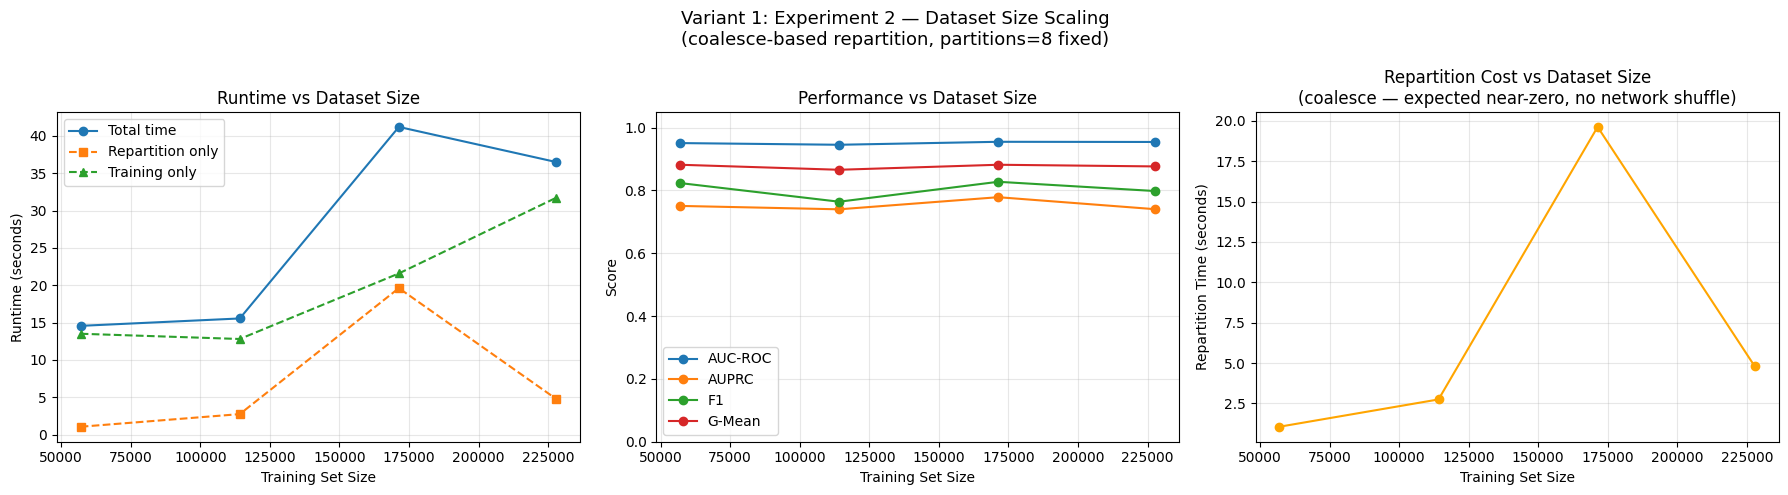


KEY FINDINGS (Dataset Size Scaling):
  Smallest: 56985 samples -> 14.57s, AUC=0.9508
  Largest:  227848 samples -> 36.51s, AUC=0.9544
  Data ratio:    4.00x
  Runtime ratio: 2.51x
  AUC range:     0.0095

Repartition cost breakdown:
  25% data -> repartition=1.06s (7.3% of total time)
  50% data -> repartition=2.75s (17.7% of total time)
  75% data -> repartition=19.62s (47.6% of total time)
  100% data -> repartition=4.79s (13.1% of total time)

Note: Repartition cost should be near-zero and flat across all sizes,
confirming coalesce introduces no network shuffle in Variant 1.


In [0]:
print(f"\n{'Frac':<7} {'Majority':<10} {'Minority':<10} {'Repart(s)':<12} "
      f"{'Train(s)':<10} {'Total(s)':<10} {'AUC':<8} {'AUPRC':<8} "
      f"{'F1':<8} {'GMean':<8}")
print("=" * 100)
 
for r in size_results:
    print(f"{r['size_fraction']:<7.2f} "
          f"{r['n_majority']:<10} {r['n_minority']:<10} "
          f"{r['repart_time_sec']:<12.2f} "
          f"{r['training_time_sec']:<10.2f} "
          f"{r['total_time_sec']:<10.2f} "
          f"{r['auc_roc']:<8.4f} {r['auprc']:<8.4f} "
          f"{r['f1']:<8.4f} {r['gmean']:<8.4f}")
 
import matplotlib.pyplot as plt
import pandas as pd
 
pdf_size = pd.DataFrame(size_results).sort_values("total_train")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Variant 1: Experiment 2 — Dataset Size Scaling\n"
             "(coalesce-based repartition, partitions=8 fixed)",
             fontsize=13)
 
# Plot 1 - Runtime vs dataset size
axes[0].plot(pdf_size["total_train"], pdf_size["total_time_sec"],
             marker="o", label="Total time")
axes[0].plot(pdf_size["total_train"], pdf_size["repart_time_sec"],
             marker="s", linestyle="--", label="Repartition only")
axes[0].plot(pdf_size["total_train"], pdf_size["training_time_sec"],
             marker="^", linestyle="--", label="Training only")
axes[0].set_xlabel("Training Set Size")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Runtime vs Dataset Size")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# Plot 2 - Performance vs dataset size
axes[1].plot(pdf_size["total_train"], pdf_size["auc_roc"],
             marker="o", label="AUC-ROC")
axes[1].plot(pdf_size["total_train"], pdf_size["auprc"],
             marker="o", label="AUPRC")
axes[1].plot(pdf_size["total_train"], pdf_size["f1"],
             marker="o", label="F1")
axes[1].plot(pdf_size["total_train"], pdf_size["gmean"],
             marker="o", label="G-Mean")
axes[1].set_xlabel("Training Set Size")
axes[1].set_ylabel("Score")
axes[1].set_title("Performance vs Dataset Size")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)
 
# Plot 3 - Repartition cost vs dataset size
axes[2].plot(pdf_size["total_train"], pdf_size["repart_time_sec"],
             marker="o", color="orange")
axes[2].set_xlabel("Training Set Size")
axes[2].set_ylabel("Repartition Time (seconds)")
axes[2].set_title("Repartition Cost vs Dataset Size\n"
                  "(coalesce — expected near-zero, no network shuffle)")
axes[2].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()
 
# Key findings
smallest = size_results[0]
largest  = size_results[-1]
 
runtime_ratio = largest["total_time_sec"] / smallest["total_time_sec"]
data_ratio    = largest["total_train"]    / smallest["total_train"]
auc_range     = max(r["auc_roc"] for r in size_results) - \
                min(r["auc_roc"] for r in size_results)
 
print("\nKEY FINDINGS (Dataset Size Scaling):")
print(f"  Smallest: {smallest['total_train']} samples "
      f"-> {smallest['total_time_sec']:.2f}s, AUC={smallest['auc_roc']:.4f}")
print(f"  Largest:  {largest['total_train']} samples "
      f"-> {largest['total_time_sec']:.2f}s, AUC={largest['auc_roc']:.4f}")
print(f"  Data ratio:    {data_ratio:.2f}x")
print(f"  Runtime ratio: {runtime_ratio:.2f}x")
print(f"  AUC range:     {auc_range:.4f}")
print(f"\nRepartition cost breakdown:")
for r in size_results:
    repart_pct = r["repart_time_sec"] / r["total_time_sec"] * 100
    print(f"  {r['size_fraction']:.0%} data -> "
          f"repartition={r['repart_time_sec']:.2f}s "
          f"({repart_pct:.1f}% of total time)")
print(f"\nNote: Repartition cost should be near-zero and flat across all sizes,")
print(f"confirming coalesce introduces no network shuffle in Variant 1.")

**Save Results**

In [0]:
size_results_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant1_size_scaling.parquet")
 
spark.createDataFrame(pd.DataFrame(v1_size_results)) \
     .write.mode("overwrite").parquet(
         "/mnt/2026-group7/results/variant1_size_scaling_summary.parquet")
 
print("\nDataset size scaling results saved:")
print("  /mnt/2026-group7/results/variant1_size_scaling.parquet")
print("  /mnt/2026-group7/results/variant1_size_scaling_summary.parquet")


Dataset size scaling results saved:
  /mnt/2026-group7/results/variant1_size_scaling.parquet
  /mnt/2026-group7/results/variant1_size_scaling_summary.parquet


#### Variant 2 - Dataset Size Scaling 

This experiment studies how Variant 2 behaves as training data size changes.

Purpose:
- measure runtime scaling with increasing data size
- check whether predictive performance is stable across sizes
- observe broadcast cost behaviour as minority pool size changes

Setup:
- both classes sampled proportionally at each fraction
- class ratio preserved approximately across all sizes
- fixed: partitions=8, total trees=80, K=5, MAX_DEPTH=10, threshold=0.5

| Fraction | Approx majority | Approx minority | Total train |
|----------|----------------|-----------------|-------------|
| 25%      | ~56,850        | ~98             | ~56,948     |
| 50%      | ~113,700       | ~197            | ~113,897    |
| 75%      | ~170,550       | ~295            | ~170,845    |
| 100%     | 227,410        | 394             | 227,804     |

Note:
- At 25%, the minority pool is small, so SMOTE with k=5 operates on a thin neighbour pool.
- This is treated as a limitation of the small-data regime, not a flaw in the method.
- The minority broadcast is rebuilt at each fraction to reflect the sampled minority set.
- AUC-ROC and AUPRC are threshold-independent.
- Precision, Recall, F1, Specificity, and G-Mean are reported at threshold 0.5.

In [0]:
# Fix partitions=8, T=10, K=5
# Vary training data size: 25%, 50%, 75%, 100%
# Both classes sampled proportionally — preserves imbalance ratio
# Records runtime, AUC, performance stability, shuffle cost

SIZE_FRACTIONS_V2      = [0.25, 0.50, 0.75, 1.0]
SIZE_EXP_PARTITIONS_V2 = 8
SIZE_EXP_T_V2          = 10
SIZE_EXP_K_V2          = 5
SIZE_EXP_MAX_DEPTH_V2  = 10
SIZE_EXP_THRESHOLD_V2  = 0.5

print("=" * 70)
print("EXPERIMENT 2: DATASET SIZE SCALING")
print("=" * 70)
print(f"Size fractions:  {SIZE_FRACTIONS_V2}")
print(f"Fixed settings:  partitions={SIZE_EXP_PARTITIONS_V2}, "
      f"T={SIZE_EXP_T_V2}, K={SIZE_EXP_K_V2}, max_depth={SIZE_EXP_MAX_DEPTH_V2}")
print(f"Threshold: {SIZE_EXP_THRESHOLD_V2}")
print("=" * 70)

# Full training sets — split by class
full_majority_v2 = train_final_v2b.filter(col("label") == 0).cache()
full_minority_v2 = train_final_v2b.filter(col("label") == 1).cache()

n_full_majority_v2 = full_majority_v2.count()
n_full_minority_v2 = full_minority_v2.count()

print(f"\nFull majority: {n_full_majority_v2}")
print(f"Full minority: {n_full_minority_v2}")

# Expected sizes at each fraction
print(f"\n{'Fraction':<10} {'Approx Majority':<18} {'Approx Minority':<18} {'Total Train'}")
print("-" * 55)
for frac in SIZE_FRACTIONS_V2:
    maj = int(n_full_majority_v2 * frac)
    mn  = int(n_full_minority_v2 * frac)
    print(f"{frac:<10.2f} {maj:<18} {mn:<18} {maj + mn}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

**Runner Function**

In [0]:
# Dataset size scaling runner

def run_variant2_size_experiment(fraction, majority_df, minority_df,
                                  num_partitions=8, T=10, K=5,
                                  max_depth=10, threshold=0.5):
    """
    Run Variant 2 on a proportional sample of training data.
    Minority and majority both sampled at the same fraction.
    Records runtime, shuffle cost, and performance metrics.
    """

    n_majority  = majority_df.count()
    n_minority  = minority_df.count()
    total_train = n_majority + n_minority

    if n_minority <= K:
        raise ValueError(
            f"Minority too small for SMOTE: {n_minority} samples with K={K}"
        )

    # Step 1 — stratified repartition
    # Time the shuffle separately to measure communication cost
    def assign_ids_local(rows):
        for i, row in enumerate(rows):
            yield (int(i % num_partitions), row)

    minority_keyed = minority_df.rdd.mapPartitions(assign_ids_local)
    majority_keyed = majority_df.rdd.mapPartitions(assign_ids_local)
    combined       = minority_keyed.union(majority_keyed)

    shuffle_start = time.time()
    train_repartitioned = combined.partitionBy(num_partitions) \
                                   .map(lambda x: x[1])
    train_repartitioned = spark.createDataFrame(
        train_repartitioned,
        schema=train_final_v2b.schema
    )
    train_repartitioned.cache()
    train_repartitioned.count()
    shuffle_time = round(time.time() - shuffle_start, 2)

    # Step 2 — minority per partition diagnostics
    part_info = train_repartitioned.withColumn("part_id", spark_partition_id())
    minority_per_partition = (
        part_info.filter(col("label") == 1)
        .groupBy("part_id")
        .count()
        .orderBy("part_id")
        .collect()
    )
    part_minority_counts = [int(r["count"]) for r in minority_per_partition]

    # Step 3 — broadcast scalars
    T_bc_size = sc.broadcast(T)
    K_bc_size = sc.broadcast(K)

    # Step 4 — worker function
    def process_partition_size(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier

        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])

        minority = [r for r in rows_list if r["label"] == 1]
        majority = [r for r in rows_list if r["label"] == 0]

        if len(minority) == 0 or len(majority) == 0:
            return iter([])

        # test_features_bc_exp contains plain lists — no .toArray() needed
        t_features = test_features_bc_exp.value
        T_local    = T_bc_size.value
        K_local    = K_bc_size.value
        test_X     = np.array(t_features, dtype=np.float64)

        # Helper — handles both DenseVector and plain list
        def to_numpy(feat):
            if hasattr(feat, 'toArray'):
                return feat.toArray()
            return np.array(feat, dtype=np.float64)

        def smote_partition(minority_samples, k, oversample_rate, rng):
            if len(minority_samples) <= k:
                return []
            n_synthetic = int(len(minority_samples) * oversample_rate)
            synthetic_samples = []
            samples_array = np.array(minority_samples, dtype=np.float64)
            for _ in range(n_synthetic):
                idx               = rng.randint(0, len(minority_samples))
                sample            = samples_array[idx]
                distances         = np.sqrt(np.sum((samples_array - sample) ** 2, axis=1))
                distances[idx]    = np.inf
                neighbour_indices = np.argsort(distances)[:k]
                neighbour_idx     = neighbour_indices[rng.randint(0, len(neighbour_indices))]
                neighbour         = samples_array[neighbour_idx]
                gap               = rng.random()
                synthetic         = sample + gap * (neighbour - sample)
                synthetic_samples.append(synthetic)
            return synthetic_samples

        results = []

        for bag in range(1, T_local + 1):
            bag_seed        = partition_id * 1000 + bag
            rng             = np.random.RandomState(bag_seed)
            oversample_rate = bag * 0.1

            bootstrap_majority = [
                majority[rng.randint(0, len(majority))]
                for _ in range(len(majority))
            ]

            minority_vectors  = [to_numpy(r["features"]) for r in minority]
            synthetic_vectors = smote_partition(
                minority_vectors, k=K_local,
                oversample_rate=oversample_rate, rng=rng
            )

            X_train, y_train = [], []
            for r in bootstrap_majority:
                X_train.append(to_numpy(r["features"]))
                y_train.append(0)
            for r in minority:
                X_train.append(to_numpy(r["features"]))
                y_train.append(1)
            for s in synthetic_vectors:
                X_train.append(s)
                y_train.append(1)

            X_train = np.array(X_train, dtype=np.float64)
            y_train = np.array(y_train)

            dt = DecisionTreeClassifier(max_depth=max_depth, random_state=bag_seed)
            dt.fit(X_train, y_train)

            bag_preds = dt.predict(test_X).tolist()
            results.append((partition_id, bag, [int(p) for p in bag_preds]))

        return iter(results)

    # Step 5 — run and time (excludes shuffle time)
    start_time = time.time()

    preds_raw = (
        train_repartitioned.rdd
        .mapPartitionsWithIndex(process_partition_size)
        .collect()
    )

    training_time = round(time.time() - start_time, 2)
    total_time    = round(shuffle_time + training_time, 2)

    # Cleanup
    train_repartitioned.unpersist()
    T_bc_size.unpersist()
    K_bc_size.unpersist()

    # Step 6 — aggregate and evaluate
    preds_sorted = sorted(preds_raw, key=lambda x: (x[0], x[1]))
    pred_lists   = [x[2] for x in preds_sorted]
    pred_matrix  = np.array(pred_lists, dtype=np.int32)

    n_trees     = pred_matrix.shape[0]
    vote_sums   = pred_matrix.sum(axis=0)
    vote_scores = vote_sums / n_trees
    y_true      = np.array(test_labels_exp)

    auc_roc = roc_auc_score(y_true, vote_scores)
    auprc   = average_precision_score(y_true, vote_scores)

    preds_final = (vote_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_final).ravel()

    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, preds_final)
    gmean       = np.sqrt(recall * specificity)

    return {
        "size_fraction": float(fraction),
        "n_majority": int(n_majority),
        "n_minority": int(n_minority),
        "total_train": int(total_train),
        "num_trees": int(n_trees),
        "shuffle_time_sec": float(shuffle_time),
        "training_time_sec":  float(training_time),
        "total_time_sec": float(total_time),
        "auc_roc": float(auc_roc),
        "auprc": float(auprc),
        "f1": float(f1),
        "gmean": float(gmean),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "minority_per_partition_avg": float(np.mean(part_minority_counts)),
        "minority_per_partition_min": int(min(part_minority_counts)),
        "minority_per_partition_max": int(max(part_minority_counts))
    }


print("Dataset size scaling runner ready.")

size_results_v2 = []

for frac in SIZE_FRACTIONS_V2:
    print(f"\n{'-' * 55}")
    print(f"Running at {frac:.0%} of training data...")
    print(f"{'-' * 55}")

    if frac >= 1.0:
        maj_subset = full_majority_v2
        min_subset = full_minority_v2
    else:
        maj_subset = full_majority_v2.sample(
            withReplacement=False, fraction=frac, seed=42).cache()
        min_subset = full_minority_v2.sample(
            withReplacement=False, fraction=frac, seed=42).cache()
        _ = maj_subset.count()
        _ = min_subset.count()

    result = run_variant2_size_experiment(
        fraction=frac,
        majority_df=maj_subset,
        minority_df=min_subset,
        num_partitions=SIZE_EXP_PARTITIONS_V2,
        T=SIZE_EXP_T_V2,
        K=SIZE_EXP_K_V2,
        max_depth=SIZE_EXP_MAX_DEPTH_V2,
        threshold=SIZE_EXP_THRESHOLD_V2
    )

    size_results_v2.append(result)

    print(f"Majority:{result['n_majority']}")
    print(f"Minority: {result['n_minority']}")
    print(f"Shuffle time: {result['shuffle_time_sec']:.2f} sec")
    print(f"Training time: {result['training_time_sec']:.2f} sec")
    print(f"Total time:{result['total_time_sec']:.2f} sec")
    print(f"AUC-ROC:{result['auc_roc']:.4f}")
    print(f"AUPRC: {result['auprc']:.4f}")
    print(f"F1:{result['f1']:.4f}")
    print(f"G-Mean:{result['gmean']:.4f}")
    print(f"Minority/part: avg={result['minority_per_partition_avg']:.0f}, "
          f"min={result['minority_per_partition_min']}, "
          f"max={result['minority_per_partition_max']}")

    if frac < 1.0:
        maj_subset.unpersist()
        min_subset.unpersist()

size_results_v2 = sorted(size_results_v2, key=lambda r: r["size_fraction"])
size_results_v2_df = spark.createDataFrame(pd.DataFrame(size_results_v2))
display(size_results_v2_df.orderBy("size_fraction"))

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

**Results Summary and Plots**

In [0]:
# Dataset size scaling results summary and plots

print(f"\n{'Frac':<7} {'Majority':<10} {'Minority':<10} {'Shuffle(s)':<12} "
      f"{'Train(s)':<10} {'Total(s)':<10} {'AUC':<8} {'AUPRC':<8} "
      f"{'F1':<8} {'GMean':<8}")
print("=" * 100)

for r in size_results_v2:
    print(f"{r['size_fraction']:<7.2f} "
          f"{r['n_majority']:<10} {r['n_minority']:<10} "
          f"{r['shuffle_time_sec']:<12.2f} "
          f"{r['training_time_sec']:<10.2f} "
          f"{r['total_time_sec']:<10.2f} "
          f"{r['auc_roc']:<8.4f} {r['auprc']:<8.4f} "
          f"{r['f1']:<8.4f} {r['gmean']:<8.4f}")

# Plots
pdf_size_v2 = pd.DataFrame(size_results_v2).sort_values("total_train")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Runtime vs dataset size
axes[0].plot(pdf_size_v2["total_train"], pdf_size_v2["total_time_sec"],
             marker="o", label="Total time")
axes[0].plot(pdf_size_v2["total_train"], pdf_size_v2["shuffle_time_sec"],
             marker="s", linestyle="--", label="Shuffle only")
axes[0].plot(pdf_size_v2["total_train"], pdf_size_v2["training_time_sec"],
             marker="^", linestyle="--", label="Training only")
axes[0].set_xlabel("Training Set Size")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Variant 2: Runtime vs Dataset Size")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Performance vs dataset size
axes[1].plot(pdf_size_v2["total_train"], pdf_size_v2["auc_roc"],
             marker="o", label="AUC-ROC")
axes[1].plot(pdf_size_v2["total_train"], pdf_size_v2["auprc"],
             marker="o", label="AUPRC")
axes[1].plot(pdf_size_v2["total_train"], pdf_size_v2["f1"],
             marker="o", label="F1")
axes[1].plot(pdf_size_v2["total_train"], pdf_size_v2["gmean"],
             marker="o", label="G-Mean")
axes[1].set_xlabel("Training Set Size")
axes[1].set_ylabel("Score")
axes[1].set_title("Variant 2: Performance vs Dataset Size")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

# Plot 3 — Shuffle cost vs dataset size
axes[2].plot(pdf_size_v2["total_train"], pdf_size_v2["shuffle_time_sec"], marker="o")
axes[2].set_xlabel("Training Set Size")
axes[2].set_ylabel("Shuffle Time (seconds)")
axes[2].set_title("Variant 2: Shuffle Cost vs Dataset Size\n(One-time stratified repartition)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key findings
smallest_v2 = size_results_v2[0]
largest_v2  = size_results_v2[-1]

runtime_ratio_v2 = largest_v2["total_time_sec"] / smallest_v2["total_time_sec"]
data_ratio_v2 = largest_v2["total_train"]     / smallest_v2["total_train"]
auc_range_v2 = max(r["auc_roc"] for r in size_results_v2) - \
                   min(r["auc_roc"] for r in size_results_v2)

print("\nKEY FINDINGS (Dataset Size Scaling):")
print(f"  Smallest: {smallest_v2['total_train']} samples "
      f"-> {smallest_v2['total_time_sec']:.2f}s, AUC={smallest_v2['auc_roc']:.4f}")
print(f"  Largest:  {largest_v2['total_train']} samples "
      f"-> {largest_v2['total_time_sec']:.2f}s, AUC={largest_v2['auc_roc']:.4f}")
print(f"  Data ratio:    {data_ratio_v2:.2f}x")
print(f"  Runtime ratio: {runtime_ratio_v2:.2f}x")
print(f"  AUC range:     {auc_range_v2:.4f}")
print(f"\nShuffle cost breakdown:")
for r in size_results_v2:
    shuffle_pct = r["shuffle_time_sec"] / r["total_time_sec"] * 100
    print(f"  {r['size_fraction']:.0%} data -> "
          f"shuffle={r['shuffle_time_sec']:.2f}s "
          f"({shuffle_pct:.1f}% of total time)")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

**Save Results**

In [0]:
# Save size scaling results to shared storage

size_results_v2_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant2_size_scaling.parquet")

print("Size scaling results saved:")
print("  /mnt/2026-group7/results/variant2_size_scaling.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

#### Variant 3 — Dataset Size Scaling 


Setup:

both classes sampled proportionally at each fraction
class ratio preserved approximately across all sizes
fixed: partitions=8, total trees=80, K=5, MAX_DEPTH=10, threshold=0.5

In [0]:
# DATASET SIZE SCALING — SETUP

SIZE_FRACTIONS_v3 = [0.25, 0.50, 0.75, 1.0]
SIZE_EXP_PARTITIONS_v3 = 8
SIZE_EXP_T_v3 = 10
SIZE_EXP_K_v3 = 5
SIZE_EXP_MAX_DEPTH_v3 = 10
SIZE_EXP_THRESHOLD_v3 = 0.5

print("EXPERIMENT: DATASET SIZE SCALING (PROPORTIONAL SAMPLING)")
print(f"Size fractions:  {SIZE_FRACTIONS_v3}")
print(
    f"Fixed settings:  partitions={SIZE_EXP_PARTITIONS_v3}, "
    f"T={SIZE_EXP_T_v3}, K={SIZE_EXP_K_v3}, max_depth={SIZE_EXP_MAX_DEPTH_v3}"
)
print(f"Threshold:       {SIZE_EXP_THRESHOLD_v3}")

# Full training sets
full_majority_v3 = train_assembled_v3.filter(F.col("label") == 0).cache()
full_minority_v3 = train_assembled_v3.filter(F.col("label") == 1).cache()

n_full_majority_v3 = full_majority_v3.count()
n_full_minority_v3 = full_minority_v3.count()

print(f"Full majority: {n_full_majority_v3}")
print(f"Full minority: {n_full_minority_v3}")

# Reuse test data
try:
    test_features_list_exp_v3
    test_labels_exp_v3
except NameError:
    test_rows_v3 = test_assembled_v3.select("features", "label").collect()
    test_features_list_exp_v3 = [row["features"].toArray().tolist() for row in test_rows_v3]
    test_labels_exp_v3 = np.array([int(row["label"]) for row in test_rows_v3], dtype=np.int32)

test_bc_size_v3 = spark.sparkContext.broadcast(test_features_list_exp_v3)

print(f"Test samples: {len(test_labels_exp_v3)}")
print("Setup ready.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# RUNNER FUNCTION

def run_variant3_size_experiment(
    fraction,
    majority_df,
    minority_df,
    num_partitions=8,
    T=10,
    K=5,
    max_depth=10,
    threshold=0.5
):
    """
    Run Variant 3 on given majority + minority subsets.
    Minority is re-broadcast for each run to match the sampled size.
    """

    n_majority_v3 = majority_df.count()
    n_minority_v3 = minority_df.count()
    total_train_v3 = n_majority_v3 + n_minority_v3

    if n_minority_v3 <= K:
        raise ValueError(
            f"Minority subset too small for SMOTE: {n_minority_v3} samples with K={K}"
        )

    minority_rows_v3 = minority_df.select("features").collect()
    minority_np_v3 = np.array(
        [row["features"].toArray() for row in minority_rows_v3],
        dtype=np.float64
    )
    minority_bc_run_v3 = spark.sparkContext.broadcast(minority_np_v3)

    majority_repartitioned_v3 = majority_df.repartition(num_partitions).cache()
    _ = majority_repartitioned_v3.count()

    part_dist_v3 = (
        majority_repartitioned_v3
        .withColumn("pid", F.spark_partition_id())
        .groupBy("pid")
        .count()
        .orderBy("pid")
        .collect()
    )
    part_sizes_v3 = [int(row["count"]) for row in part_dist_v3]

    T_bc_run_v3 = spark.sparkContext.broadcast(T)
    K_bc_run_v3 = spark.sparkContext.broadcast(K)

    def process_partition_size_v3(partition_id, rows):
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier

        rows_list = list(rows)
        if len(rows_list) == 0:
            return iter([])

        local_majority_v3 = np.array(
            [row["features"].toArray() for row in rows_list],
            dtype=np.float64
        )
        n_local_majority_v3 = local_majority_v3.shape[0]

        global_minority_v3 = np.array(minority_bc_run_v3.value, dtype=np.float64)
        test_X_v3 = np.array(test_bc_size_v3.value, dtype=np.float64)
        T_local_v3 = T_bc_run_v3.value
        K_local_v3 = K_bc_run_v3.value

        n_min_v3, n_features_v3 = global_minority_v3.shape
        eff_k_v3 = min(K_local_v3, n_min_v3 - 1)

        if n_min_v3 <= 1 or eff_k_v3 <= 0:
            return iter([])

        X_sq_v3 = np.sum(global_minority_v3 ** 2, axis=1, keepdims=True)
        cross_v3 = global_minority_v3 @ global_minority_v3.T
        dist_sq_v3 = np.clip(X_sq_v3 + X_sq_v3.T - 2 * cross_v3, 0.0, None)
        np.fill_diagonal(dist_sq_v3, np.inf)
        knn_indices_v3 = np.argsort(dist_sq_v3, axis=1)[:, :eff_k_v3]

        def smote_worker_v3(minority_np, knn_indices, n_synthetic, seed):
            n_m, n_f = minority_np.shape

            if n_synthetic <= 0 or n_m == 0:
                return np.empty((0, n_f), dtype=np.float64)

            if n_m == 1:
                return np.repeat(minority_np, repeats=n_synthetic, axis=0)

            rng = np.random.RandomState(seed)
            synthetic = np.zeros((n_synthetic, n_f), dtype=np.float64)

            for i in range(n_synthetic):
                seed_idx = rng.randint(0, n_m)
                nn_choice = rng.randint(0, knn_indices.shape[1])
                neighbour_idx = knn_indices[seed_idx, nn_choice]
                lam = rng.random()

                synthetic[i] = (
                    minority_np[seed_idx]
                    + lam * (minority_np[neighbour_idx] - minority_np[seed_idx])
                )

            return synthetic

        results_v3 = []

        for bag in range(1, T_local_v3 + 1):
            oversample_rate_v3 = bag * 0.1
            bag_seed_v3 = partition_id * 1000 + bag
            rng_v3 = np.random.RandomState(bag_seed_v3)

            bootstrap_idx_v3 = rng_v3.randint(0, n_local_majority_v3, size=n_local_majority_v3)
            majority_bootstrap_v3 = local_majority_v3[bootstrap_idx_v3]
            n_maj_in_bag_v3 = majority_bootstrap_v3.shape[0]

            n_resampled_v3 = min(int(oversample_rate_v3 * n_maj_in_bag_v3), n_maj_in_bag_v3)
            n_synthetic_v3 = n_maj_in_bag_v3 - n_resampled_v3

            if n_resampled_v3 > 0:
                resample_idx_v3 = rng_v3.randint(0, n_min_v3, size=n_resampled_v3)
                minority_resampled_v3 = global_minority_v3[resample_idx_v3]
            else:
                minority_resampled_v3 = np.empty((0, n_features_v3), dtype=np.float64)

            if n_synthetic_v3 > 0:
                minority_synthetic_v3 = smote_worker_v3(
                    global_minority_v3,
                    knn_indices_v3,
                    n_synthetic_v3,
                    seed=bag_seed_v3 + 500
                )
            else:
                minority_synthetic_v3 = np.empty((0, n_features_v3), dtype=np.float64)

            X_train_v3 = np.vstack([majority_bootstrap_v3, minority_resampled_v3, minority_synthetic_v3])
            y_train_v3 = np.concatenate([
                np.zeros(n_maj_in_bag_v3, dtype=np.int32),
                np.ones(len(minority_resampled_v3), dtype=np.int32),
                np.ones(len(minority_synthetic_v3), dtype=np.int32)
            ])

            clf_v3 = DecisionTreeClassifier(max_depth=max_depth, random_state=bag_seed_v3)
            clf_v3.fit(X_train_v3, y_train_v3)

            bag_preds_v3 = clf_v3.predict(test_X_v3).astype(int).tolist()
            results_v3.append((partition_id, bag, bag_preds_v3))

        return iter(results_v3)

    start_time_v3 = time.time()

    preds_raw_v3 = (
        majority_repartitioned_v3.rdd
        .mapPartitionsWithIndex(process_partition_size_v3)
        .collect()
    )

    runtime_sec_v3 = round(time.time() - start_time_v3, 2)

    majority_repartitioned_v3.unpersist()
    minority_bc_run_v3.unpersist()
    T_bc_run_v3.unpersist()
    K_bc_run_v3.unpersist()

    preds_sorted_v3 = sorted(preds_raw_v3, key=lambda x: (x[0], x[1]))
    pred_lists_v3 = [x[2] for x in preds_sorted_v3]

    if len(pred_lists_v3) == 0:
        raise ValueError(f"No predictions returned for fraction={fraction}")

    pred_matrix_v3 = np.array(pred_lists_v3, dtype=np.int32)

    n_trees_v3 = pred_matrix_v3.shape[0]
    vote_sums_v3 = pred_matrix_v3.sum(axis=0)
    vote_scores_v3 = vote_sums_v3 / n_trees_v3

    auc_roc_v3 = roc_auc_score(test_labels_exp_v3, vote_scores_v3)
    auprc_v3 = average_precision_score(test_labels_exp_v3, vote_scores_v3)

    preds_final_v3 = (vote_scores_v3 > threshold).astype(int)
    tn_v3, fp_v3, fn_v3, tp_v3 = confusion_matrix(test_labels_exp_v3, preds_final_v3).ravel()

    precision_v3 = tp_v3 / (tp_v3 + fp_v3) if (tp_v3 + fp_v3) > 0 else 0.0
    recall_v3 = tp_v3 / (tp_v3 + fn_v3) if (tp_v3 + fn_v3) > 0 else 0.0
    specificity_v3 = tn_v3 / (tn_v3 + fp_v3) if (tn_v3 + fp_v3) > 0 else 0.0
    f1_final_v3 = f1_score(test_labels_exp_v3, preds_final_v3)
    gmean_v3 = np.sqrt(recall_v3 * specificity_v3)

    return {
        "size_fraction": float(fraction),
        "n_majority": int(n_majority_v3),
        "n_minority": int(n_minority_v3),
        "total_train": int(total_train_v3),
        "num_trees": int(n_trees_v3),
        "runtime_sec": float(runtime_sec_v3),
        "auc_roc": float(auc_roc_v3),
        "auprc": float(auprc_v3),
        "threshold": float(threshold),
        "precision": float(precision_v3),
        "recall": float(recall_v3),
        "f1": float(f1_final_v3),
        "specificity": float(specificity_v3),
        "gmean": float(gmean_v3),
        "tp": int(tp_v3),
        "fp": int(fp_v3),
        "fn": int(fn_v3),
        "tn": int(tn_v3),
        "minority_broadcast_kb": float(minority_np_v3.nbytes / 1024),
        "maj_per_partition_avg": float(np.mean(part_sizes_v3))
    }

print("Dataset size scaling runner ready.")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# RUN SIZE SCALING EXPERIMENT

v3_size_results = []

for frac in SIZE_FRACTIONS_v3:
    print(f"\n{'-' * 55}")
    print(f"Running at {frac:.0%} of training data...")
    print(f"{'-' * 55}")

    if frac >= 1.0:
        maj_subset = full_majority_v3
        min_subset = full_minority_v3
    else:
        maj_subset = full_majority_v3.sample(withReplacement=False, fraction=frac, seed=42).cache()
        min_subset = full_minority_v3.sample(withReplacement=False, fraction=frac, seed=42).cache()
        _ = maj_subset.count()
        _ = min_subset.count()

    result = run_variant3_size_experiment(
        fraction=frac,
        majority_df=maj_subset,
        minority_df=min_subset,
        num_partitions=SIZE_EXP_PARTITIONS_v3,
        T=SIZE_EXP_T_v3,
        K=SIZE_EXP_K_v3,
        max_depth=SIZE_EXP_MAX_DEPTH_v3,
        threshold=SIZE_EXP_THRESHOLD_v3
    )

    v3_size_results.append(result)

    print(f"Majority: {result['n_majority']}")
    print(f"Minority: {result['n_minority']} (broadcast: {result['minority_broadcast_kb']:.1f} KB)")
    print(f"Trees: {result['num_trees']}")
    print(f"Runtime: {result['runtime_sec']:.2f} sec")
    print(f"AUC-ROC: {result['auc_roc']:.4f}")
    print(f"AUPRC: {result['auprc']:.4f}")
    print(f"Threshold: {result['threshold']:.1f}")
    print(f"Precision@0.5: {result['precision']:.4f}")
    print(f"Recall@0.5:{result['recall']:.4f}")
    print(f"F1@0.5:{result['f1']:.4f}")
    print(f"GMean@0.5:{result['gmean']:.4f}")

    if frac < 1.0:
        maj_subset.unpersist()
        min_subset.unpersist()

v3_size_results = sorted(v3_size_results, key=lambda r: r["size_fraction"])

v3_size_results_df = spark.createDataFrame(pd.DataFrame(v3_size_results))
display(v3_size_results_df.orderBy("size_fraction"))

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# RESULTS SUMMARY

print(f"\n{'Frac':<7} {'Majority':<10} {'Minority':<10} {'Bcast(KB)':<10} "
      f"{'Time(s)':<10} {'AUC':<8} {'AUPRC':<8} {'Prec@0.5':<10} {'Recall@0.5':<12} {'F1@0.5':<8} {'GMean@0.5':<12}")
print("=" * 115)

for r in v3_size_results:
    print(
        f"{r['size_fraction']:<7.2f} "
        f"{r['n_majority']:<10} "
        f"{r['n_minority']:<10} "
        f"{r['minority_broadcast_kb']:<10.1f} "
        f"{r['runtime_sec']:<10.2f} "
        f"{r['auc_roc']:<8.4f} "
        f"{r['auprc']:<8.4f} "
        f"{r['precision']:<10.4f} "
        f"{r['recall']:<12.4f} "
        f"{r['f1']:<8.4f} "
        f"{r['gmean']:<12.4f}"
    )

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# PLOTS
pdf_size_v3 = pd.DataFrame(v3_size_results).sort_values("total_train")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(pdf_size_v3["total_train"], pdf_size_v3["runtime_sec"], marker="o")
axes[0].set_xlabel("Training Set Size")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Variant 3: Runtime vs Dataset Size")
axes[0].grid(True, alpha=0.3)

axes[1].plot(pdf_size_v3["total_train"], pdf_size_v3["auc_roc"], marker="o", label="AUC-ROC")
axes[1].plot(pdf_size_v3["total_train"], pdf_size_v3["auprc"],   marker="o", label="AUPRC")
axes[1].plot(pdf_size_v3["total_train"], pdf_size_v3["f1"],      marker="o", label="F1 @ 0.5")
axes[1].plot(pdf_size_v3["total_train"], pdf_size_v3["recall"],  marker="o", label="Recall @ 0.5")
axes[1].set_xlabel("Training Set Size")
axes[1].set_ylabel("Score")
axes[1].set_title("Variant 3: Performance vs Dataset Size")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1.05)

axes[2].plot(pdf_size_v3["total_train"], pdf_size_v3["minority_broadcast_kb"], marker="o")
axes[2].set_xlabel("Training Set Size")
axes[2].set_ylabel("Minority Broadcast Size (KB)")
axes[2].set_title("Variant 3: Broadcast Cost vs Dataset Size")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# SAVE SIZE SCALING RESULTS
v3_size_results_df = spark.createDataFrame(pd.DataFrame(v3_size_results))
v3_size_results_df.write.mode("overwrite").parquet(
    "/mnt/2026-group7/results/variant3_size_scaling.parquet")

print("Size scaling results saved:")
print("  /mnt/2026-group7/results/variant3_size_scaling.parquet")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

In [0]:
# KEY FINDINGS

smallest_v3 = v3_size_results[0]
largest_v3  = v3_size_results[-1]

auc_range_v3     = max(r["auc_roc"] for r in v3_size_results) - min(r["auc_roc"] for r in v3_size_results)
runtime_ratio_v3 = largest_v3["runtime_sec"] / smallest_v3["runtime_sec"] if smallest_v3["runtime_sec"] > 0 else 0
data_ratio_v3    = largest_v3["total_train"] / smallest_v3["total_train"]
broadcast_range_v3 = (
    max(r["minority_broadcast_kb"] for r in v3_size_results) -
    min(r["minority_broadcast_kb"] for r in v3_size_results)
)

print("KEY FINDINGS (Dataset Size Scaling):")
print(
    f"  Smallest: {smallest_v3['total_train']} samples -> {smallest_v3['runtime_sec']:.2f}s, "
    f"AUC={smallest_v3['auc_roc']:.4f}"
)
print(
    f"  Largest:  {largest_v3['total_train']} samples -> {largest_v3['runtime_sec']:.2f}s, "
    f"AUC={largest_v3['auc_roc']:.4f}"
)
print(f"  Data ratio: {data_ratio_v3:.2f}x")
print(f"  Runtime ratio: {runtime_ratio_v3:.2f}x")
print(f"  AUC range: {auc_range_v3:.4f}")
print(f"  Broadcast size range: {broadcast_range_v3:.1f} KB")

print("\nBroadcast cost scaling:")
for r in v3_size_results:
    print(
        f"  {r['size_fraction']:.0%} data -> minority={r['n_minority']}, "
        f"broadcast={r['minority_broadcast_kb']:.1f} KB"
    )

print("\nNote:")
print("  Broadcast cost scales roughly linearly with minority class size.")
print(
    f"  At 25% ({v3_size_results[0]['n_minority']} minority samples), SMOTE operates "
    "on a thinner neighbour pool, which may reduce synthetic quality."
)
print(
    "  Runtime mainly scales with majority size because that determines "
    "per-tree training cost, while minority broadcast remains small at all sizes."
)

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

## Section 8 Cross-Variant Results Summary


Aggregates results from all variants for final comparison.
Run this section **after** all variant sections have been executed.


### 8.1 Load the Results

In [0]:
# Section 8 — Cross-variant results loading
# Loads all variant summaries and experiment results from Parquet

#Loading V1 summary
v1_summary_loaded = spark.read.parquet("/mnt/2026-group7/results/variant1_summary.parquet")
v1_summary = v1_summary_loaded.collect()[0].asDict()

# Load V2A summary
v2a_summary_loaded = spark.read.parquet("/mnt/2026-group7/results/variant2_summary_A.parquet")
v2a_summary = v2a_summary_loaded.collect()[0].asDict()


# Load V2B summary
v2b_summary_loaded = spark.read.parquet("/mnt/2026-group7/results/variant2_summary_B.parquet")
v2b_summary = v2b_summary_loaded.collect()[0].asDict()

# Cross-variant classification performance comparison
all_summaries = [
    v1_summary,
    v2a_summary,
    v2b_summary,
    v3_summary
]
summary_df = pd.DataFrame(all_summaries)
print(summary_df.to_string(index=False))


# Load V2B experiment results from Parquet
v2b_partition_df = spark.read.parquet(
    "/mnt/2026-group7/results/variant2_partition_sensitivity_c.parquet"
)
v2b_size_df = spark.read.parquet(
    "/mnt/2026-group7/results/variant2_size_scaling.parquet"
)

v2b_partition_results = [
    {
        "num_partitions": r["num_partitions"],
        "runtime":r["runtime_sec"],
        "auc":r["auc_roc"],
        "f1":r["f1"],
        "gmean":r["gmean"],
        "auprc":r["auprc"],
    }
    for r in v2b_partition_df.collect()
]

v2b_size_results = [
    {
        "fraction": r["size_fraction"],
        "runtime": r["total_time_sec"],
        "shuffle_time": r["shuffle_time_sec"],
        "training_time": r["training_time_sec"],
        "auc":r["auc_roc"],
        "f1": r["f1"],
        "gmean":r["gmean"],
        "auprc":r["auprc"],
    }
    for r in v2b_size_df.collect()
]

print(f"Loaded {len(v2b_partition_results)} V2B partition results")
print(f"Loaded {len(v2b_size_results)} V2B size results")


# Load V3 experiment results from Parquet
v3_partition_df = spark.read.parquet(
    "/mnt/2026-group7/results/variant3_partition_sensitivity_c.parquet"
)
v3_size_df = spark.read.parquet(
    "/mnt/2026-group7/results/variant3_size_scaling.parquet"
)

v3_partition_results = [
    {
        "num_partitions": int(r["num_partitions"]),
        "runtime":float(r["runtime_sec"]),
        "auc":float(r["auc_roc"]),
        "f1":float(r["f1"]),
        "gmean":float(r["gmean"]),
        "auprc":float(r["auprc"]),
        "precision":float(r["precision"]),
        "recall":float(r["recall"]),
        "specificity":float(r["specificity"]),
    }
    for r in v3_partition_df.collect()
]

v3_size_results_cross = [
    {
        "fraction":float(r["size_fraction"]),
        "runtime":float(r["runtime_sec"]),      # V3 column name
        "shuffle_time": 0.0,                          # V3 has no shuffle zero for plot compatibility
        "training_time": float(r["runtime_sec"]),     # entire runtime is training for V3
        "auc_roc":float(r["auc_roc"]),
        "f1":float(r["f1"]),
        "gmean":float(r["gmean"]),
        "auprc":float(r["auprc"]),
        "precision":float(r["precision"]),
        "recall":float(r["recall"]),
        "specificity":  float(r["specificity"]),
    }
    for r in v3_size_df.collect()
]

v3_pdf = pd.DataFrame(v3_partition_results).sort_values("num_partitions")
v3_size_pdf = pd.DataFrame(v3_size_results_cross).sort_values("fraction")

print(f"Loaded {len(v3_partition_results)} V3 partition results")
print(f"Loaded {len(v3_size_results_cross)} V3 size results")


# V1 results from parquet

v1_partition_df = spark.read.parquet(
    "/mnt/2026-group7/results/variant1_partition_sensitivity_c.parquet"
)
v1_size_df = spark.read.parquet(
    "/mnt/2026-group7/results/variant1_size_scaling.parquet"
)

v1_partition_results_cross = [
    {
        "num_partitions": int(r["num_partitions"]),
        "runtime": float(r["runtime_sec"]),
        "auc": float(r["auc_roc"]),
        "f1": float(r["f1"]),
        "gmean": float(r["gmean"]),
        "auprc": float(r["auprc"]),
        "precision": float(r["precision"]),
        "recall": float(r["recall"]),
        "specificity": float(r["specificity"]),
    }
    for r in v1_partition_df.collect()
]

v1_size_results_cross = [
    {
        "fraction": float(r["size_fraction"]),
        "runtime": float(r["total_time_sec"]),
        "shuffle_time": 0.0,                          # V1 uses coalesce — zero shuffle cost
        "training_time": float(r["training_time_sec"]),
        "auc_roc": float(r["auc_roc"]),
        "f1": float(r["f1"]),
        "gmean": float(r["gmean"]),
        "auprc": float(r["auprc"]),
        "precision": float(r["precision"]),
        "recall": float(r["recall"]),
        "specificity": float(r["specificity"]),
    }
    for r in v1_size_df.collect()
]

v1_pdf      = pd.DataFrame(v1_partition_results_cross).sort_values("num_partitions")
v1_size_pdf = pd.DataFrame(v1_size_results_cross).sort_values("fraction")

print(f"Loaded {len(v1_partition_results_cross)} V1 partition results")
print(f"Loaded {len(v1_size_results_cross)} V1 size results")
    

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

### 8.2 Repartitioning Strategy Comparison 

Variant 2A vs Variant 2B

In [0]:
# 8.2 V2A vs V2B Comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 — Classification metrics bar chart
metrics       = ["auc_roc", "auprc", "f1", "gmean"]
metric_labels = ["AUC-ROC", "AUPRC", "F1", "G-Mean"]
x     = np.arange(len(metrics))
width = 0.35

v2a_vals = [v2a_summary[m] for m in metrics]
v2b_vals = [v2b_summary[m] for m in metrics]

axes[0].bar(x - width/2, v2a_vals, width, label="V2A - sortBy")
axes[0].bar(x + width/2, v2b_vals, width, label="V2B - mapPartitions")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Score")
axes[0].set_title("V2A vs V2B: Classification Performance")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Number of shuffles (design comparison)
axes[1].bar(["V2A - sortBy", "V2B - mapPartitions"], [2, 1],
            color=["steelblue", "darkorange"], width=0.4)
axes[1].set_ylabel("Number of Global Shuffles")
axes[1].set_title("V2A vs V2B: Shuffle Cost")
axes[1].set_ylim(0, 3)
for i, v in enumerate([2, 1]):
    axes[1].text(i, v + 0.05, str(v), ha="center", fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Metric':<12} {'V2A':>10} {'V2B':>10} {'Diff':>10}")
print("=" * 45)
for m, label in zip(metrics, metric_labels):
    diff = v2b_summary[m] - v2a_summary[m]
    print(f"{label:<12} {v2a_summary[m]:>10.4f} {v2b_summary[m]:>10.4f} {diff:>+10.4f}")
print(f"\n{'Shuffles':<12} {'2':>10} {'1':>10}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

### 8.3 Cross-variant Classification Performance

Variant 1 vs Variant 2B vs Variant 3

In [0]:
# Cross-variant classification performance bar chart
metrics       = ["auc_roc", "auprc", "f1", "gmean"]
metric_labels = ["AUC-ROC", "AUPRC", "F1", "G-Mean"]
x     = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, s in enumerate(all_summaries):
    vals = [s[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=s["variant"])

ax.set_xticks(x + width * (len(all_summaries) - 1) / 2)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Cross-Variant Classification Performance")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

### 8.4 Partition Sensitivity

- The 3-panel overlay — V1, V2B, V3 runtime + speedup + AUC vs partitions
- Compare how each variant scales with parallelism

In [0]:
# Cross-variant partition scaling comparison

v1_pdf = pd.DataFrame(v1_partition_results).sort_values("num_partitions")
v2b_pdf = pd.DataFrame(v2b_partition_results).sort_values("num_partitions")
v3_pdf  = pd.DataFrame(v3_partition_results).sort_values("num_partitions")


variants_partition = [
    (v1_pdf,  "V1 - Local SMOTE Bagging"),
    (v2b_pdf, "V2B - mapPartitions"),
    (v3_pdf,  "V3 - Global Broadcast"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for pdf, label in variants_partition:
    baseline_rt = pdf["runtime"].iloc[0]

    # Plot 1 — Runtime
    axes[0].plot(pdf["num_partitions"], pdf["runtime"], marker="o", label=label)

    # Plot 2 — Speedup
    axes[1].plot(pdf["num_partitions"], baseline_rt / pdf["runtime"],
                 marker="o", label=label)

    # Plot 3 — AUC — use "auc" for v2b, "auc_roc" for v3
    auc_col = "auc" if "auc" in pdf.columns else "auc_roc"
    axes[2].plot(pdf["num_partitions"], pdf[auc_col], marker="o", label=label)

# Ideal speedup line
base_parts = v2b_pdf["num_partitions"]
axes[1].plot(base_parts, base_parts / base_parts.iloc[0],
             linestyle="--", alpha=0.5, color="gray", label="Ideal linear")

axes[0].set_xlabel("Number of Partitions"); axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Cross-Variant: Runtime vs Partition Count")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Number of Partitions"); axes[1].set_ylabel("Speed-up (relative to 2 partitions)")
axes[1].set_title("Cross-Variant: Speed-up vs Partition Count")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel("Number of Partitions"); axes[2].set_ylabel("AUC-ROC")
axes[2].set_title("Cross-Variant: AUC-ROC vs Partition Count")
axes[2].set_ylim(0, 1.05); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

#### Cross-Variant Partition Sensitivity Summary

In [0]:
print("Cross-Variant Partition Sensitivity Summary:")
print("=" * 60)
for pdf, label in variants_partition:
    auc_col = "auc" if "auc" in pdf.columns else "auc_roc"
    baseline_rt = pdf["runtime"].iloc[0]
    fastest = pdf.loc[pdf["runtime"].idxmin()]
    slowest = pdf.loc[pdf["runtime"].idxmax()]
    max_speedup = baseline_rt / pdf["runtime"].min()
    
    print(f"\n{label}:")
    print(f"  Partitions tested: {sorted(pdf['num_partitions'].tolist())}")
    print(f"  Slowest: {slowest['runtime']:.2f}s @ {int(slowest['num_partitions'])} partitions")
    print(f"  Fastest: {fastest['runtime']:.2f}s @ {int(fastest['num_partitions'])} partitions")
    print(f"  Max speed-up: {max_speedup:.2f}x")
    print(f"  AUC range: {pdf[auc_col].max():.4f} (max) -> {pdf[auc_col].min():.4f} (min)")
    print(f"  AUC drop: {abs(pdf[auc_col].max() - pdf[auc_col].min()):.4f}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

### 8.5 Dataset Size Scaling

- The 3-panel overlay — V1, V2B, V3 runtime + AUC + shuffle cost vs dataset fraction
- Compare how each variant handles growing data

In [0]:
# Cross-variant dataset size scaling comparison

v1_size_pdf = pd.DataFrame(v1_size_results_cross).sort_values("fraction")
v2b_size_pdf = pd.DataFrame(v2b_size_results).sort_values("fraction")
v3_size_pdf  = pd.DataFrame(v3_size_results_cross).sort_values("fraction")

variants_size = [
    (v1_size_pdf, "V1 - Local SMOTE Bagging"),
    (v2b_size_pdf, "V2B - mapPartitions"),
    (v3_size_pdf,  "V3 - Global Broadcast"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for pdf, label in variants_size:
    # Plot 1 - Total runtime vs dataset size
    axes[0].plot(pdf["fraction"], pdf["runtime"], marker="o", label=label)

    # Plot 2 - AUC vs dataset size — handle both auc and auc_roc column names
    auc_col = "auc" if "auc" in pdf.columns else "auc_roc"
    axes[1].plot(pdf["fraction"], pdf[auc_col], marker="o", label=label)

    # Plot 3 - Shuffle cost vs dataset size
    axes[2].plot(pdf["fraction"], pdf["shuffle_time"], marker="o", label=label)

axes[0].set_xlabel("Dataset Fraction"); axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Cross-Variant: Runtime vs Dataset Size")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Dataset Fraction"); axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("Cross-Variant: AUC-ROC vs Dataset Size")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel("Dataset Fraction"); axes[2].set_ylabel("Shuffle Time (seconds)")
axes[2].set_title("Cross-Variant: Shuffle Cost vs Dataset Size")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage

#### Cross-Variant Dataset Size Scaling Summary

In [0]:
print("Cross-Variant Dataset Size Scaling Summary:")
print("=" * 60)
for pdf, label in variants_size:
    auc_col = "auc" if "auc" in pdf.columns else "auc_roc"
    smallest = pdf.iloc[0]
    largest = pdf.iloc[-1]
    print(f"\n{label}:")
    print(f"  Data ratio:    {largest['fraction']/smallest['fraction']:.2f}x")
    print(f"  Runtime ratio: {largest['runtime']/smallest['runtime']:.2f}x")
    print(f"  AUC range:     {abs(largest[auc_col]-smallest[auc_col]):.4f}")
    print(f"  Shuffle range: {pdf['shuffle_time'].min():.2f}s - {pdf['shuffle_time'].max():.2f}s")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:138)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:133)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:133)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:730)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:448)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:448)
	at com.databricks.spark.chauffeur.ChauffeurState.cancelExecution(ChauffeurState.scala:1315)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:1032)
	at com.databricks.logging.Usage